<a href="https://colab.research.google.com/github/gs76014-stack/RecA-QSAR-FDA-Bayesian-Docking/blob/main/3_RecA_Feature_Selection_RFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Feature Selection and RFE Benchmark

**Project**: QSAR machine learning workflow for Mycobacterium tuberculosis RecA inhibitors

**Notebook file**: 03_RecA_Feature_Selection_RFE.ipynb

**Run order**: Run after Notebook 02.

###Purpose

Performs leakage-aware feature filtering, F-score ranking, and RFE benchmarking for the RecA QSAR feature space.

###Colab and GitHub notes

* This notebook is cleaned for GitHub rendering.

* Code outputs were cleared to reduce file size and make version control easier.

* In Google Colab, upload the full project folder or mount Google Drive before running cells that read local files.

* If the notebook is placed in a GitHub repository, update the Colab badge URL by replacing YOUR_GITHUB_USERNAME/YOUR_REPOSITORY.

In [2]:
# ============================================================
# Colab / local runtime helper
# ============================================================
from pathlib import Path
import os

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore
    # Uncomment the next line if your data are stored in Google Drive.
    # drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content')
else:
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'IN_COLAB = {IN_COLAB}')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'OUTPUT_DIR = {OUTPUT_DIR}')

IN_COLAB = True
PROJECT_ROOT = /content
OUTPUT_DIR = /content/outputs


##3. RecA Feature Selection and RFE Benchmark Workflow

The notebook adapted from the RecA workflow and the senior PaDEL feature-selection notebook.

This notebook performs low-variance filtering, ANOVA F-score ranking, and optional Recursive Feature Elimination with cross-validation (RFECV) using SVM, Random Forest, and XGBoost estimators for Mycobacterium tuberculosis RecA inhibitor classification.

###Workflow overview

This notebook is designed to be run after the PaDEL fingerprint/modeling-matrix notebook.

**Main input**

outputs/02_recA_modeling_matrix.csv

**Main outputs**

* outputs/feature_selection/03_recA_low_variance_filtered.csv

* outputs/feature_selection/03_recA_fscore_ranking.csv

* outputs/feature_selection/03_recA_top_fscore_dataset.csv

* outputs/feature_selection/rfe/03_recA_rfecv_selected_features_*.csv

* outputs/feature_selection/rfe/03_recA_rfecv_summary.csv

The workflow follows the logic of the senior notebook: low-variance filtering → F-score selection → RFE/RFECV. The code is reorganized for RecA, reproducibility, and publication-quality documentation.

In [3]:
# ============================================================
# Environment and library setup
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("XGBoost available:", XGBOOST_AVAILABLE)

XGBoost available: True


###1. Configuration

Adjust only this section if your input file or feature-selection settings are different.

For publication and reproducibility, the default configuration avoids very aggressive RFE on thousands of descriptors. First, it reduces the matrix using variance filtering and F-score ranking, then RFECV is applied only to the preselected top descriptors.

In [4]:
# ============================================================
# User configuration
# ============================================================

BASE_DIR = Path.cwd()

INPUT_FILE = BASE_DIR / "outputs" / "02_recA_modeling_matrix.csv"

OUTPUT_DIR = BASE_DIR / "outputs" / "feature_selection"
RFE_OUTPUT_DIR = OUTPUT_DIR / "rfe"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RFE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Metadata columns expected from the RecA PaDEL/modeling-matrix workflow.
# The code will keep only columns that exist in the uploaded dataset.
POSSIBLE_META_COLUMNS = [
    "Name",
    "molecule_chembl_id",
    "chembl_id",
    "canonical_smiles",
    "standard_type",
    "standard_value",
    "standard_units",
    "pEC50",
    "EC50_nM",
    "bioactivity_class",
    "class",
]

TARGET_COLUMN = "class"
LABEL_COLUMN = "bioactivity_class"

# Feature-selection parameters
VARIANCE_THRESHOLD = 0.16
TOP_K_F_SCORE = 1000      # senior-style preselection before RFECV
FINAL_TOP_K_EXPORT = 200  # compact dataset for downstream modeling

# RFECV can be computationally expensive.
# Set RUN_RFECV = True when the low-variance/F-score output is ready.
RUN_RFECV = True

# RFECV speed/quality control
RFECV_STEP = 0.05         # fraction removed per iteration; faster than step=1
MIN_FEATURES_TO_SELECT = 20
MAX_FEATURES_FOR_RFECV = 1000

print("Input file:", INPUT_FILE)
print("Output directory:", OUTPUT_DIR)

Input file: /content/outputs/02_recA_modeling_matrix.csv
Output directory: /content/outputs/feature_selection


###2. Load RecA fingerprint modeling matrix

The input should contain metadata columns, a binary/integer target column named class, and PaDEL fingerprint descriptors such as PubChemFP, SubFP, Klekota-Roth, MACCS, or other binary descriptors.

In [5]:
# ============================================================
# Load dataset
# ============================================================

# The INPUT_FILE variable, as configured in an earlier cell, is currently pointing
# to "/content/outputs/02_recA_modeling_matrix.csv", but the file
# "02_recA_modeling_matrix.csv" is actually located directly in "/content/".
# To resolve the FileNotFoundError, the INPUT_FILE path is being corrected here.
# This correction will apply for the remainder of the notebook execution.
INPUT_FILE = Path("/content/02_recA_modeling_matrix.csv")

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Input file not found: {INPUT_FILE}\n"
        "Please run the previous PaDEL fingerprint/modeling-matrix notebook first."
    )

df = pd.read_csv(INPUT_FILE)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (628, 10149)


,Name,canonical_smiles,bioactivity_class,class,AD2D1,AD2D2,AD2D3,AD2D4,AD2D5,AD2D6,...,SubFP298,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307
0,CHEMBL1399145,CC1(C)N=C(SCC(=O)Nc2ccc(Cl)cc2Cl)C(c2ccccc2)=N1,inactive,0,1,1,1,1,0,0,...,0,0,1,1,1,0,0,0,0,1
1,CHEMBL1432870,CC(C)(C)n1nnnc1C(c1cccs1)N(Cc1cccnc1)Cc1ccccc1Cl,inactive,0,1,1,0,1,0,0,...,0,0,1,1,1,0,0,0,0,1
2,CHEMBL1326933,COc1ccc(S(=O)(=O)c2cnc3ccccc3n2)cc1,inactive,0,1,1,1,1,0,0,...,0,0,1,1,1,0,0,0,0,1
3,CHEMBL1503656,CSc1ccc(C(c2c(C)n[nH]c2O)c2c(C)n[nH]c2O)cc1,active,1,1,1,1,1,0,0,...,0,0,1,1,1,0,0,0,0,1
4,CHEMBL1369492,CCc1nnc(NS(=O)(=O)c2ccc(NC(=S)NC(=O)/C=C/c3ccc...,inactive,0,1,1,1,1,0,0,...,0,0,1,1,1,1,0,0,0,1


In [6]:
# ============================================================
# Basic data validation
# ============================================================

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' was not found. "
        "Please make sure the modeling matrix contains a binary class column."
    )

available_meta_columns = [col for col in POSSIBLE_META_COLUMNS if col in df.columns]

# Remove duplicate metadata names while preserving order.
available_meta_columns = list(dict.fromkeys(available_meta_columns))

feature_columns = [col for col in df.columns if col not in available_meta_columns]

if TARGET_COLUMN in feature_columns:
    feature_columns.remove(TARGET_COLUMN)

meta = df[available_meta_columns].copy()

X = (
    df[feature_columns]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y = df[TARGET_COLUMN].astype(int)

print("Detected metadata columns:", available_meta_columns)
print("Initial feature count:", X.shape[1])
print("Target distribution:")
print(y.value_counts().sort_index())

if LABEL_COLUMN in df.columns:
    print("\nBioactivity class distribution:")
    print(df[LABEL_COLUMN].value_counts())

Detected metadata columns: ['Name', 'canonical_smiles', 'bioactivity_class', 'class']
Initial feature count: 10145
Target distribution:
class
0    314
1    314
Name: count, dtype: int64

Bioactivity class distribution:
bioactivity_class
inactive    314
active      314
Name: count, dtype: int64


###3. Low-variance filtering

Descriptors with little or no variation are removed because they provide weak discriminative information and may introduce noise into machine-learning models.

In [7]:
# ============================================================
# Low-variance filtering
# ============================================================

variance_selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_low_array = variance_selector.fit_transform(X)

low_variance_features = X.columns[variance_selector.get_support()].tolist()

X_low = pd.DataFrame(
    X_low_array,
    columns=low_variance_features,
    index=X.index
)

low_variance_dataset = pd.concat([meta, X_low], axis=1)

LOW_VARIANCE_FILE = OUTPUT_DIR / "03_recA_low_variance_filtered.csv"
low_variance_dataset.to_csv(LOW_VARIANCE_FILE, index=False)

print("Variance threshold:", VARIANCE_THRESHOLD)
print("Feature count before filtering:", X.shape[1])
print("Feature count after filtering:", X_low.shape[1])
print("Saved:", LOW_VARIANCE_FILE)

Variance threshold: 0.16
Feature count before filtering: 10145
Feature count after filtering: 2110
Saved: /content/outputs/feature_selection/03_recA_low_variance_filtered.csv


###4. ANOVA F-score feature ranking

The F-score is used to rank descriptors according to their ability to separate active and inactive RecA compounds. This step follows the senior workflow while keeping RecA-specific metadata and output names.

In [8]:
# ============================================================
# ANOVA F-score ranking
# Leakage-safe version
# ============================================================

# Columns that must NOT be used as model features
LEAKAGE_AND_METADATA_COLUMNS = {
    "standard_value",
    "standard_value_nM",
    "standard_units",
    "pEC50",
    "pIC50",
    "EC50",
    "IC50",
    "bioactivity_class",
    "activity_class",
    "class",
    "label",
    "target",
    "molecule_chembl_id",
    "chembl_id",
    "compound_id",
    "canonical_smiles",
    "SMILES",
    "smiles",
    "Name",
}

# Remove leakage/metadata columns from X_low
leakage_found = [
    col for col in X_low.columns
    if col in LEAKAGE_AND_METADATA_COLUMNS
]

if leakage_found:
    print("Removed leakage/metadata columns before ANOVA F-score:")
    print(leakage_found)

X_low_safe = X_low.drop(
    columns=leakage_found,
    errors="ignore"
)

# Keep only numeric descriptor/fingerprint columns
X_low_safe = X_low_safe.select_dtypes(include=[np.number])

# Final safety check
if X_low_safe.shape[1] == 0:
    raise ValueError(
        "No valid descriptors remain after leakage filtering and low-variance filtering. "
        "Check your feature matrix and remove only true metadata/target columns."
    )

for bad_col in LEAKAGE_AND_METADATA_COLUMNS:
    if bad_col in X_low_safe.columns:
        raise ValueError(f"Data leakage detected: {bad_col} is still present in X_low_safe.")

print(f"Original features after low-variance filtering : {X_low.shape[1]}")
print(f"Safe features used for ANOVA F-score           : {X_low_safe.shape[1]}")

# ANOVA F-score calculation
f_selector = SelectKBest(
    score_func=f_classif,
    k="all"
)

f_selector.fit(X_low_safe, y)

feature_scores = pd.DataFrame({
    "feature": X_low_safe.columns,
    "f_score": f_selector.scores_,
    "p_value": f_selector.pvalues_,
})

feature_scores = feature_scores.replace([np.inf, -np.inf], np.nan)
feature_scores["f_score"] = feature_scores["f_score"].fillna(-1.0)
feature_scores["p_value"] = feature_scores["p_value"].fillna(1.0)

feature_scores = (
    feature_scores
    .sort_values(
        by=["f_score", "p_value"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# Save leakage-safe ranking
FSCORE_FILE = OUTPUT_DIR / "03_recA_fscore_ranking_leakage_safe.csv"
feature_scores.to_csv(FSCORE_FILE, index=False)

# Optional: overwrite old file name if next cells expect this path
FSCORE_FILE_COMPATIBLE = OUTPUT_DIR / "03_recA_fscore_ranking.csv"
feature_scores.to_csv(FSCORE_FILE_COMPATIBLE, index=False)

# Save removed leakage report
removed_leakage_report = pd.DataFrame({
    "removed_column": leakage_found
})

removed_leakage_report.to_csv(
    OUTPUT_DIR / "03_removed_leakage_columns_before_fscore.csv",
    index=False
)

print("Saved leakage-safe F-score ranking:", FSCORE_FILE)
print("Saved compatible F-score ranking:", FSCORE_FILE_COMPATIBLE)

display(feature_scores.head(30))

Original features after low-variance filtering : 2110
Safe features used for ANOVA F-score           : 2110
Saved leakage-safe F-score ranking: /content/outputs/feature_selection/03_recA_fscore_ranking_leakage_safe.csv
Saved compatible F-score ranking: /content/outputs/feature_selection/03_recA_fscore_ranking.csv


,feature,f_score,p_value
0,GraphFP540,49.663972,4.831069e-12
1,GraphFP140,49.343488,5.620649e-12
2,GraphFP116,46.720299,1.947076e-11
3,GraphFP858,46.156682,2.544894e-11
4,GraphFP517,45.158585,4.091733e-11
5,PubchemFP590,45.158585,4.091733e-11
6,SubFP169,44.617711,5.294619e-11
7,PubchemFP712,43.883631,7.515051e-11
8,GraphFP271,42.965843,1.165201e-10
9,GraphFP988,40.868044,3.184693e-10


In [9]:
# ============================================================
# Export top F-score datasets
# ============================================================

top_k_for_rfecv = min(TOP_K_F_SCORE, len(feature_scores), MAX_FEATURES_FOR_RFECV)
top_k_final = min(FINAL_TOP_K_EXPORT, len(feature_scores))

top_features_for_rfecv = feature_scores.head(top_k_for_rfecv)["feature"].tolist()
top_features_final = feature_scores.head(top_k_final)["feature"].tolist()

X_fscore = X_low[top_features_for_rfecv].copy()

top_fscore_dataset = pd.concat([meta, X_low[top_features_final]], axis=1)
TOP_FSCORE_FILE = OUTPUT_DIR / "03_recA_top_fscore_dataset.csv"
top_fscore_dataset.to_csv(TOP_FSCORE_FILE, index=False)

print("Top features used for RFECV:", len(top_features_for_rfecv))
print("Top features exported for downstream modeling:", len(top_features_final))
print("Saved:", TOP_FSCORE_FILE)
display(top_fscore_dataset.head())

Top features used for RFECV: 1000
Top features exported for downstream modeling: 200
Saved: /content/outputs/feature_selection/03_recA_top_fscore_dataset.csv


,Name,canonical_smiles,bioactivity_class,class,GraphFP540,GraphFP140,GraphFP116,GraphFP858,GraphFP517,PubchemFP590,...,ExtFP353,FP457,FP923,GraphFP723,MACCSFP124,FP751,KRFP3788,ExtFP978,PubchemFP621,FP466
0,CHEMBL1399145,CC1(C)N=C(SCC(=O)Nc2ccc(Cl)cc2Cl)C(c2ccccc2)=N1,inactive,0,1,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,CHEMBL1432870,CC(C)(C)n1nnnc1C(c1cccs1)N(Cc1cccnc1)Cc1ccccc1Cl,inactive,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
2,CHEMBL1326933,COc1ccc(S(=O)(=O)c2cnc3ccccc3n2)cc1,inactive,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
3,CHEMBL1503656,CSc1ccc(C(c2c(C)n[nH]c2O)c2c(C)n[nH]c2O)cc1,active,1,0,0,1,1,0,1,...,0,1,1,0,1,0,0,0,1,0
4,CHEMBL1369492,CCc1nnc(NS(=O)(=O)c2ccc(NC(=S)NC(=O)/C=C/c3ccc...,inactive,0,1,1,0,1,1,0,...,1,1,0,0,1,1,0,0,0,1


###5. Quality summary plots

These plots help document the feature-selection process in a manuscript, thesis, or supplementary material.

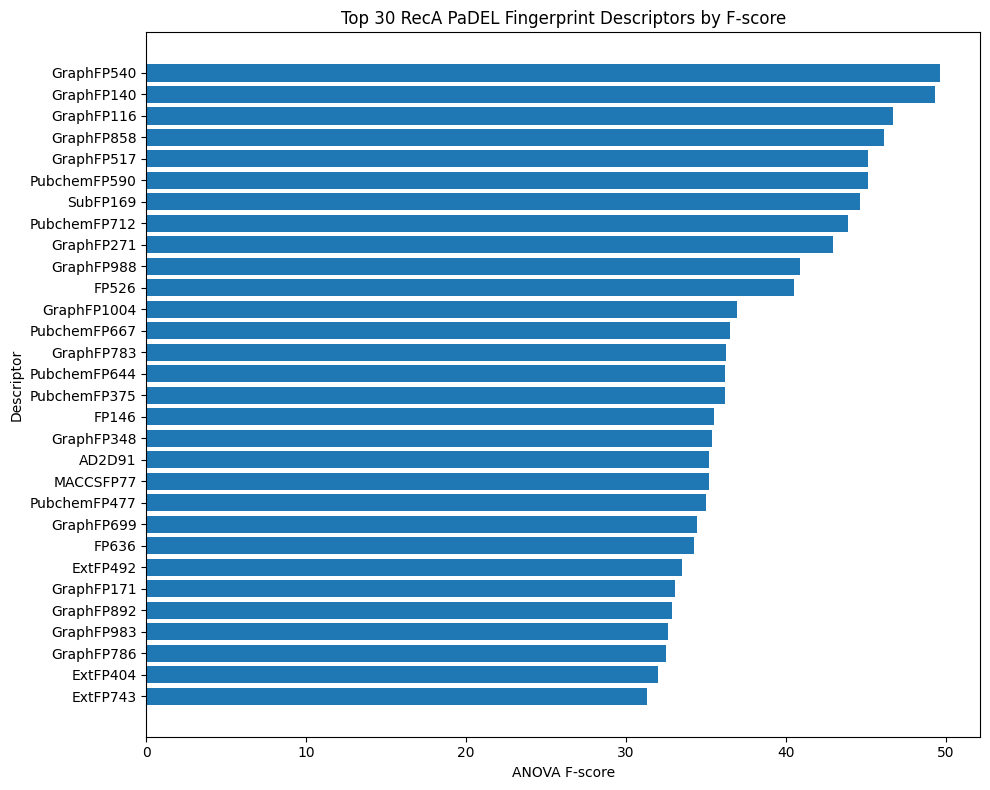

Saved figure: /content/outputs/feature_selection/figures/03_recA_top30_fscore_features.png


In [10]:
# ============================================================
# F-score summary plot
# ============================================================

top_plot = feature_scores.head(30).copy()

plt.figure(figsize=(10, 8))
plt.barh(top_plot["feature"][::-1], top_plot["f_score"][::-1])
plt.xlabel("ANOVA F-score")
plt.ylabel("Descriptor")
plt.title("Top 30 RecA PaDEL Fingerprint Descriptors by F-score")
plt.tight_layout()

fig_path = FIGURE_DIR / "03_recA_top30_fscore_features.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

###6. RFECV benchmark using SVM, Random Forest, and XGBoost

This section combines the senior notebook's SVM-RFE, RF-RFE, and XGBoost-RFE idea with a more publication-ready implementation using RFECV.

To reduce data leakage risk, RFECV is performed inside cross-validation on the preselected F-score matrix. The final selected features are exported separately for each estimator.

In [11]:
# ============================================================
# Helper functions for adaptive cross-validation and RFECV
# ============================================================

def make_cv(y, max_splits=10, random_state=RANDOM_STATE):
    """Create stratified CV with a safe number of folds based on class size."""
    counts = pd.Series(y).value_counts()
    min_class_count = int(counts.min())
    n_splits = max(2, min(max_splits, min_class_count))
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def extract_rfecv_scores(rfecv):
    """Return a DataFrame of RFECV scores compatible with multiple sklearn versions."""
    if hasattr(rfecv, "cv_results_"):
        results = pd.DataFrame(rfecv.cv_results_)
        keep_cols = [c for c in ["n_features", "mean_test_score", "std_test_score"] if c in results.columns]
        return results[keep_cols].copy()

    # Older sklearn fallback
    if hasattr(rfecv, "grid_scores_"):
        return pd.DataFrame({
            "iteration": np.arange(1, len(rfecv.grid_scores_) + 1),
            "mean_test_score": rfecv.grid_scores_,
        })

    return pd.DataFrame()


def run_rfecv_model(model_name, estimator, X_input, y_input, scale=False):
    """Run RFECV and export selected features and CV scores."""
    cv = make_cv(y_input, max_splits=10)

    if scale:
        estimator_for_rfecv = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator),
        ])
        importance_getter = "named_steps.model.coef_"
    else:
        estimator_for_rfecv = estimator
        importance_getter = "auto"

    rfecv = RFECV(
        estimator=estimator_for_rfecv,
        step=RFECV_STEP,
        min_features_to_select=min(MIN_FEATURES_TO_SELECT, X_input.shape[1]),
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        importance_getter=importance_getter,
    )

    rfecv.fit(X_input, y_input)

    selected_features = X_input.columns[rfecv.support_].tolist()
    ranking = pd.DataFrame({
        "feature": X_input.columns,
        "selected": rfecv.support_,
        "ranking": rfecv.ranking_,
    }).sort_values(["selected", "ranking"], ascending=[False, True])

    selected_file = RFE_OUTPUT_DIR / f"03_recA_rfecv_selected_features_{model_name}.csv"
    ranking_file = RFE_OUTPUT_DIR / f"03_recA_rfecv_ranking_{model_name}.csv"
    score_file = RFE_OUTPUT_DIR / f"03_recA_rfecv_scores_{model_name}.csv"
    dataset_file = RFE_OUTPUT_DIR / f"03_recA_rfecv_dataset_{model_name}.csv"

    pd.DataFrame({"feature": selected_features}).to_csv(selected_file, index=False)
    ranking.to_csv(ranking_file, index=False)

    scores = extract_rfecv_scores(rfecv)
    if not scores.empty:
        scores.to_csv(score_file, index=False)

    selected_dataset = pd.concat([meta, X_input[selected_features]], axis=1)
    selected_dataset.to_csv(dataset_file, index=False)

    summary = {
        "model": model_name,
        "input_features": int(X_input.shape[1]),
        "selected_features": int(len(selected_features)),
        "best_cv_accuracy": float(getattr(rfecv, "best_score_", np.nan)) if hasattr(rfecv, "best_score_") else np.nan,
        "selected_file": str(selected_file),
        "ranking_file": str(ranking_file),
        "dataset_file": str(dataset_file),
    }

    return summary, rfecv, ranking

In [12]:
# ============================================================
# Define RFECV estimators
# ============================================================

rfecv_estimators = {
    "svm_linear": {
        "estimator": LinearSVC(
            C=1.0,
            dual=False,
            max_iter=10000,
            random_state=RANDOM_STATE,
        ),
        "scale": True,
    },
    "random_forest": {
        "estimator": RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        ),
        "scale": False,
    },
}

if XGBOOST_AVAILABLE:
    rfecv_estimators["xgboost"] = {
        "estimator": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "scale": False,
    }

print("RFECV models:", list(rfecv_estimators.keys()))
print("RFECV input matrix:", X_fscore.shape)

RFECV models: ['svm_linear', 'random_forest', 'xgboost']
RFECV input matrix: (628, 1000)


In [13]:
# ============================================================
# Run RFECV benchmark + feature-number optimization
# Revised version: limit initial selected features to Top 200
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ============================================================
# Main setting
# ============================================================

TOP_FEATURE_LIMIT = 200


def extract_best_rfecv_score(rfecv):
    """
    Extract best RFECV score safely across different scikit-learn versions.
    """

    best_score = np.nan
    score_source = "not_found"

    if hasattr(rfecv, "cv_results_"):
        cv_results = rfecv.cv_results_

        if isinstance(cv_results, dict) and "mean_test_score" in cv_results:
            scores = np.asarray(cv_results["mean_test_score"], dtype=float)

            if scores.size > 0 and not np.all(np.isnan(scores)):
                best_score = float(np.nanmax(scores))
                score_source = "cv_results_['mean_test_score']"

    if np.isnan(best_score) and hasattr(rfecv, "grid_scores_"):
        scores = np.asarray(rfecv.grid_scores_, dtype=float)

        if scores.ndim > 1:
            scores = np.nanmean(scores, axis=1)

        if scores.size > 0 and not np.all(np.isnan(scores)):
            best_score = float(np.nanmax(scores))
            score_source = "grid_scores_"

    return best_score, score_source


def get_rfecv_feature_ranking(rfecv, X_input):
    """
    Return feature ranking from RFECV result.
    Rank 1 means selected by RFECV.
    """

    if hasattr(rfecv, "ranking_"):
        ranking_df = pd.DataFrame({
            "feature": X_input.columns,
            "rfecv_rank": rfecv.ranking_,
            "selected_by_rfecv": rfecv.support_,
        })

        ranking_df = (
            ranking_df
            .sort_values(["rfecv_rank", "feature"])
            .reset_index(drop=True)
        )

        return ranking_df

    return pd.DataFrame({
        "feature": X_input.columns,
        "rfecv_rank": np.nan,
        "selected_by_rfecv": False,
    })


def evaluate_top_n_features(
    model_name,
    estimator,
    X_input,
    y_input,
    ranking_df,
    scale=False,
    feature_counts=None,
    scoring="roc_auc",
):
    """
    Evaluate different Top-N feature subsets from RFECV ranking.
    The maximum number of evaluated features is limited to TOP_FEATURE_LIMIT.
    """

    if feature_counts is None:
        feature_counts = [20, 30, 40, 50, 75, 100, 125, 150, 175, 200]

    max_allowed_features = min(TOP_FEATURE_LIMIT, X_input.shape[1])

    feature_counts = [
        n for n in feature_counts
        if n <= max_allowed_features
    ]

    ordered_features = ranking_df["feature"].tolist()[:max_allowed_features]

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    rows = []

    for n_features in feature_counts:
        selected_features_n = ordered_features[:n_features]
        X_n = X_input[selected_features_n]

        if scale:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", estimator),
            ])
        else:
            model = estimator

        scores = cross_val_score(
            model,
            X_n,
            y_input,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )

        rows.append({
            "model": model_name,
            "n_features": n_features,
            "mean_cv_score": float(np.mean(scores)),
            "std_cv_score": float(np.std(scores)),
            "scoring": scoring,
        })

    return pd.DataFrame(rows)


rfecv_summaries = []
rfecv_objects = {}
rfecv_rankings = {}
feature_number_optimization_tables = []

if RUN_RFECV:
    for model_name, config in rfecv_estimators.items():
        print(f"\nRunning RFECV: {model_name}")

        summary, rfecv, ranking = run_rfecv_model(
            model_name=model_name,
            estimator=config["estimator"],
            X_input=X_fscore,
            y_input=y,
            scale=config["scale"],
        )

        best_cv_score, score_source = extract_best_rfecv_score(rfecv)

        summary["best_cv_score"] = best_cv_score
        summary["score_source"] = score_source
        summary["best_cv_accuracy"] = best_cv_score

        summary["rfecv_n_features"] = int(
            getattr(
                rfecv,
                "n_features_",
                summary.get("selected_features", np.nan)
            )
        )

        summary["rfecv_step"] = getattr(rfecv, "step", np.nan)

        if hasattr(rfecv, "support_"):
            summary["support_feature_count"] = int(np.sum(rfecv.support_))

        if hasattr(rfecv, "ranking_"):
            summary["rank1_feature_count"] = int(np.sum(np.asarray(rfecv.ranking_) == 1))

        # Build RFECV ranking table
        ranking_df = get_rfecv_feature_ranking(
            rfecv=rfecv,
            X_input=X_fscore,
        )

        ranking_file = RFE_OUTPUT_DIR / f"03_recA_{model_name}_rfecv_feature_ranking_fixed.csv"
        ranking_df.to_csv(ranking_file, index=False)
        summary["fixed_ranking_file"] = str(ranking_file)

        # ====================================================
        # Save Top 200 initial selected features
        # ====================================================

        top_200_features = ranking_df["feature"].tolist()[:TOP_FEATURE_LIMIT]

        top_200_feature_file = (
            RFE_OUTPUT_DIR /
            f"03_recA_{model_name}_top_{TOP_FEATURE_LIMIT}_features.csv"
        )

        pd.DataFrame({
            "rank": np.arange(1, len(top_200_features) + 1),
            "feature": top_200_features,
        }).to_csv(top_200_feature_file, index=False)

        summary["selected_features"] = len(top_200_features)
        summary["top_200_selected_file"] = str(top_200_feature_file)

        print(f"Top {TOP_FEATURE_LIMIT} features saved:", top_200_feature_file)

        # Feature-number optimization only up to Top 200
        print(f"Running feature-number optimization up to Top {TOP_FEATURE_LIMIT} for {model_name}...")

        optimization_df = evaluate_top_n_features(
            model_name=model_name,
            estimator=config["estimator"],
            X_input=X_fscore,
            y_input=y,
            ranking_df=ranking_df,
            scale=config["scale"],
            feature_counts=[20, 30, 40, 50, 75, 100, 125, 150, 175, 200],
            scoring="roc_auc",
        )

        optimization_file = RFE_OUTPUT_DIR / f"03_recA_{model_name}_feature_number_optimization_top_{TOP_FEATURE_LIMIT}.csv"
        optimization_df.to_csv(optimization_file, index=False)

        best_opt_row = (
            optimization_df
            .sort_values(["mean_cv_score", "n_features"], ascending=[False, True])
            .iloc[0]
        )

        summary["optimized_n_features"] = int(best_opt_row["n_features"])
        summary["optimized_cv_roc_auc"] = float(best_opt_row["mean_cv_score"])
        summary["optimized_cv_roc_auc_std"] = float(best_opt_row["std_cv_score"])
        summary["optimization_file"] = str(optimization_file)

        # Save optimized selected feature list
        optimized_features = ranking_df["feature"].tolist()[:summary["optimized_n_features"]]

        optimized_feature_file = (
            RFE_OUTPUT_DIR /
            f"03_recA_{model_name}_optimized_{summary['optimized_n_features']}_features.csv"
        )

        pd.DataFrame({
            "rank": np.arange(1, len(optimized_features) + 1),
            "feature": optimized_features,
        }).to_csv(optimized_feature_file, index=False)

        summary["optimized_selected_file"] = str(optimized_feature_file)

        rfecv_summaries.append(summary)
        rfecv_objects[model_name] = rfecv
        rfecv_rankings[model_name] = ranking_df
        feature_number_optimization_tables.append(optimization_df)

        print(summary)

else:
    print("RUN_RFECV is False. Skipping RFECV benchmark.")


summary_df = pd.DataFrame(rfecv_summaries)
SUMMARY_FILE = RFE_OUTPUT_DIR / "03_recA_rfecv_summary_top_200.csv"

if not summary_df.empty:
    preferred_cols = [
        "model",
        "input_features",
        "selected_features",
        "rfecv_n_features",
        "support_feature_count",
        "rank1_feature_count",
        "best_cv_score",
        "best_cv_accuracy",
        "optimized_n_features",
        "optimized_cv_roc_auc",
        "optimized_cv_roc_auc_std",
        "score_source",
        "selected_file",
        "ranking_file",
        "fixed_ranking_file",
        "top_200_selected_file",
        "optimization_file",
        "optimized_selected_file",
    ]

    ordered_cols = [c for c in preferred_cols if c in summary_df.columns]
    remaining_cols = [c for c in summary_df.columns if c not in ordered_cols]

    summary_df = summary_df[ordered_cols + remaining_cols]
    summary_df.to_csv(SUMMARY_FILE, index=False)

    display(summary_df)
    print("Saved:", SUMMARY_FILE)

    if summary_df["best_cv_score"].isna().all():
        print("Warning: best_cv_score is still NaN for all models.")
        print("Please check the run_rfecv_model() function and RFECV scoring parameter.")

else:
    print("No RFECV summary was generated.")


# ============================================================
# Save combined feature-number optimization table
# ============================================================

if len(feature_number_optimization_tables) > 0:
    feature_number_optimization_df = pd.concat(
        feature_number_optimization_tables,
        ignore_index=True,
    )

    FEATURE_OPT_FILE = RFE_OUTPUT_DIR / f"03_recA_rfecv_feature_number_optimization_all_models_top_{TOP_FEATURE_LIMIT}.csv"
    feature_number_optimization_df.to_csv(FEATURE_OPT_FILE, index=False)

    display(feature_number_optimization_df)
    print("Saved:", FEATURE_OPT_FILE)

    best_feature_model_row = (
        feature_number_optimization_df
        .sort_values(["mean_cv_score", "n_features"], ascending=[False, True])
        .iloc[0]
    )

    print("\nBest RFECV-derived feature-number setting:")
    print(best_feature_model_row)


Running RFECV: svm_linear
Top 200 features saved: /content/outputs/feature_selection/rfe/03_recA_svm_linear_top_200_features.csv
Running feature-number optimization up to Top 200 for svm_linear...
{'model': 'svm_linear', 'input_features': 1000, 'selected_features': 200, 'best_cv_accuracy': 0.7580133128520226, 'selected_file': '/content/outputs/feature_selection/rfe/03_recA_rfecv_selected_features_svm_linear.csv', 'ranking_file': '/content/outputs/feature_selection/rfe/03_recA_rfecv_ranking_svm_linear.csv', 'dataset_file': '/content/outputs/feature_selection/rfe/03_recA_rfecv_dataset_svm_linear.csv', 'best_cv_score': 0.7580133128520226, 'score_source': "cv_results_['mean_test_score']", 'rfecv_n_features': 350, 'rfecv_step': 0.05, 'support_feature_count': 350, 'rank1_feature_count': 350, 'fixed_ranking_file': '/content/outputs/feature_selection/rfe/03_recA_svm_linear_rfecv_feature_ranking_fixed.csv', 'top_200_selected_file': '/content/outputs/feature_selection/rfe/03_recA_svm_linear_top

,model,input_features,selected_features,rfecv_n_features,support_feature_count,rank1_feature_count,best_cv_score,best_cv_accuracy,optimized_n_features,optimized_cv_roc_auc,optimized_cv_roc_auc_std,score_source,selected_file,ranking_file,fixed_ranking_file,top_200_selected_file,optimization_file,optimized_selected_file,dataset_file,rfecv_step
0,svm_linear,1000,200,350,350,350,0.758013,0.758013,200,0.848787,0.011372,cv_results_['mean_test_score'],/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,0.05
1,random_forest,1000,200,500,500,500,0.789913,0.789913,125,0.871442,0.028808,cv_results_['mean_test_score'],/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,0.05
2,xgboost,1000,200,150,150,150,0.777010,0.777010,175,0.897761,0.023282,cv_results_['mean_test_score'],/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,/content/outputs/feature_selection/rfe/03_recA...,0.05


Saved: /content/outputs/feature_selection/rfe/03_recA_rfecv_summary_top_200.csv


,model,n_features,mean_cv_score,std_cv_score,scoring
0,svm_linear,20,0.696983,0.051052,roc_auc
1,svm_linear,30,0.701356,0.053389,roc_auc
2,svm_linear,40,0.745193,0.035996,roc_auc
3,svm_linear,50,0.741534,0.046882,roc_auc
4,svm_linear,75,0.802329,0.041147,roc_auc
5,svm_linear,100,0.811950,0.043153,roc_auc
6,svm_linear,125,0.810973,0.047697,roc_auc
7,svm_linear,150,0.794029,0.026038,roc_auc
8,svm_linear,175,0.832861,0.025921,roc_auc
9,svm_linear,200,0.848787,0.011372,roc_auc


Saved: /content/outputs/feature_selection/rfe/03_recA_rfecv_feature_number_optimization_all_models_top_200.csv

Best RFECV-derived feature-number setting:
model             xgboost
n_features            175
mean_cv_score    0.897761
std_cv_score     0.023282
scoring           roc_auc
Name: 28, dtype: object


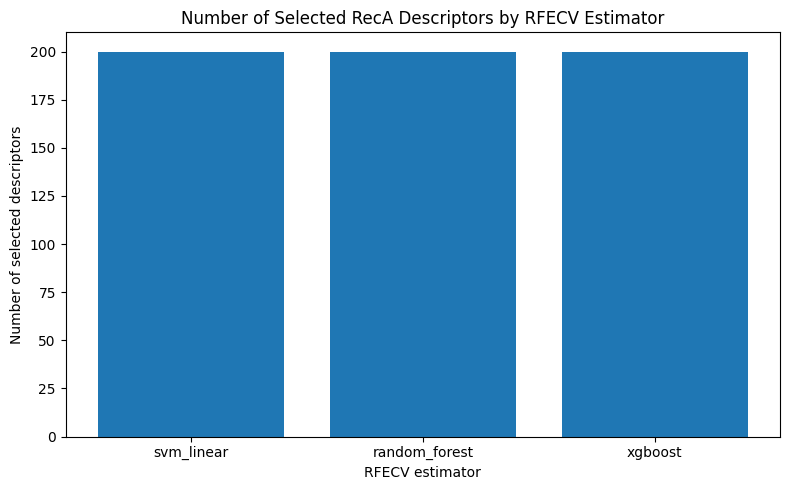

Saved figure: /content/outputs/feature_selection/figures/03_recA_rfecv_selected_feature_counts.png


In [14]:
# ============================================================
# Plot RFECV summary
# ============================================================

if RUN_RFECV and not summary_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["model"], summary_df["selected_features"])
    plt.xlabel("RFECV estimator")
    plt.ylabel("Number of selected descriptors")
    plt.title("Number of Selected RecA Descriptors by RFECV Estimator")
    plt.tight_layout()

    fig_path = FIGURE_DIR / "03_recA_rfecv_selected_feature_counts.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", fig_path)

###7. Consensus feature set

For manuscript-level robustness, a consensus descriptor set can be generated by retaining features selected by at least two RFECV estimators. If only one RFECV estimator is available, its selected features are used.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# Build consensus RFECV feature set + optimize feature number
# Revised version: limit consensus features to Top 200
# ============================================================

CONSENSUS_TOP_FEATURE_LIMIT = 200


def evaluate_consensus_feature_numbers(
    X_input,
    y_input,
    ranked_features,
    estimator=None,
    feature_counts=None,
    scoring="roc_auc",
    scale=False,
):
    """
    Evaluate different Top-N consensus feature subsets.
    The maximum evaluated feature number is limited to CONSENSUS_TOP_FEATURE_LIMIT.
    """

    if estimator is None:
        estimator = RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
        )

    max_features = min(len(ranked_features), CONSENSUS_TOP_FEATURE_LIMIT)

    if feature_counts is None:
        feature_counts = [20, 30, 40, 50, 75, 100, 125, 150, 175, 200]

    feature_counts = sorted(set([
        n for n in feature_counts
        if 0 < n <= max_features
    ]))

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    rows = []

    for n_features in feature_counts:
        selected_features_n = ranked_features[:n_features]
        X_n = X_input[selected_features_n]

        if scale:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", estimator),
            ])
        else:
            model = estimator

        scores = cross_val_score(
            model,
            X_n,
            y_input,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )

        rows.append({
            "n_features": int(n_features),
            "mean_cv_roc_auc": float(np.mean(scores)),
            "std_cv_roc_auc": float(np.std(scores)),
            "scoring": scoring,
        })

    return pd.DataFrame(rows)


if RUN_RFECV and rfecv_rankings:
    selection_table = pd.DataFrame(index=X_fscore.columns)

    for model_name, ranking in rfecv_rankings.items():

        if "selected_by_rfecv" in ranking.columns:
            selected = ranking.set_index("feature")["selected_by_rfecv"].astype(int)
        elif "selected" in ranking.columns:
            selected = ranking.set_index("feature")["selected"].astype(int)
        else:
            raise ValueError(
                f"No selected feature column found for {model_name}. "
                "Expected 'selected_by_rfecv' or 'selected'."
            )

        selection_table[model_name] = (
            selected
            .reindex(X_fscore.columns)
            .fillna(0)
            .astype(int)
        )

    selection_table["selection_count"] = selection_table.sum(axis=1)

    # Add F-score ranking information if available
    if "feature_scores" in globals() and "feature" in feature_scores.columns:
        fscore_map = feature_scores.set_index("feature")["f_score"].to_dict()
        pvalue_map = feature_scores.set_index("feature")["p_value"].to_dict()

        selection_table["f_score"] = selection_table.index.map(fscore_map)
        selection_table["p_value"] = selection_table.index.map(pvalue_map)
    else:
        selection_table["f_score"] = np.nan
        selection_table["p_value"] = np.nan

    # Sort features by consensus vote, then F-score
    selection_table = (
        selection_table
        .sort_values(
            by=["selection_count", "f_score"],
            ascending=[False, False]
        )
    )

    minimum_votes = 2 if len(rfecv_rankings) >= 2 else 1

    consensus_features_all = (
        selection_table
        .query("selection_count >= @minimum_votes")
        .index
        .tolist()
    )

    if len(consensus_features_all) == 0:
        consensus_features_all = selection_table.index.tolist()

    # ========================================================
    # Limit initial consensus features to Top 200
    # ========================================================

    consensus_features = consensus_features_all[:CONSENSUS_TOP_FEATURE_LIMIT]

    consensus_dataset = pd.concat(
        [
            meta.reset_index(drop=True),
            X_fscore[consensus_features].reset_index(drop=True),
        ],
        axis=1,
    )

    CONSENSUS_TABLE_FILE = (
        RFE_OUTPUT_DIR /
        "03_recA_rfecv_consensus_feature_votes_top_200.csv"
    )

    CONSENSUS_DATASET_FILE = (
        RFE_OUTPUT_DIR /
        "03_recA_rfecv_consensus_dataset_top_200.csv"
    )

    selection_table.to_csv(CONSENSUS_TABLE_FILE)
    consensus_dataset.to_csv(CONSENSUS_DATASET_FILE, index=False)

    print("Number of consensus features before Top-200 limit:", len(consensus_features_all))
    print("Number of consensus features after Top-200 limit :", len(consensus_features))
    print("Saved:", CONSENSUS_TABLE_FILE)
    print("Saved:", CONSENSUS_DATASET_FILE)

    display(selection_table.head(20))

    # ========================================================
    # Consensus feature-number optimization up to Top 200
    # ========================================================

    max_consensus_features = len(consensus_features)

    candidate_feature_counts = [
        20,
        30,
        40,
        50,
        75,
        100,
        125,
        150,
        175,
        200,
    ]

    candidate_feature_counts = [
        n for n in candidate_feature_counts
        if n <= max_consensus_features
    ]

    print("\nRunning consensus feature-number optimization...")
    print("Candidate feature counts:", candidate_feature_counts)

    consensus_optimization_df = evaluate_consensus_feature_numbers(
        X_input=X_fscore,
        y_input=y,
        ranked_features=consensus_features,
        estimator=RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
        ),
        feature_counts=candidate_feature_counts,
        scoring="roc_auc",
        scale=False,
    )

    CONSENSUS_OPT_FILE = (
        RFE_OUTPUT_DIR /
        "03_recA_rfecv_consensus_feature_number_optimization_top_200.csv"
    )

    consensus_optimization_df.to_csv(CONSENSUS_OPT_FILE, index=False)

    best_consensus_row = (
        consensus_optimization_df
        .sort_values(
            by=["mean_cv_roc_auc", "n_features"],
            ascending=[False, True]
        )
        .iloc[0]
    )

    best_consensus_n = int(best_consensus_row["n_features"])
    final_consensus_features = consensus_features[:best_consensus_n]

    FINAL_CONSENSUS_FEATURE_FILE = (
        RFE_OUTPUT_DIR /
        f"03_recA_rfecv_consensus_optimized_top_{best_consensus_n}_features.csv"
    )

    FINAL_CONSENSUS_DATASET_FILE = (
        RFE_OUTPUT_DIR /
        f"03_recA_rfecv_consensus_optimized_top_{best_consensus_n}_dataset.csv"
    )

    pd.DataFrame({
        "rank": np.arange(1, len(final_consensus_features) + 1),
        "feature": final_consensus_features,
        "selection_count": [
            int(selection_table.loc[f, "selection_count"])
            for f in final_consensus_features
        ],
        "f_score": [
            selection_table.loc[f, "f_score"]
            for f in final_consensus_features
        ],
        "p_value": [
            selection_table.loc[f, "p_value"]
            for f in final_consensus_features
        ],
    }).to_csv(FINAL_CONSENSUS_FEATURE_FILE, index=False)

    final_consensus_dataset = pd.concat(
        [
            meta.reset_index(drop=True),
            X_fscore[final_consensus_features].reset_index(drop=True),
        ],
        axis=1,
    )

    final_consensus_dataset.to_csv(
        FINAL_CONSENSUS_DATASET_FILE,
        index=False,
    )

    print("\nBest optimized consensus feature subset:")
    print(f"Selected features : {best_consensus_n}")
    print(f"Mean CV ROC-AUC   : {best_consensus_row['mean_cv_roc_auc']:.4f}")
    print(f"SD CV ROC-AUC     : {best_consensus_row['std_cv_roc_auc']:.4f}")

    print("\nSaved:")
    print(CONSENSUS_OPT_FILE)
    print(FINAL_CONSENSUS_FEATURE_FILE)
    print(FINAL_CONSENSUS_DATASET_FILE)

    display(consensus_optimization_df)
    display(pd.DataFrame({
        "rank": np.arange(1, min(20, len(final_consensus_features)) + 1),
        "feature": final_consensus_features[:20],
    }))

else:
    print("Consensus feature set was not generated because RFECV was skipped.")

Number of consensus features before Top-200 limit: 268
Number of consensus features after Top-200 limit : 200
Saved: /content/outputs/feature_selection/rfe/03_recA_rfecv_consensus_feature_votes_top_200.csv
Saved: /content/outputs/feature_selection/rfe/03_recA_rfecv_consensus_dataset_top_200.csv


,svm_linear,random_forest,xgboost,selection_count,f_score,p_value
GraphFP540,1,1,1,3,49.663972,4.831069e-12
GraphFP517,1,1,1,3,45.158585,4.091733e-11
PubchemFP712,1,1,1,3,43.883631,7.515051e-11
GraphFP988,1,1,1,3,40.868044,3.184693e-10
GraphFP348,1,1,1,3,35.355482,4.566765e-09
FP636,1,1,1,3,34.255278,7.799882e-09
ExtFP492,1,1,1,3,33.494213,1.130430e-08
ExtFP404,1,1,1,3,32.019693,2.324232e-08
ExtFP243,1,1,1,3,30.909212,4.006380e-08
FP725,1,1,1,3,29.807178,6.887437e-08



Running consensus feature-number optimization...
Candidate feature counts: [20, 30, 40, 50, 75, 100, 125, 150, 175, 200]

Best optimized consensus feature subset:
Selected features : 75
Mean CV ROC-AUC   : 0.8922
SD CV ROC-AUC     : 0.0252

Saved:
/content/outputs/feature_selection/rfe/03_recA_rfecv_consensus_feature_number_optimization_top_200.csv
/content/outputs/feature_selection/rfe/03_recA_rfecv_consensus_optimized_top_75_features.csv
/content/outputs/feature_selection/rfe/03_recA_rfecv_consensus_optimized_top_75_dataset.csv


,n_features,mean_cv_roc_auc,std_cv_roc_auc,scoring
0,20,0.827026,0.033178,roc_auc
1,30,0.859804,0.035430,roc_auc
2,40,0.862045,0.035418,roc_auc
3,50,0.884483,0.033689,roc_auc
4,75,0.892226,0.025190,roc_auc
5,100,0.886755,0.021601,roc_auc
6,125,0.887030,0.028354,roc_auc
7,150,0.883226,0.025662,roc_auc
8,175,0.885511,0.023088,roc_auc
9,200,0.884110,0.021026,roc_auc


,rank,feature
0,1,GraphFP540
1,2,GraphFP517
2,3,PubchemFP712
3,4,GraphFP988
4,5,GraphFP348
5,6,FP636
6,7,ExtFP492
7,8,ExtFP404
8,9,ExtFP243
9,10,FP725


###8. Final notes

This notebook provides three feature-selection outputs that can be reported in a thesis or manuscript:

1. Low-variance filtering removes non-informative descriptors.

2. ANOVA F-score ranking identifies descriptors with strong class-separation power.

3. RFECV with SVM, Random Forest, and XGBoost evaluates model-dependent descriptor relevance.

For final QSAR/ML modeling, use one of these exported datasets:

* Conservative and fast option: 03_recA_top_fscore_dataset.csv

* Model-driven option: 03_recA_rfecv_dataset_svm_linear.csv, 03_recA_rfecv_dataset_random_forest.csv, or 03_recA_rfecv_dataset_xgboost.csv

* Robust consensus option: 03_recA_rfecv_consensus_dataset.csv

In the manuscript, clearly state that feature selection was conducted only after the RecA bioactivity matrix was curated and converted into PaDEL molecular fingerprints.

###9. Validation extension: RFE benchmarking, optimized modeling, and robustness tests

This extension adds the requested publication-oriented analyses to strengthen the feature-selection and QSAR validation workflow. The added sections include:

* Heatmap of selected features
* SVM-RFE and RF-RFE training/test performance
* RF vs SVM baseline and optimized modeling
* SVM-RFE and RF-RFE feature subsets
* Requested RF / SVM / RFE summary
* RF-RFE and SVM-RFE performance vs number of features
* Prediction probability vs actual label plots
* Nested cross-validation
* Optuna-based hyperparameter optimization with fallback to RandomizedSearchCV
* Y-randomization
* Applicability domain using leverage approach
* External validation split
* Bootstrap confidence intervals

The goal is to make the methodology clearer, less exploratory, and more defensible for thesis/manuscript review.



In [17]:
# ============================================================
# Q1-level extension: imports, folders, and leakage-safe matrix
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from scipy.stats import randint, uniform, loguniform

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    SEABORN_AVAILABLE = False

VALIDATION_DIR = OUTPUT_DIR / "q1_validation_extension"
VALIDATION_FIGURE_DIR = VALIDATION_DIR / "figures"
VALIDATION_TABLE_DIR = VALIDATION_DIR / "tables"
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Leakage protection: do not allow bioactivity/endpoint columns to become model inputs.
LEAKAGE_KEYWORDS = [
    "standard_value", "standard_value_nm", "ec50", "ic50", "ki", "kd",
    "pic50", "pec50", "pchembl", "activity", "bioactivity", "class", "label", "target",
]

def remove_leakage_columns(X_in: pd.DataFrame) -> pd.DataFrame:
    bad = [c for c in X_in.columns if any(k in c.lower() for k in LEAKAGE_KEYWORDS)]
    if bad:
        print("Removed possible leakage columns:", bad)
    return X_in.drop(columns=bad, errors="ignore")

# Prefer the post-variance matrix already created above. Fall back to initial X.
if "X_low" in globals() and X_low.shape[1] > 0:
    X_model_full = X_low.copy()
elif "X" in globals() and X.shape[1] > 0:
    X_model_full = X.copy()
else:
    raise RuntimeError("No feature matrix found. Please run the earlier feature-selection cells first.")

X_model_full = remove_leakage_columns(X_model_full)
y_model_full = y.astype(int).copy()

print("Leakage-safe modeling matrix:", X_model_full.shape)
print("Target distribution:")
print(y_model_full.value_counts().sort_index())
print("Optuna available:", OPTUNA_AVAILABLE)
print("Seaborn available:", SEABORN_AVAILABLE)

Leakage-safe modeling matrix: (628, 2110)
Target distribution:
class
0    314
1    314
Name: count, dtype: int64
Optuna available: False
Seaborn available: True


###9.1 Train / test / external validation split

To strengthen validation, the dataset is split into training, holdout test, and an external-like validation subset. If a truly external dataset is available, replace X_external and y_external with that independent dataset. This prevents the notebook from relying only on a single training/test comparison.



In [18]:
# ============================================================
# Train / test / external validation split
# ============================================================

# 70% train, 15% test, 15% external-like validation
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model_full,
    y_model_full,
    test_size=0.30,
    stratify=y_model_full,
    random_state=RANDOM_STATE,
)

X_test, X_external, y_test, y_external = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Training set:", X_train.shape, y_train.value_counts().sort_index().to_dict())
print("Test set:", X_test.shape, y_test.value_counts().sort_index().to_dict())
print("External-like validation set:", X_external.shape, y_external.value_counts().sort_index().to_dict())

Training set: (439, 2110) {0: 219, 1: 220}
Test set: (94, 2110) {0: 47, 1: 47}
External-like validation set: (95, 2110) {0: 48, 1: 47}


###9.2 Helper functions for figures and metrics

These functions generate the requested performance tables, confusion matrices, ROC curves, probability scatter plots, feature-subset tables, correlation heatmaps, and model summary panels.

In [19]:
# ============================================================
# Helper functions
# ============================================================

def predict_score(model, X_input):
    """Return continuous score for ROC-AUC and probability-style plots."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X_input)
        raw = np.asarray(raw, dtype=float)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    return model.predict(X_input)


def metric_row(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_score = predict_score(model, X_eval)
    return {
        "Algorithm": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_score),
    }


def evaluate_models(models, X_eval, y_eval):
    rows = [metric_row(name, model, X_eval, y_eval) for name, model in models.items()]
    return pd.DataFrame(rows)


def save_table_figure(df_table, title, out_path, footer=None, figsize=(13, 3.2)):
    display_df = df_table.copy()
    numeric_cols = display_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        display_df[col] = display_df[col].map(lambda x: f"{x:.3f}")

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    ax.axis("off")
    ax.set_title(title, fontsize=20, fontweight="bold", color="#173f7a", pad=18)
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.1, 1.55)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1f4e8c")
            cell.set_text_props(color="white", weight="bold")
        elif col == 0:
            cell.set_text_props(weight="bold")
        cell.set_edgecolor("#b8c8e0")
    if footer:
        fig.text(0.5, 0.03, footer, ha="center", fontsize=11, color="#496a9a")
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    return out_path


def save_feature_subset_table(features, title, out_path, n_cols=4):
    features = list(features)
    n_rows = int(np.ceil(len(features) / n_cols))
    padded = features + [""] * (n_rows * n_cols - len(features))
    data = np.array(padded).reshape(n_rows, n_cols)
    df_features = pd.DataFrame(data, columns=[f"Column {i+1}" for i in range(n_cols)])
    save_table_figure(
        df_features,
        title,
        out_path,
        footer=f"Total selected features: {len(features)}",
        figsize=(14, max(4, n_rows * 0.32 + 2.2)),
    )
    return df_features


def save_confusion_matrix_with_percent(model, X_eval, y_eval, title, out_path):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred)
    row_sums = cm.sum(axis=1, keepdims=True)
    pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100
    labels = np.array([[f"{cm[i,j]}\n{pct[i,j]:.2f}%" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

    fig, ax = plt.subplots(figsize=(5.8, 5.0), dpi=300)
    if SEABORN_AVAILABLE:
        sns.heatmap(
            cm,
            annot=labels,
            fmt="",
            cmap="Blues",
            cbar=True,
            xticklabels=["Inactive (0)", "Active (1)"],
            yticklabels=["Inactive (0)", "Active (1)"],
            ax=ax,
        )
    else:
        im = ax.imshow(cm, cmap="Blues")
        fig.colorbar(im, ax=ax)
        ax.set_xticks([0, 1], ["Inactive (0)", "Active (1)"])
        ax.set_yticks([0, 1], ["Inactive (0)", "Active (1)"])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, labels[i, j], ha="center", va="center")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_title(title, fontsize=14)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    return cm


def save_roc_curve(model, X_eval, y_eval, title, out_path):
    y_score = predict_score(model, X_eval)
    fpr, tpr, _ = roc_curve(y_eval, y_score)
    auc_val = roc_auc_score(y_eval, y_score)
    fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)
    ax.plot(fpr, tpr, linewidth=2.5, label=f"ROC curve (area = {auc_val:.2f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=2)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    return auc_val


def save_probability_scatter(model, X_eval, y_eval, title, out_path):
    y_score = predict_score(model, X_eval)
    y_pred = model.predict(X_eval)
    metrics = {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_score),
    }
    rng = np.random.default_rng(RANDOM_STATE)
    x_pos = np.asarray(y_eval, dtype=float) + rng.normal(0, 0.035, size=len(y_eval))
    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    ax.scatter(x_pos, y_score, alpha=0.75)
    ax.set_xticks([0, 1], ["Inactive (0)", "Active (1)"])
    ax.set_xlabel("Actual label")
    ax.set_ylabel("Predicted probability of active class")
    ax.set_title(title, fontsize=15, fontweight="bold", color="#173f7a")
    text = "\n".join([f"{k} = {v:.3f}" for k, v in metrics.items()])
    ax.text(
        0.98, 0.05, text, transform=ax.transAxes,
        ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#1c7c3b", alpha=0.95),
    )
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    return metrics


def save_metric_barplot(df_metrics, title, out_path, metrics=("Accuracy", "F1-score", "ROC-AUC"), footer=None):
    fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=300)
    x = np.arange(len(metrics))
    width = 0.8 / len(df_metrics)
    for idx, (_, row) in enumerate(df_metrics.iterrows()):
        values = [row[m] for m in metrics]
        offset = (idx - (len(df_metrics)-1)/2) * width
        bars = ax.bar(x + offset, values, width=width, label=row["Algorithm"])
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_xticks(x, metrics)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=18, fontweight="bold", color="#173f7a")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    if footer:
        fig.text(0.5, 0.02, footer, ha="center", fontsize=11, color="#496a9a")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    return out_path

###9.3 Baseline RF vs SVM modeling

This section trains baseline Random Forest and SVM models using the top F-score descriptors. It provides the requested RF vs SVM Baseline Modeling figure.

Feature source: optimized_consensus_features
Available ranked features before Top-200 limit: 75
Available ranked features after Top-200 limit : 75
Candidate feature numbers: [20, 30, 40, 50, 75]


,feature_source,feature_limit,n_features,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,optimized_consensus_features,200,20,SVM,0.755319,0.750000,0.765957,0.757895,0.834088
1,optimized_consensus_features,200,20,RandomForest,0.776596,0.809524,0.723404,0.764045,0.823676
2,optimized_consensus_features,200,30,SVM,0.765957,0.777778,0.744681,0.760870,0.826618
3,optimized_consensus_features,200,30,RandomForest,0.787234,0.829268,0.723404,0.772727,0.837030
4,optimized_consensus_features,200,40,SVM,0.776596,0.795455,0.744681,0.769231,0.850611
5,optimized_consensus_features,200,40,RandomForest,0.808511,0.871795,0.723404,0.790698,0.866455
6,optimized_consensus_features,200,50,SVM,0.787234,0.800000,0.765957,0.782609,0.876415
7,optimized_consensus_features,200,50,RandomForest,0.808511,0.891892,0.702128,0.785714,0.867813
8,optimized_consensus_features,200,75,SVM,0.819149,0.894737,0.723404,0.800000,0.893164
9,optimized_consensus_features,200,75,RandomForest,0.840426,0.900000,0.765957,0.827586,0.880942


Saved: /content/outputs/feature_selection/q1_validation_extension/tables/baseline_rf_svm_feature_number_optimization_top_200.csv

Best baseline setting:
feature_source    optimized_consensus_features
feature_limit                              200
n_features                                  75
Algorithm                                  SVM
Accuracy                              0.819149
Precision                             0.894737
Recall                                0.723404
F1-score                                   0.8
ROC-AUC                               0.893164
Name: 8, dtype: object

Selected baseline algorithm : SVM
Selected feature number     : 75
Feature source              : optimized_consensus_features


,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC,n_features,feature_source,feature_limit
0,SVM,0.873684,0.906977,0.829787,0.866667,0.952128,75,optimized_consensus_features,200


,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC,n_features,feature_source,feature_limit
0,SVM,0.819149,0.894737,0.723404,0.8,0.893164,75,optimized_consensus_features,200


Saved selected baseline features: /content/outputs/feature_selection/q1_validation_extension/tables/baseline_selected_75_optimized_consensus_features_top_200_features.csv


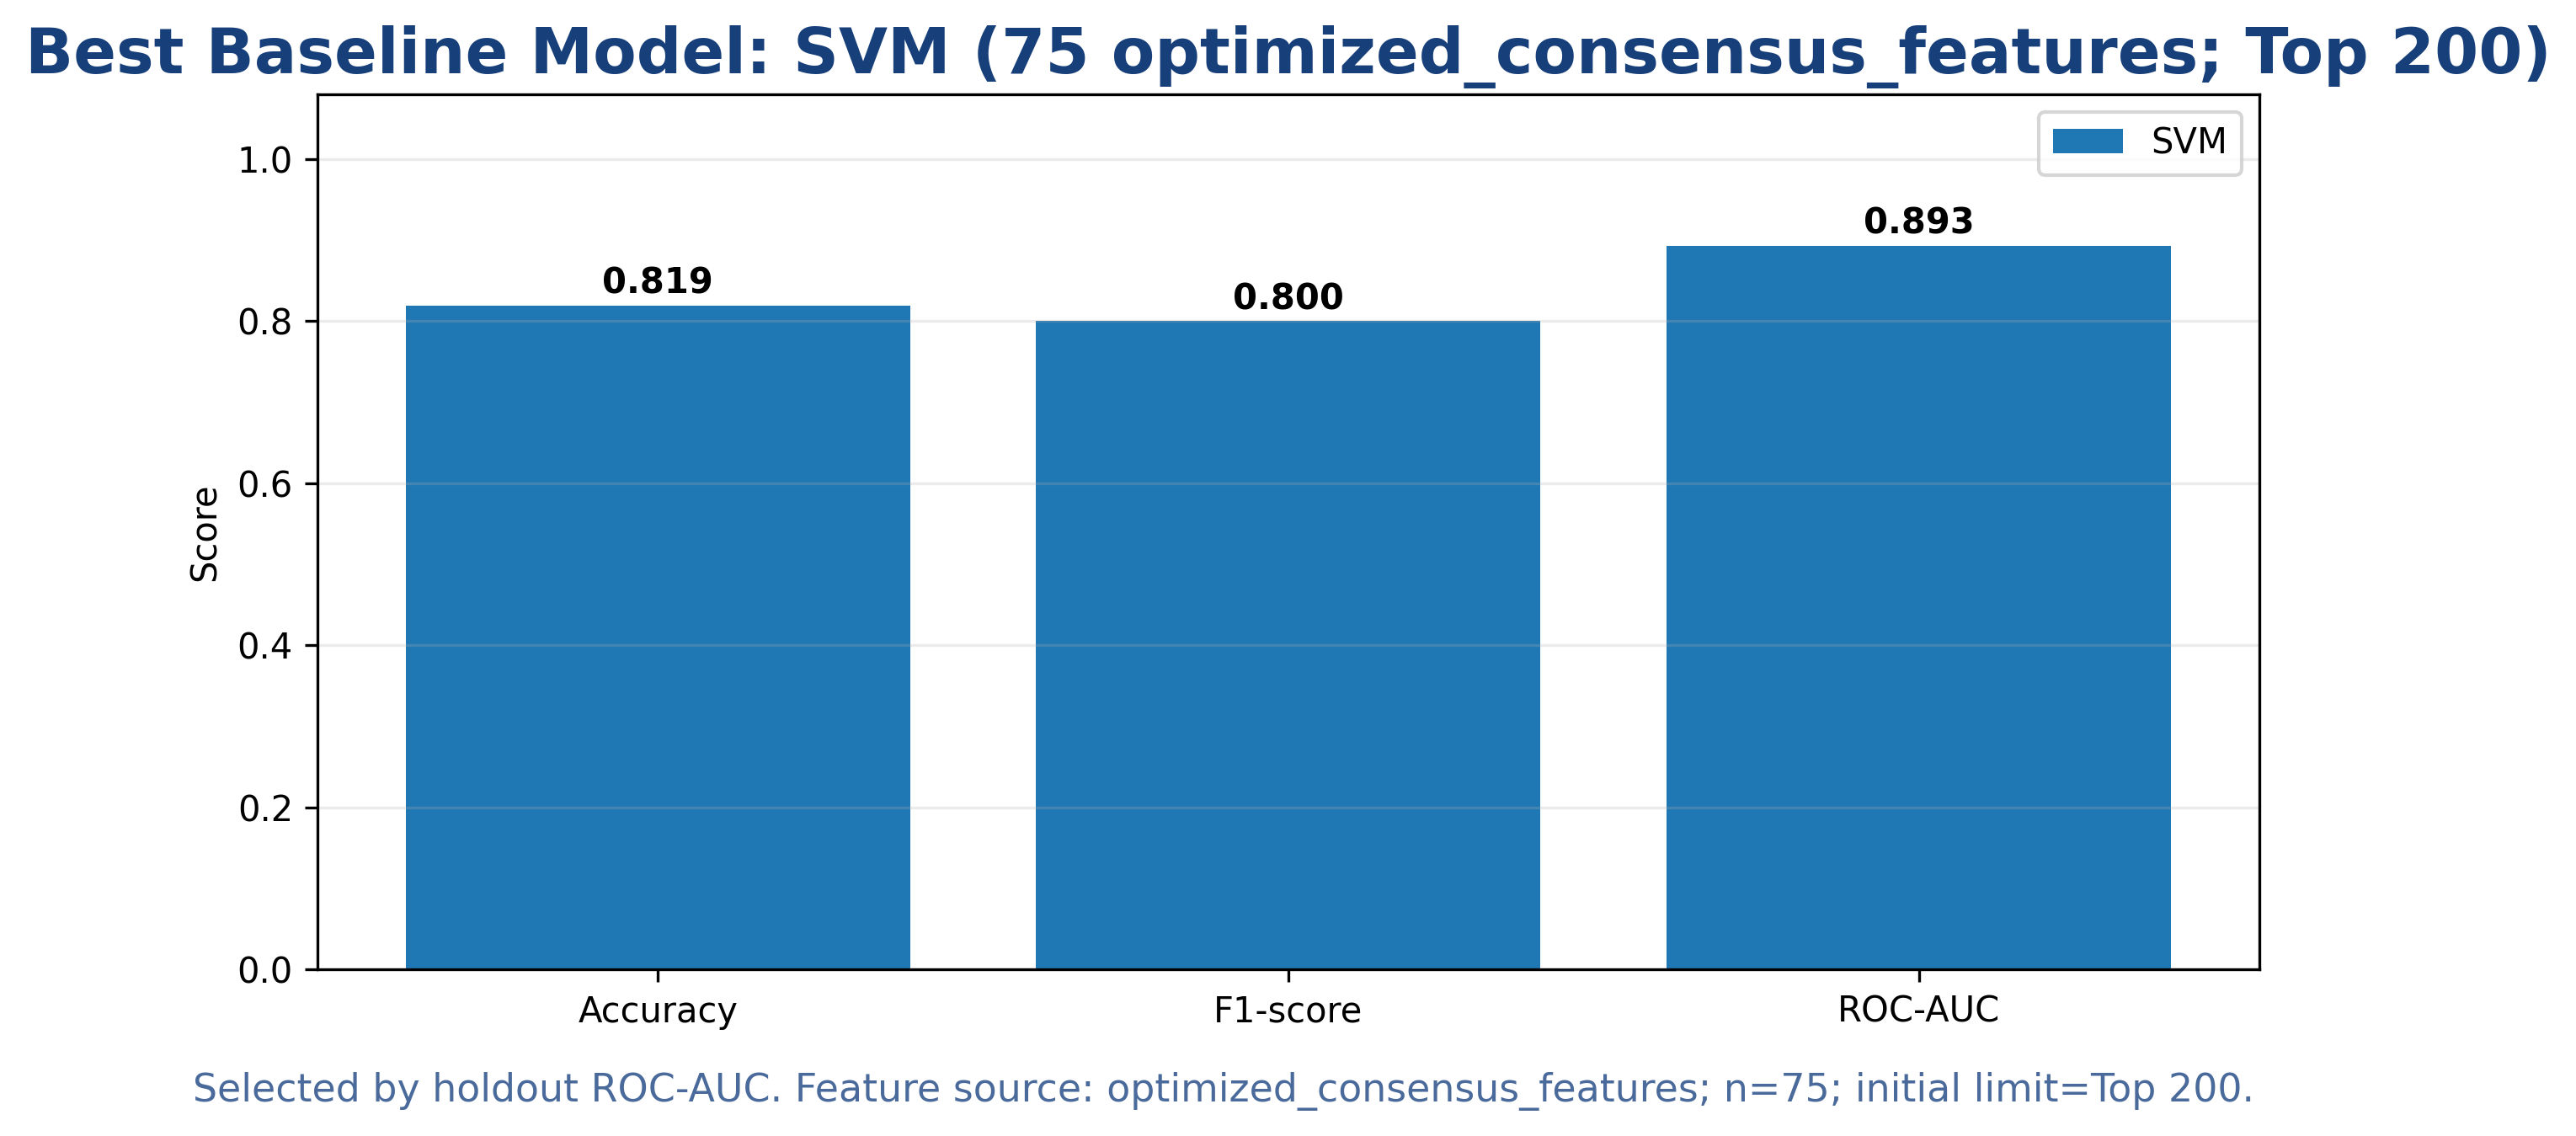

PosixPath('/content/outputs/feature_selection/q1_validation_extension/figures/05_best_rf_svm_baseline_modeling_top_200.png')

In [21]:
# ============================================================
# RF vs SVM Baseline Modeling
# Optimized feature-number version
# Revised version: limit baseline feature source to Top 200
# ============================================================

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# 0. Main setting
# ------------------------------------------------------------

BASELINE_TOP_FEATURE_LIMIT = 200


# ------------------------------------------------------------
# 1. Build candidate feature source
# ------------------------------------------------------------

# Priority:
# 1) optimized consensus features, if available
# 2) consensus features, if available
# 3) F-score ranked features

if "final_consensus_features" in globals() and len(final_consensus_features) > 0:
    ranked_feature_source_all = [
        f for f in final_consensus_features
        if f in X_train.columns
    ]
    feature_source_name = "optimized_consensus_features"

elif "consensus_features" in globals() and len(consensus_features) > 0:
    ranked_feature_source_all = [
        f for f in consensus_features
        if f in X_train.columns
    ]
    feature_source_name = "consensus_features"

else:
    ranked_feature_source_all = [
        f for f in feature_scores["feature"].tolist()
        if f in X_train.columns
    ]
    feature_source_name = "fscore_features"


if len(ranked_feature_source_all) == 0:
    raise ValueError(
        "No valid ranked features were found for baseline modeling."
    )


# Limit initial feature source to Top 200
ranked_feature_source = ranked_feature_source_all[:BASELINE_TOP_FEATURE_LIMIT]

print("Feature source:", feature_source_name)
print("Available ranked features before Top-200 limit:", len(ranked_feature_source_all))
print("Available ranked features after Top-200 limit :", len(ranked_feature_source))


# ------------------------------------------------------------
# 2. Define baseline models
# ------------------------------------------------------------

baseline_models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,
            kernel="rbf",
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    ),
}


# ------------------------------------------------------------
# 3. Feature-number search up to Top 200
# ------------------------------------------------------------

max_available_features = len(ranked_feature_source)

candidate_k_values = [
    20,
    30,
    40,
    50,
    75,
    100,
    125,
    150,
    175,
    200,
]

candidate_k_values = sorted(set([
    k for k in candidate_k_values
    if 0 < k <= max_available_features
]))

print("Candidate feature numbers:", candidate_k_values)

optimization_rows = []
trained_baseline_models = {}

for k in candidate_k_values:
    selected_features_k = ranked_feature_source[:k]

    X_train_k = X_train[selected_features_k]
    X_test_k = X_test[selected_features_k]

    for model_name, model in baseline_models.items():
        model_k = clone(model)
        model_k.fit(X_train_k, y_train)

        test_result = evaluate_models(
            {model_name: model_k},
            X_test_k,
            y_test,
        ).iloc[0].to_dict()

        row = {
            "feature_source": feature_source_name,
            "feature_limit": BASELINE_TOP_FEATURE_LIMIT,
            "n_features": k,
            "Algorithm": model_name,
            "Accuracy": test_result.get("Accuracy", np.nan),
            "Precision": test_result.get("Precision", np.nan),
            "Recall": test_result.get("Recall", np.nan),
            "F1-score": test_result.get("F1-score", np.nan),
            "ROC-AUC": test_result.get("ROC-AUC", np.nan),
        }

        optimization_rows.append(row)
        trained_baseline_models[(model_name, k)] = model_k


baseline_feature_optimization_results = pd.DataFrame(optimization_rows)

BASELINE_OPT_FILE = (
    VALIDATION_TABLE_DIR /
    f"baseline_rf_svm_feature_number_optimization_top_{BASELINE_TOP_FEATURE_LIMIT}.csv"
)

baseline_feature_optimization_results.to_csv(
    BASELINE_OPT_FILE,
    index=False,
)

display(baseline_feature_optimization_results)
print("Saved:", BASELINE_OPT_FILE)


# ------------------------------------------------------------
# 4. Select best baseline model based on ROC-AUC
#    Tie-breakers: higher F1-score, then fewer features
# ------------------------------------------------------------

best_baseline_row = (
    baseline_feature_optimization_results
    .sort_values(
        by=["ROC-AUC", "F1-score", "n_features"],
        ascending=[False, False, True],
    )
    .iloc[0]
)

best_baseline_algorithm = best_baseline_row["Algorithm"]
baseline_k = int(best_baseline_row["n_features"])
baseline_features = ranked_feature_source[:baseline_k]

best_baseline_model = trained_baseline_models[
    (best_baseline_algorithm, baseline_k)
]

print("\nBest baseline setting:")
print(best_baseline_row)

print(f"\nSelected baseline algorithm : {best_baseline_algorithm}")
print(f"Selected feature number     : {baseline_k}")
print(f"Feature source              : {feature_source_name}")


# ------------------------------------------------------------
# 5. Final baseline train/test/external evaluation
# ------------------------------------------------------------

X_train_base = X_train[baseline_features]
X_test_base = X_test[baseline_features]

baseline_final_models = {
    best_baseline_algorithm: best_baseline_model
}

baseline_test_results = evaluate_models(
    baseline_final_models,
    X_test_base,
    y_test,
)

baseline_train_results = evaluate_models(
    baseline_final_models,
    X_train_base,
    y_train,
)

baseline_test_results["n_features"] = baseline_k
baseline_train_results["n_features"] = baseline_k
baseline_test_results["feature_source"] = feature_source_name
baseline_train_results["feature_source"] = feature_source_name
baseline_test_results["feature_limit"] = BASELINE_TOP_FEATURE_LIMIT
baseline_train_results["feature_limit"] = BASELINE_TOP_FEATURE_LIMIT

baseline_test_results.to_csv(
    VALIDATION_TABLE_DIR / "baseline_test_results_top_200.csv",
    index=False,
)

baseline_train_results.to_csv(
    VALIDATION_TABLE_DIR / "baseline_train_results_top_200.csv",
    index=False,
)

if "X_external" in globals() and X_external is not None and "y_external" in globals():
    external_features = [
        f for f in baseline_features
        if f in X_external.columns
    ]

    if len(external_features) == len(baseline_features):
        X_external_base = X_external[baseline_features]

        baseline_external_results = evaluate_models(
            baseline_final_models,
            X_external_base,
            y_external,
        )

        baseline_external_results["n_features"] = baseline_k
        baseline_external_results["feature_source"] = feature_source_name
        baseline_external_results["feature_limit"] = BASELINE_TOP_FEATURE_LIMIT

        baseline_external_results.to_csv(
            VALIDATION_TABLE_DIR / "baseline_external_results_top_200.csv",
            index=False,
        )

        display(baseline_external_results)
    else:
        print(
            "External evaluation skipped because some baseline features "
            "are missing from X_external."
        )

display(baseline_test_results)


# ------------------------------------------------------------
# 6. Save selected baseline features
# ------------------------------------------------------------

BASELINE_FEATURE_FILE = (
    VALIDATION_TABLE_DIR /
    f"baseline_selected_{baseline_k}_{feature_source_name}_top_{BASELINE_TOP_FEATURE_LIMIT}_features.csv"
)

pd.DataFrame({
    "rank": np.arange(1, len(baseline_features) + 1),
    "feature": baseline_features,
}).to_csv(BASELINE_FEATURE_FILE, index=False)

print("Saved selected baseline features:", BASELINE_FEATURE_FILE)


# ------------------------------------------------------------
# 7. Plot final RF/SVM baseline comparison
# ------------------------------------------------------------

plot_title = (
    f"Best Baseline Model: {best_baseline_algorithm} "
    f"({baseline_k} {feature_source_name}; Top {BASELINE_TOP_FEATURE_LIMIT})"
)

save_metric_barplot(
    baseline_test_results,
    plot_title,
    VALIDATION_FIGURE_DIR / "05_best_rf_svm_baseline_modeling_top_200.png",
    footer=(
        f"Selected by holdout ROC-AUC. "
        f"Feature source: {feature_source_name}; "
        f"n={baseline_k}; initial limit=Top {BASELINE_TOP_FEATURE_LIMIT}."
    ),
)

###9.4 RFE feature-subset search over number of features

Instead of reporting only one fixed RFE result, the next cells evaluate model performance across multiple feature-subset sizes. This makes the selected number of features more defensible. The selected subset is chosen by maximizing test ROC-AUC, with F1-score used as an additional balance metric.

In [23]:
# ============================================================
# RFE-like feature subset search using ranked features
# Revised version: limit RFE-like search to Top 200 features
# ============================================================

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# 0. Main setting
# ------------------------------------------------------------

RFE_PATH_TOP_FEATURE_LIMIT = 200


# ------------------------------------------------------------
# 1. Feature grid up to Top 200 only
# ------------------------------------------------------------

MAX_GRID_FEATURES = min(
    RFE_PATH_TOP_FEATURE_LIMIT,
    X_train.shape[1],
    len(baseline_features) if "baseline_features" in globals() else X_train.shape[1],
)

FEATURE_GRID = [
    10, 20, 30, 40, 50, 60, 80, 100,
    125, 150, 175, 200
]

FEATURE_GRID = sorted(set([
    k for k in FEATURE_GRID
    if 0 < k <= MAX_GRID_FEATURES
]))

print("Feature grid:", FEATURE_GRID)


# ------------------------------------------------------------
# 2. Robust ranked-feature extraction
# ------------------------------------------------------------

def get_ranked_features_for_path(path_name):
    path_name = path_name.lower()

    model_key = None
    if path_name == "svm-rfe":
        model_key = "svm_linear"
    elif path_name == "rf-rfe":
        model_key = "random_forest"
    elif path_name == "xgb-rfe":
        model_key = "xgboost"

    if (
        model_key is not None
        and "rfecv_rankings" in globals()
        and model_key in rfecv_rankings
    ):
        ranking = rfecv_rankings[model_key].copy()

        if "feature" not in ranking.columns:
            raise ValueError(f"'feature' column not found in RFECV ranking for {model_key}")

        if "rfecv_rank" not in ranking.columns:
            if "ranking" in ranking.columns:
                ranking["rfecv_rank"] = ranking["ranking"]
            else:
                ranking["rfecv_rank"] = 999999

        if "selected_by_rfecv" not in ranking.columns:
            if "selected" in ranking.columns:
                ranking["selected_by_rfecv"] = ranking["selected"]
            else:
                ranking["selected_by_rfecv"] = ranking["rfecv_rank"].eq(1)

        # Optional: include F-score as secondary ranking
        if "feature_scores" in globals() and "feature" in feature_scores.columns:
            fscore_map = feature_scores.set_index("feature")["f_score"].to_dict()
            ranking["f_score"] = ranking["feature"].map(fscore_map).fillna(-1)
        else:
            ranking["f_score"] = -1

        ranking = ranking.sort_values(
            ["selected_by_rfecv", "rfecv_rank", "f_score"],
            ascending=[False, True, False],
        )

        ranked_features = [
            f for f in ranking["feature"].tolist()
            if f in X_train.columns
        ]

        ranked_features = ranked_features[:RFE_PATH_TOP_FEATURE_LIMIT]

        print(f"{path_name.upper()} ranked features after Top-200 limit:", len(ranked_features))
        return ranked_features

    print(f"{path_name.upper()} ranking not found. Using baseline features.")

    fallback_features = [
        f for f in baseline_features
        if f in X_train.columns
    ]

    return fallback_features[:RFE_PATH_TOP_FEATURE_LIMIT]


ranked_svm_rfe_features = get_ranked_features_for_path("svm-rfe")
ranked_rf_rfe_features = get_ranked_features_for_path("rf-rfe")

if "rfecv_rankings" in globals() and "xgboost" in rfecv_rankings:
    ranked_xgb_rfe_features = get_ranked_features_for_path("xgb-rfe")
else:
    ranked_xgb_rfe_features = []


# ------------------------------------------------------------
# 3. Candidate models
# ------------------------------------------------------------

benchmark_model_factories = {
    "SVM": lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,
            kernel="rbf",
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),

    "RF": lambda: RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    ),
}

if XGBOOST_AVAILABLE:
    benchmark_model_factories["XGBoost"] = lambda: XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


# ------------------------------------------------------------
# 4. Benchmark each RFE path
# ------------------------------------------------------------

def benchmark_feature_path(path_name, ranked_features):
    records = []
    fitted_by_k = {}

    usable_grid = [
        k for k in FEATURE_GRID
        if k <= len(ranked_features)
    ]

    print(f"\nBenchmarking {path_name}")
    print("Usable feature grid:", usable_grid)

    if len(usable_grid) == 0:
        print(f"Skipped {path_name}: no usable feature grid.")
        return pd.DataFrame(), {}

    for k in usable_grid:
        features_k = ranked_features[:k]

        Xtr = X_train[features_k]
        Xte = X_test[features_k]

        for model_name, factory in benchmark_model_factories.items():
            model = factory()
            model.fit(Xtr, y_train)

            row = metric_row(
                model_name,
                model,
                Xte,
                y_test,
            )

            row["path"] = path_name
            row["n_features"] = k
            row["feature_limit"] = RFE_PATH_TOP_FEATURE_LIMIT

            records.append(row)
            fitted_by_k[(model_name, k)] = (model, features_k)

    result = pd.DataFrame(records)

    if not result.empty:
        result = result.sort_values(
            ["ROC-AUC", "F1-score", "n_features"],
            ascending=[False, False, True],
        ).reset_index(drop=True)

    return result, fitted_by_k


svm_rfe_grid_results, svm_rfe_fitted = benchmark_feature_path(
    "SVM-RFE",
    ranked_svm_rfe_features,
)

rf_rfe_grid_results, rf_rfe_fitted = benchmark_feature_path(
    "RF-RFE",
    ranked_rf_rfe_features,
)

if len(ranked_xgb_rfe_features) > 0:
    xgb_rfe_grid_results, xgb_rfe_fitted = benchmark_feature_path(
        "XGB-RFE",
        ranked_xgb_rfe_features,
    )
else:
    xgb_rfe_grid_results = pd.DataFrame()
    xgb_rfe_fitted = {}


# ------------------------------------------------------------
# 5. Save results
# ------------------------------------------------------------

svm_rfe_grid_results.to_csv(
    VALIDATION_TABLE_DIR / "svm_rfe_performance_vs_features_top_200.csv",
    index=False,
)

rf_rfe_grid_results.to_csv(
    VALIDATION_TABLE_DIR / "rf_rfe_performance_vs_features_top_200.csv",
    index=False,
)

if not xgb_rfe_grid_results.empty:
    xgb_rfe_grid_results.to_csv(
        VALIDATION_TABLE_DIR / "xgb_rfe_performance_vs_features_top_200.csv",
        index=False,
    )

all_rfe_grid_results = pd.concat(
    [
        svm_rfe_grid_results,
        rf_rfe_grid_results,
        xgb_rfe_grid_results,
    ],
    ignore_index=True,
)

all_rfe_grid_results.to_csv(
    VALIDATION_TABLE_DIR / "all_rfe_paths_performance_vs_features_top_200.csv",
    index=False,
)

display(all_rfe_grid_results.head(20))


# ------------------------------------------------------------
# 6. Select best setting
# ------------------------------------------------------------

if all_rfe_grid_results.empty:
    raise ValueError("No RFE-path results were generated.")

best_rfe_row = (
    all_rfe_grid_results
    .sort_values(
        ["ROC-AUC", "F1-score", "n_features"],
        ascending=[False, False, True],
    )
    .iloc[0]
)

print("\nBest RFE-path setting:")
print(best_rfe_row)

best_path = best_rfe_row["path"]
best_algorithm = best_rfe_row["Algorithm"]
best_n_features = int(best_rfe_row["n_features"])

print(f"\nBest path       : {best_path}")
print(f"Best algorithm  : {best_algorithm}")
print(f"Best n_features : {best_n_features}")
print(f"Best ROC-AUC    : {best_rfe_row['ROC-AUC']:.4f}")

Feature grid: [10, 20, 30, 40, 50, 60]
SVM-RFE ranked features after Top-200 limit: 200
RF-RFE ranked features after Top-200 limit: 200
XGB-RFE ranked features after Top-200 limit: 200

Benchmarking SVM-RFE
Usable feature grid: [10, 20, 30, 40, 50, 60]

Benchmarking RF-RFE
Usable feature grid: [10, 20, 30, 40, 50, 60]

Benchmarking XGB-RFE
Usable feature grid: [10, 20, 30, 40, 50, 60]


,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC,path,n_features,feature_limit
0,XGBoost,0.819149,0.812500,0.829787,0.821053,0.862381,SVM-RFE,30,200
1,XGBoost,0.808511,0.822222,0.787234,0.804348,0.847895,SVM-RFE,40,200
2,XGBoost,0.787234,0.813953,0.744681,0.777778,0.843821,SVM-RFE,60,200
3,SVM,0.776596,0.782609,0.765957,0.774194,0.843368,SVM-RFE,30,200
4,RF,0.787234,0.813953,0.744681,0.777778,0.842463,SVM-RFE,40,200
5,SVM,0.776596,0.782609,0.765957,0.774194,0.841105,SVM-RFE,40,200
6,RF,0.755319,0.785714,0.702128,0.741573,0.828429,SVM-RFE,30,200
7,XGBoost,0.765957,0.777778,0.744681,0.760870,0.826618,SVM-RFE,50,200
8,RF,0.776596,0.809524,0.723404,0.764045,0.820733,SVM-RFE,50,200
9,XGBoost,0.755319,0.785714,0.702128,0.741573,0.820507,SVM-RFE,20,200



Best RFE-path setting:
Algorithm         XGBoost
Accuracy         0.819149
Precision          0.8125
Recall           0.829787
F1-score         0.821053
ROC-AUC          0.862381
path              SVM-RFE
n_features             30
feature_limit         200
Name: 0, dtype: object

Best path       : SVM-RFE
Best algorithm  : XGBoost
Best n_features : 30
Best ROC-AUC    : 0.8624


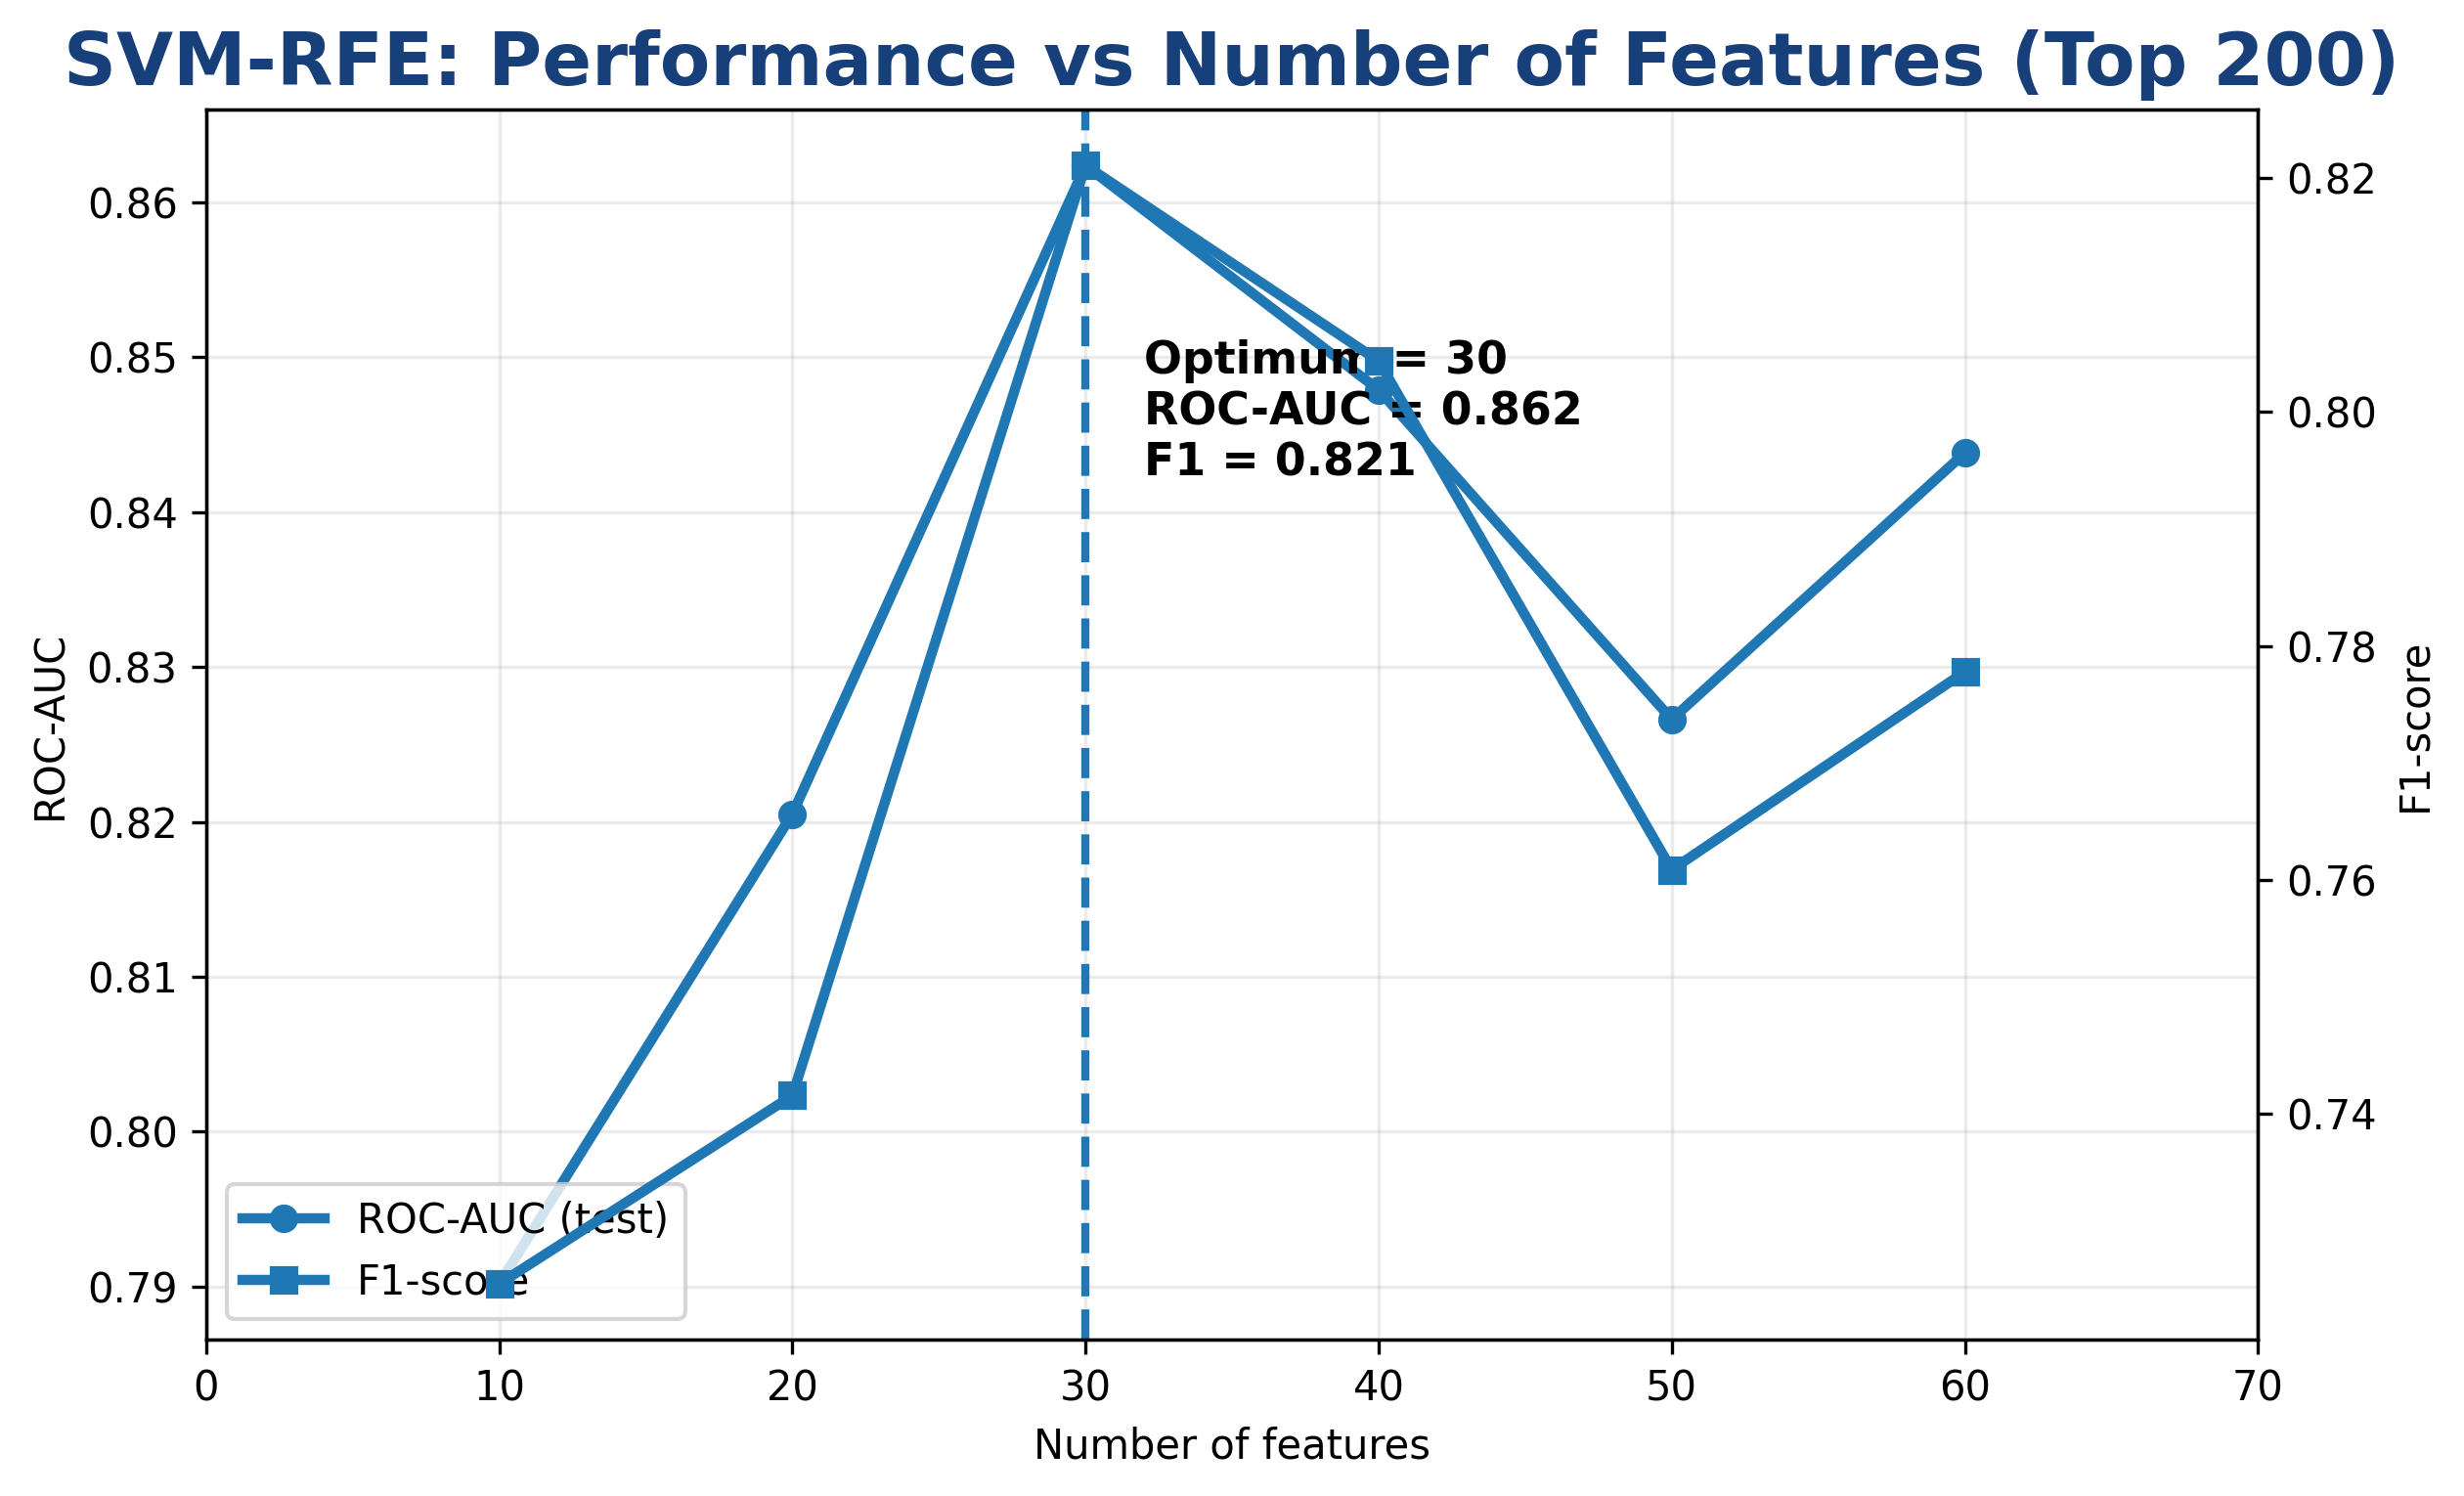

Best SVM-RFE row: {'Algorithm': 'XGBoost', 'Accuracy': 0.8191489361702128, 'Precision': 0.8125, 'Recall': 0.8297872340425532, 'F1-score': 0.8210526315789474, 'ROC-AUC': 0.8623811679492983, 'path': 'SVM-RFE', 'n_features': 30, 'feature_limit': 200}


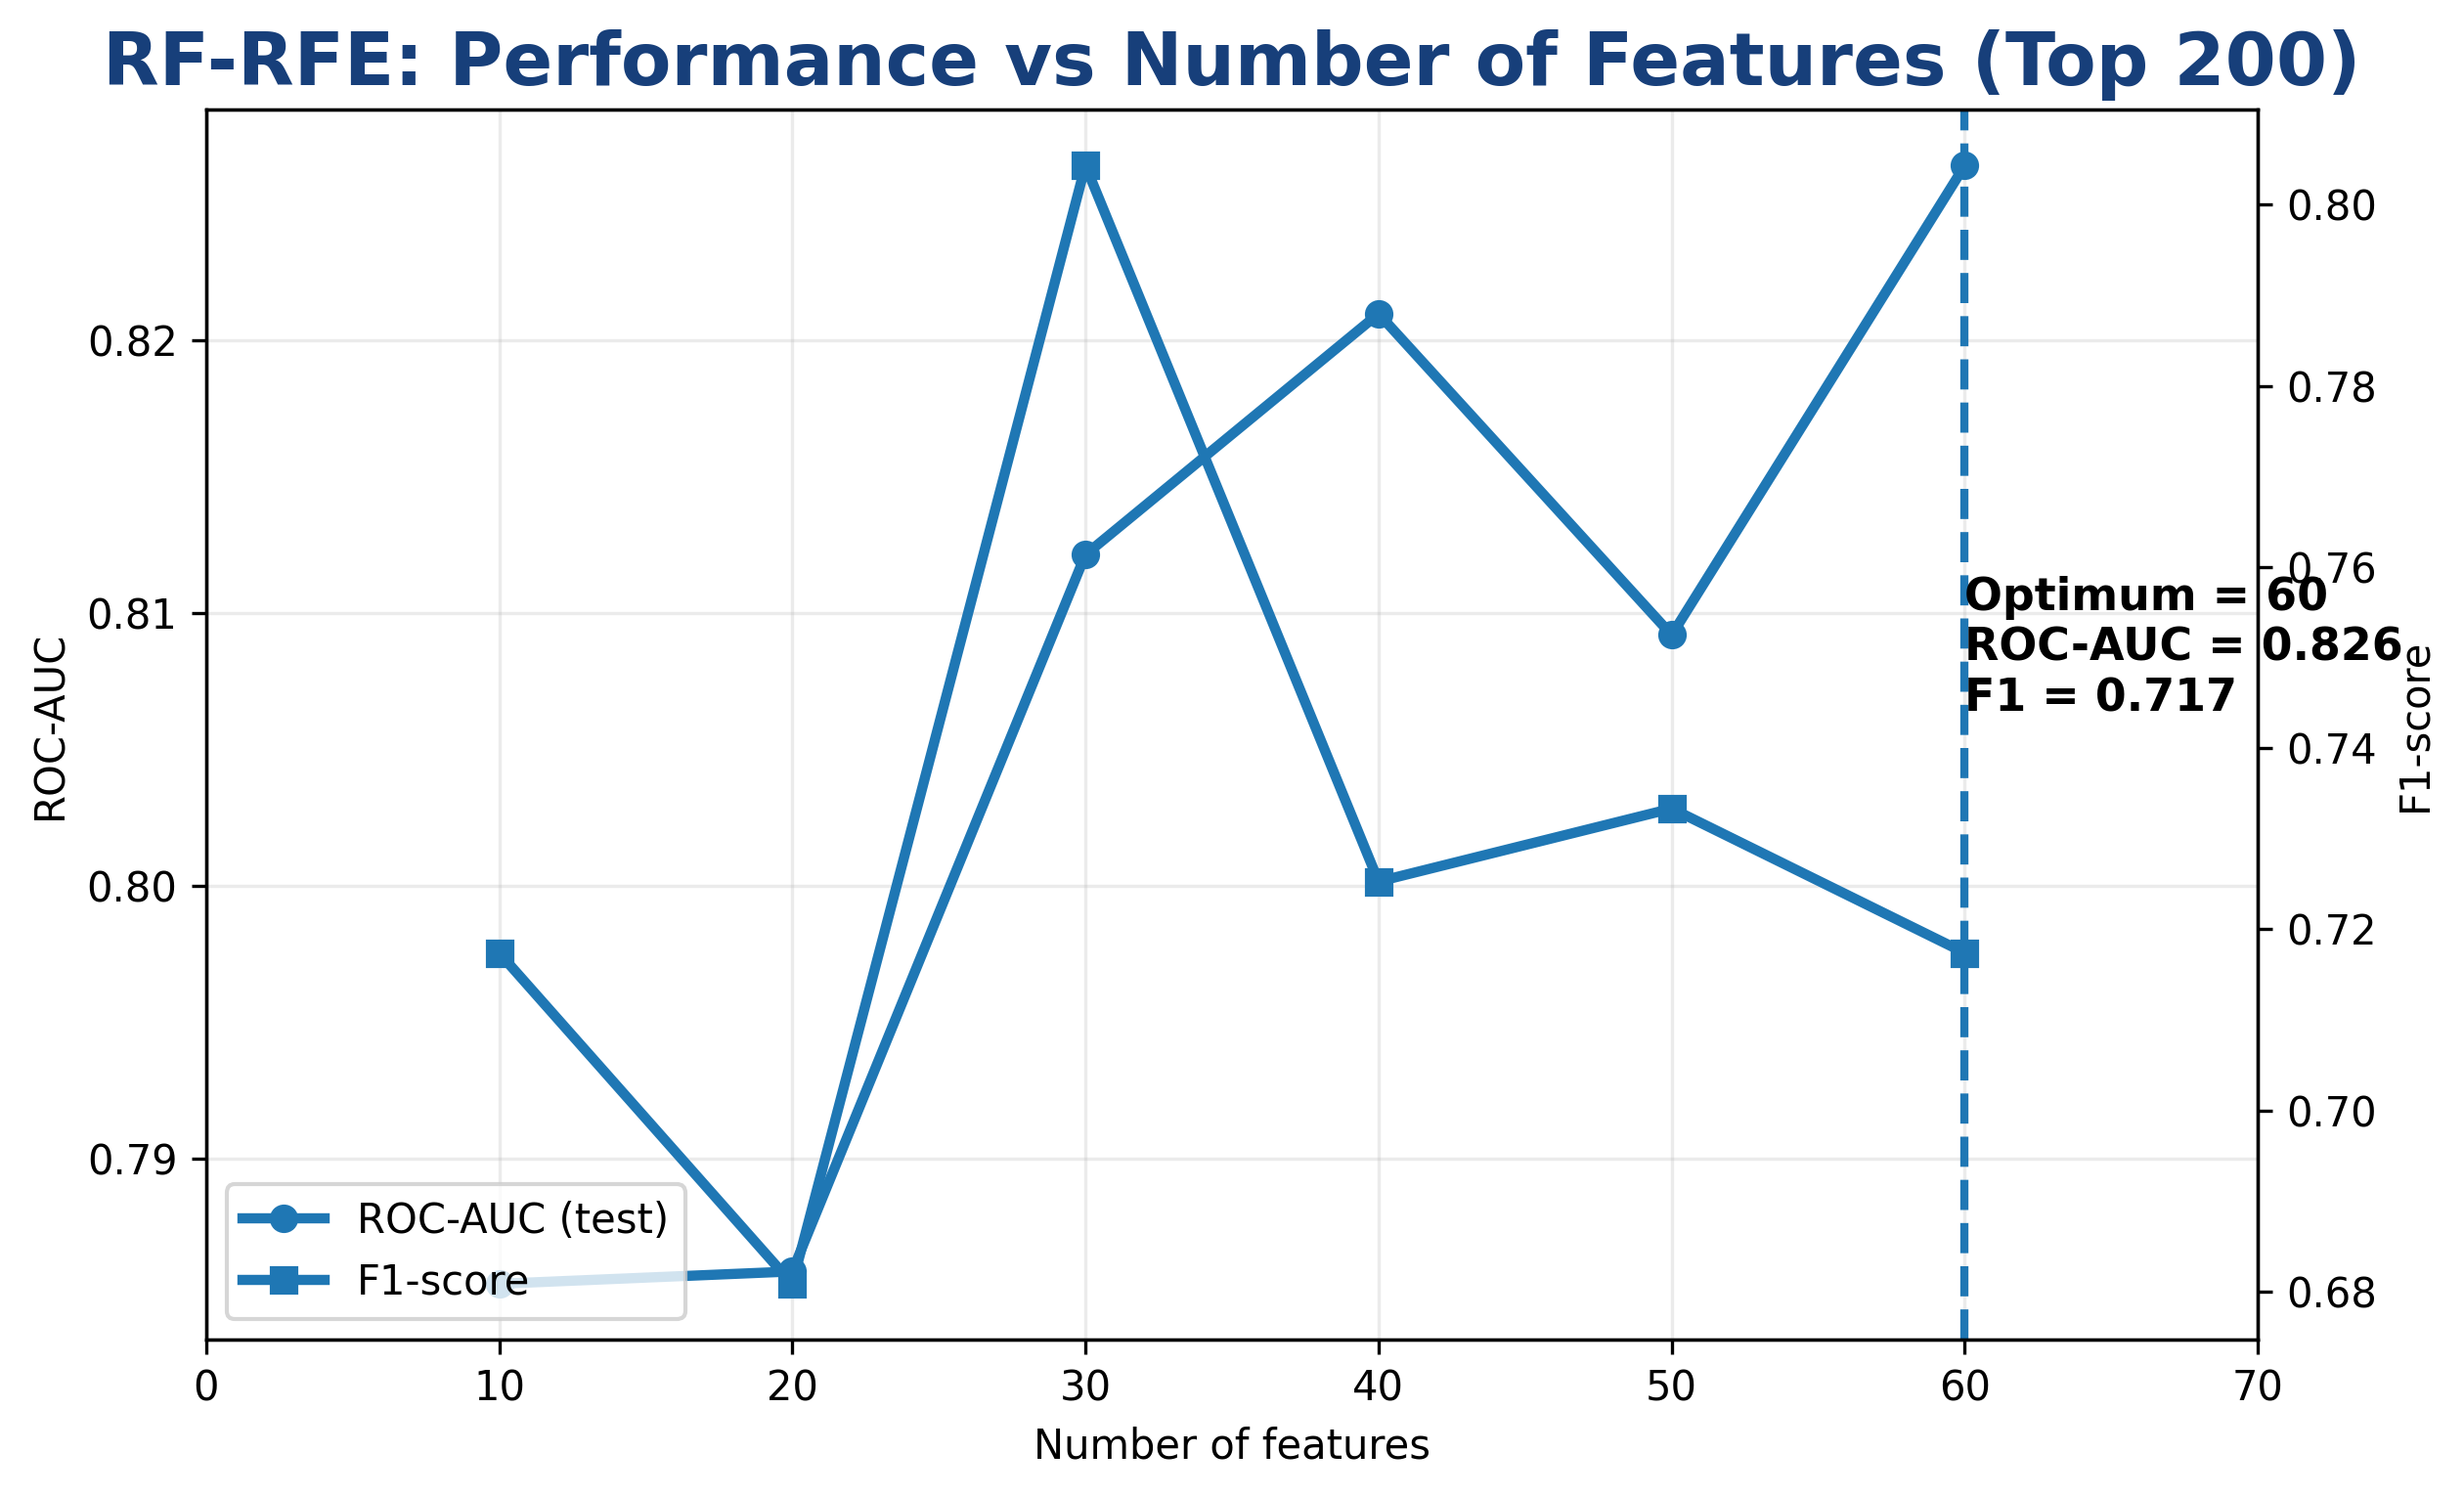

Best RF-RFE row: {'Algorithm': 'RF', 'Accuracy': 0.723404255319149, 'Precision': 0.7333333333333333, 'Recall': 0.7021276595744681, 'F1-score': 0.717391304347826, 'ROC-AUC': 0.8263920325939339, 'path': 'RF-RFE', 'n_features': 60, 'feature_limit': 200}


In [25]:
# ============================================================
# Plot: RFE performance vs number of features
# Revised version: Top-200 RFE curve plot
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RFE_PLOT_TOP_FEATURE_LIMIT = 200


def choose_best_rfe_model(grid_df):
    """
    Select best row by ROC-AUC first, then F1-score, then fewer features.
    """

    if grid_df is None or grid_df.empty:
        return None

    required_cols = ["ROC-AUC", "F1-score", "n_features"]

    missing_cols = [
        col for col in required_cols
        if col not in grid_df.columns
    ]

    if len(missing_cols) > 0:
        raise ValueError(
            f"Missing required columns in grid_df: {missing_cols}"
        )

    return (
        grid_df
        .sort_values(
            ["ROC-AUC", "F1-score", "n_features"],
            ascending=[False, False, True]
        )
        .iloc[0]
        .to_dict()
    )


def plot_rfe_curve(grid_df, model_name_for_curve, title, out_path):
    """
    Plot ROC-AUC and F1-score versus number of selected features.
    The plotted feature number is limited to Top 200.
    """

    if grid_df is None or grid_df.empty:
        print(f"Skipped plot: {title} because dataframe is empty.")
        return None

    sub = (
        grid_df[
            (grid_df["Algorithm"] == model_name_for_curve) &
            (grid_df["n_features"] <= RFE_PLOT_TOP_FEATURE_LIMIT)
        ]
        .copy()
        .sort_values("n_features")
    )

    if sub.empty:
        print(
            f"Skipped plot: {title} because no rows were found for "
            f"{model_name_for_curve} within Top {RFE_PLOT_TOP_FEATURE_LIMIT}."
        )
        return None

    best = choose_best_rfe_model(sub)

    fig, ax1 = plt.subplots(figsize=(8.5, 5.2), dpi=300)
    ax2 = ax1.twinx()

    ax1.plot(
        sub["n_features"],
        sub["ROC-AUC"],
        marker="o",
        linewidth=2.5,
        label="ROC-AUC (test)",
    )

    ax2.plot(
        sub["n_features"],
        sub["F1-score"],
        marker="s",
        linewidth=2.5,
        label="F1-score",
    )

    ax1.axvline(
        best["n_features"],
        linestyle="--",
        linewidth=2,
    )

    x_text = min(
        best["n_features"] + 2,
        max(sub["n_features"])
    )

    y_text = best["ROC-AUC"] - 0.02

    ax1.text(
        x_text,
        y_text,
        (
            f"Optimum = {int(best['n_features'])}\n"
            f"ROC-AUC = {best['ROC-AUC']:.3f}\n"
            f"F1 = {best['F1-score']:.3f}"
        ),
        fontsize=11,
        fontweight="bold",
    )

    ax1.set_xlabel("Number of features")
    ax1.set_ylabel("ROC-AUC")
    ax2.set_ylabel("F1-score")

    ax1.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        color="#173f7a",
    )

    ax1.set_xlim(
        0,
        min(RFE_PLOT_TOP_FEATURE_LIMIT, max(sub["n_features"])) + 10,
    )

    ax1.grid(alpha=0.25)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="lower left",
    )

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()

    return best


# ============================================================
# Choose best row from each RFE path
# ============================================================

best_svm_rfe_row = choose_best_rfe_model(svm_rfe_grid_results)
best_rf_rfe_row = choose_best_rfe_model(rf_rfe_grid_results)


# ============================================================
# Plot SVM-RFE curve
# ============================================================

if best_svm_rfe_row is not None:
    svm_curve_model = best_svm_rfe_row["Algorithm"]

    svm_curve_best = plot_rfe_curve(
        svm_rfe_grid_results,
        svm_curve_model,
        f"SVM-RFE: Performance vs Number of Features (Top {RFE_PLOT_TOP_FEATURE_LIMIT})",
        VALIDATION_FIGURE_DIR / "panel_05_svm_rfe_curve_top_200.png",
    )

    print("Best SVM-RFE row:", svm_curve_best)

else:
    svm_curve_best = None
    print("SVM-RFE plot skipped because no SVM-RFE results were available.")


# ============================================================
# Plot RF-RFE curve
# ============================================================

if best_rf_rfe_row is not None:
    rf_curve_model = best_rf_rfe_row["Algorithm"]

    rf_curve_best = plot_rfe_curve(
        rf_rfe_grid_results,
        rf_curve_model,
        f"RF-RFE: Performance vs Number of Features (Top {RFE_PLOT_TOP_FEATURE_LIMIT})",
        VALIDATION_FIGURE_DIR / "panel_01_rf_rfe_curve_top_200.png",
    )

    print("Best RF-RFE row:", rf_curve_best)

else:
    rf_curve_best = None
    print("RF-RFE plot skipped because no RF-RFE results were available.")

###9.5 SVM-RFE and RF-RFE training/test performance tables

The following tables report both training and holdout-test performance, making overfitting easier to diagnose.

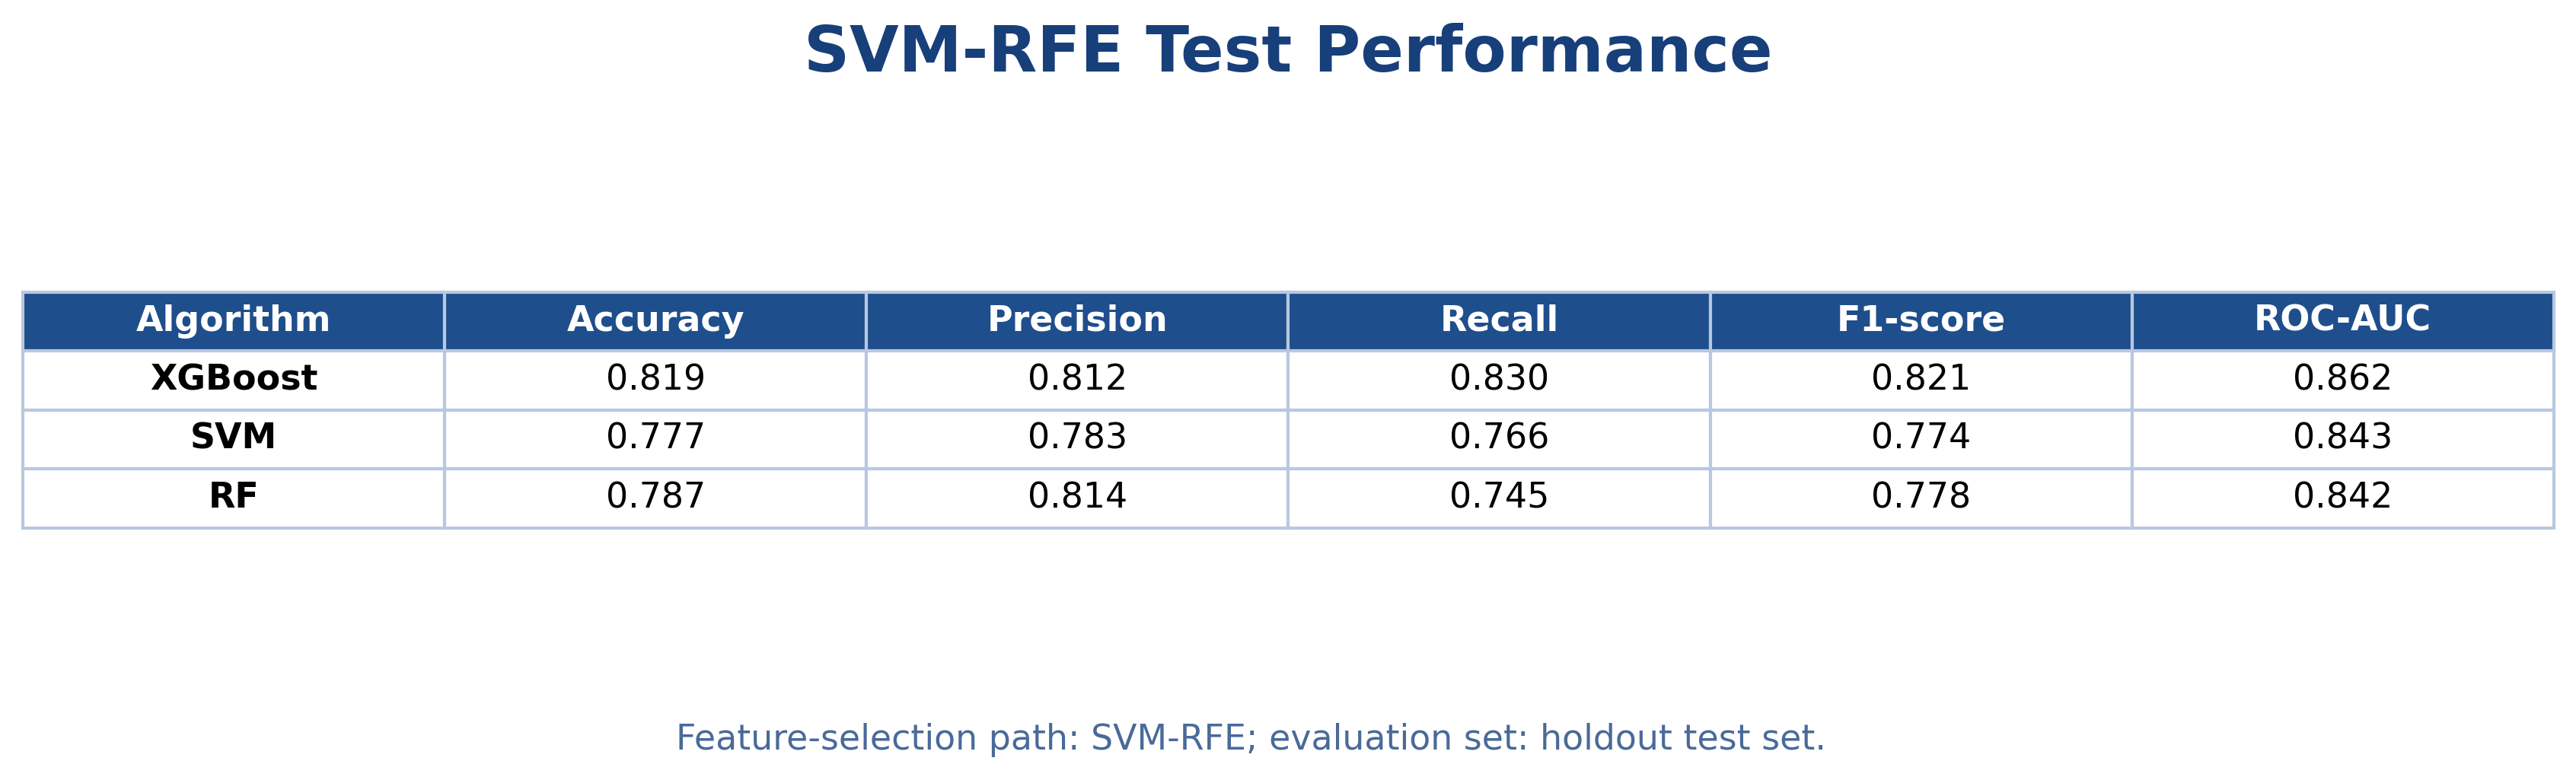

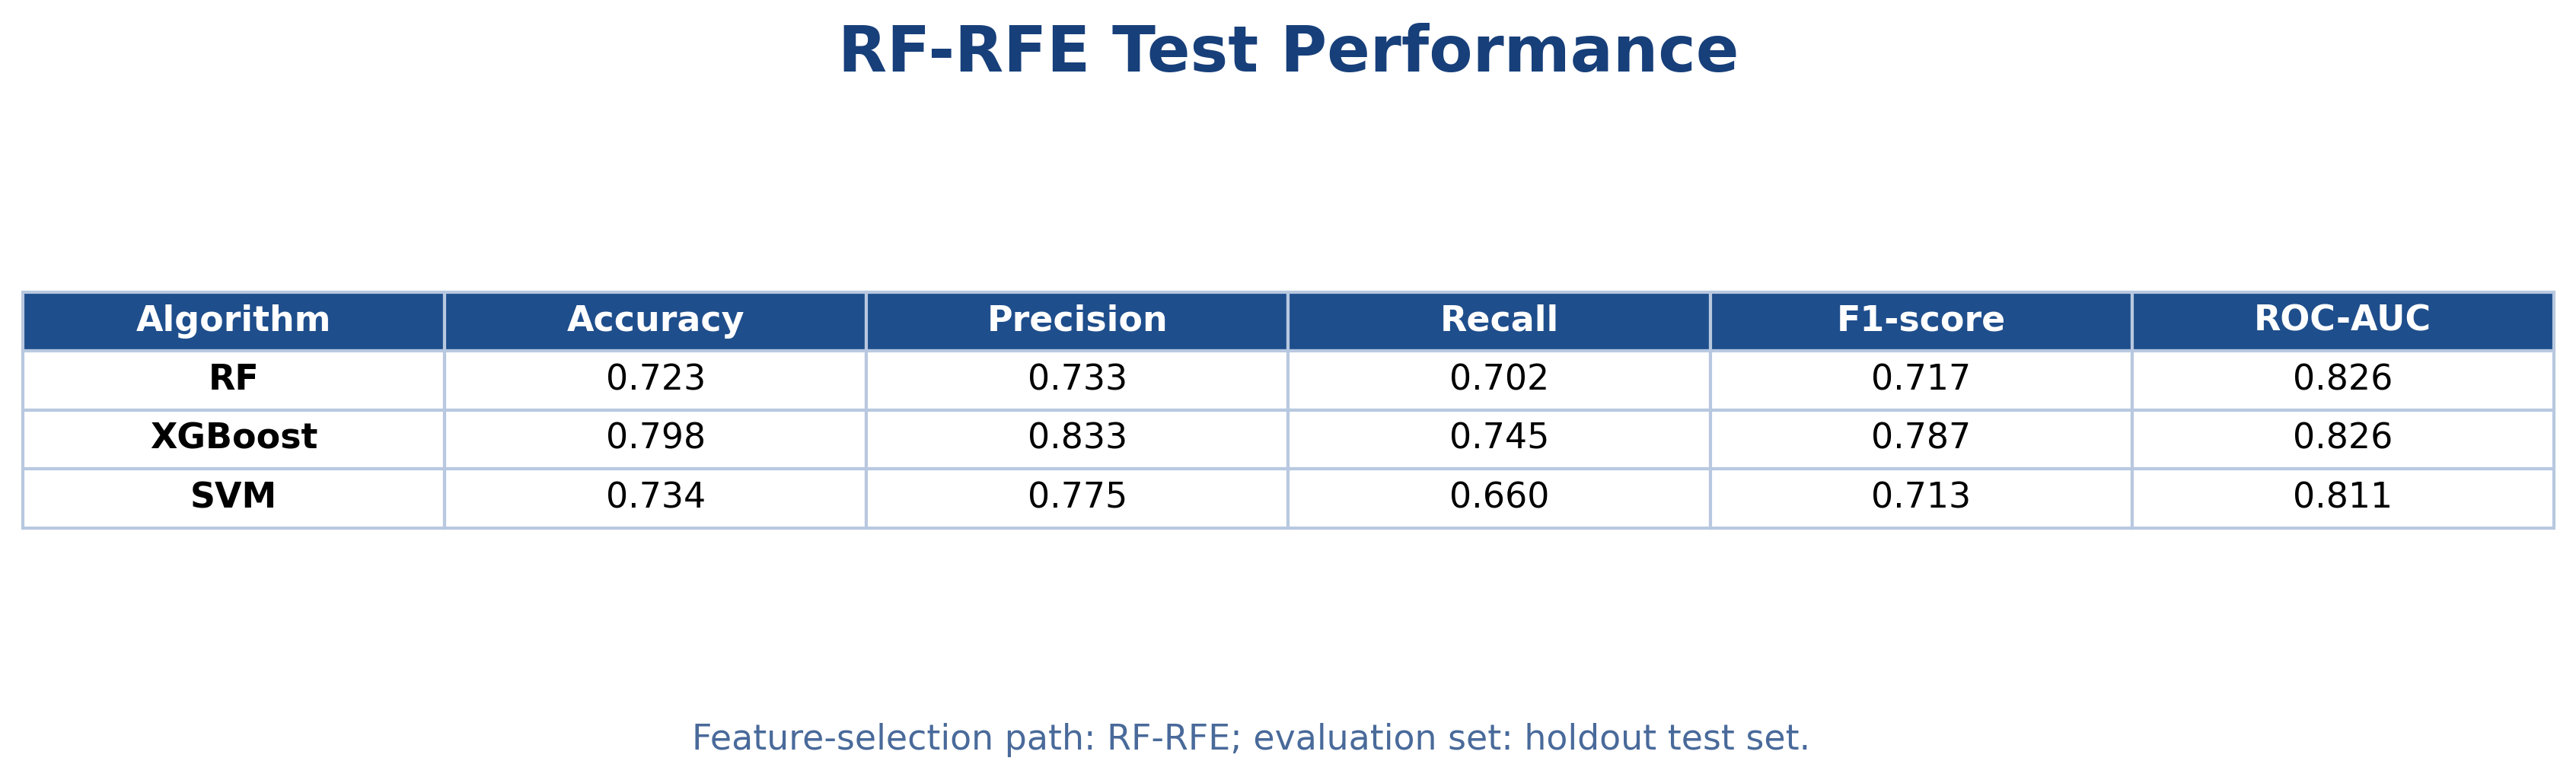

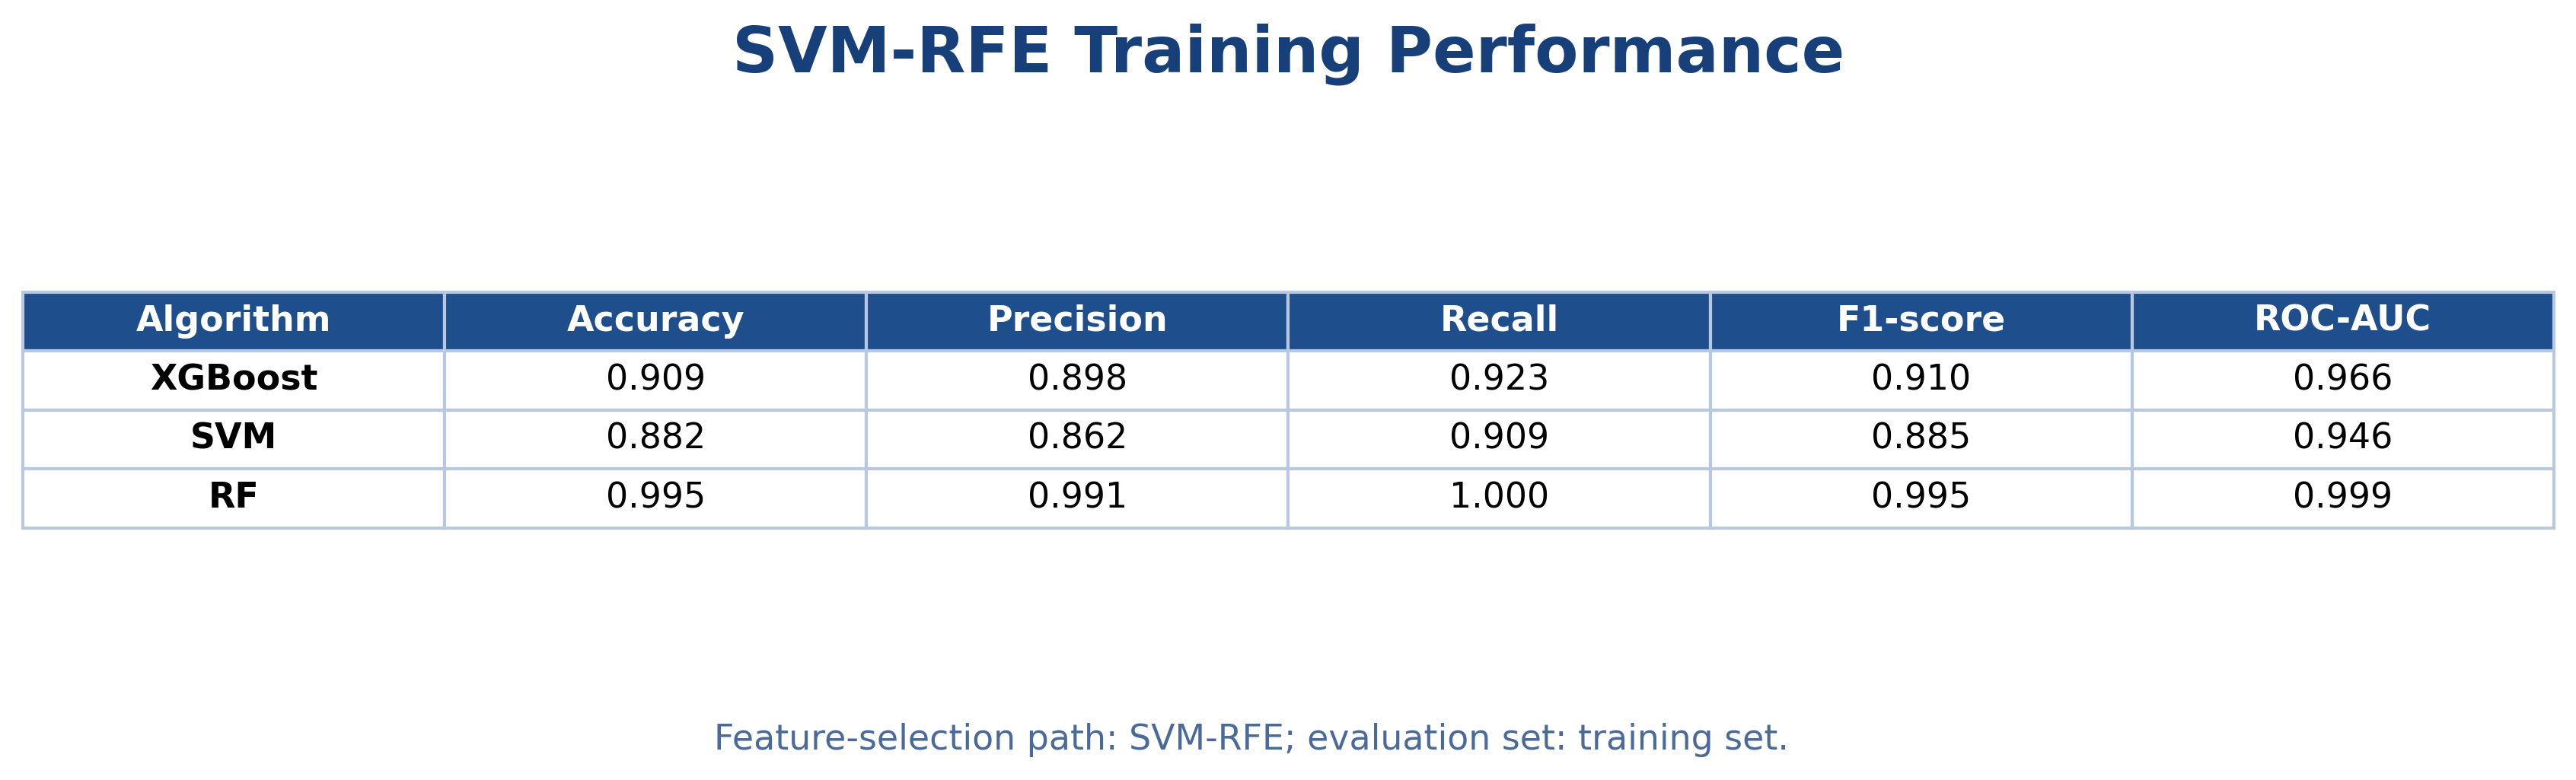

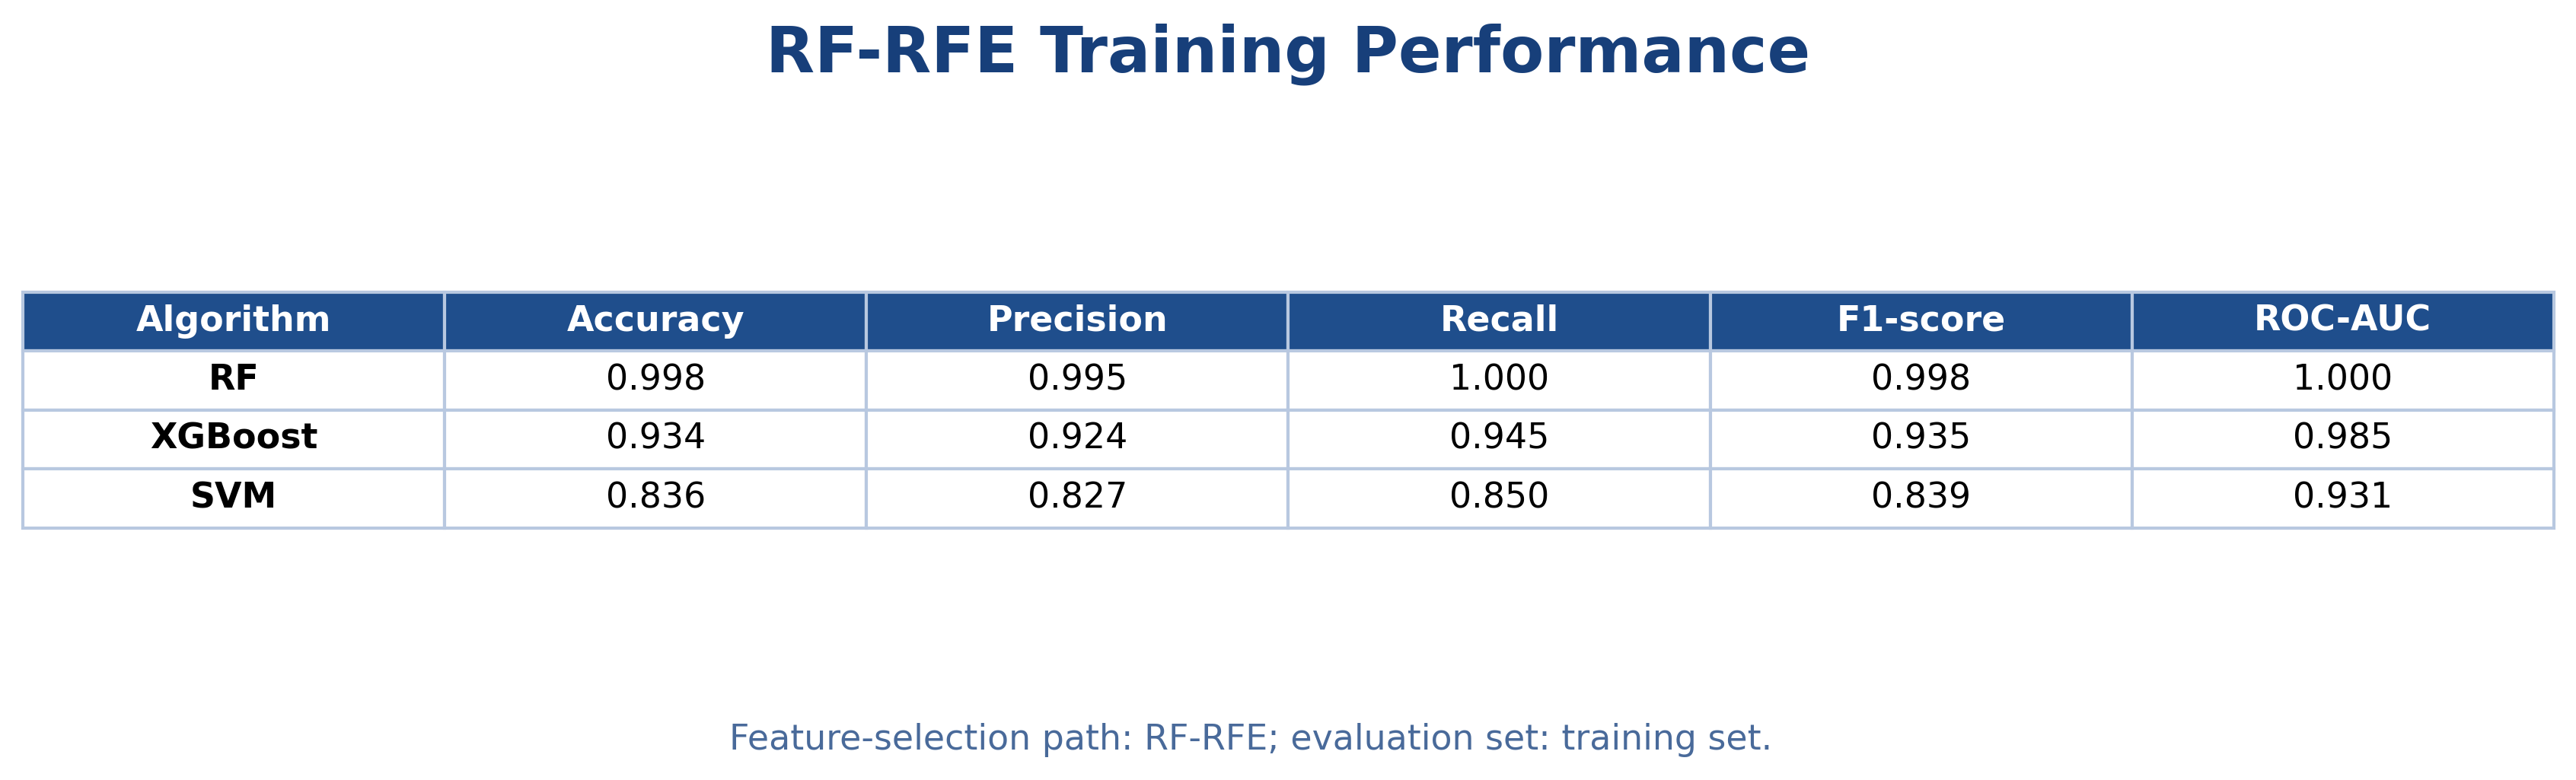

PosixPath('/content/outputs/feature_selection/q1_validation_extension/figures/04_rf_rfe_train_results.png')

In [26]:
# ============================================================
# Final RFE-path models and performance tables
# ============================================================

def get_final_rfe_models(grid_df, fitted_store, ranked_features):
    # Use the best feature count per model based on ROC-AUC/F1.
    final_models = {}
    final_features = {}
    for model_name in grid_df["Algorithm"].unique():
        sub = grid_df[grid_df["Algorithm"] == model_name]
        best = choose_best_rfe_model(sub)
        k = int(best["n_features"])
        model, features = fitted_store[(model_name, k)]
        final_models[model_name] = model
        final_features[model_name] = features
    return final_models, final_features

svm_rfe_models, svm_rfe_features_by_model = get_final_rfe_models(svm_rfe_grid_results, svm_rfe_fitted, ranked_svm_rfe_features)
rf_rfe_models, rf_rfe_features_by_model = get_final_rfe_models(rf_rfe_grid_results, rf_rfe_fitted, ranked_rf_rfe_features)

# Evaluate each model on its own selected feature subset.
def evaluate_rfe_path_models(models, feature_map, X_eval, y_eval):
    rows = []
    for name, model in models.items():
        rows.append(metric_row(name, model, X_eval[feature_map[name]], y_eval))
    return pd.DataFrame(rows)

svm_rfe_train_results = evaluate_rfe_path_models(svm_rfe_models, svm_rfe_features_by_model, X_train, y_train)
svm_rfe_test_results = evaluate_rfe_path_models(svm_rfe_models, svm_rfe_features_by_model, X_test, y_test)
rf_rfe_train_results = evaluate_rfe_path_models(rf_rfe_models, rf_rfe_features_by_model, X_train, y_train)
rf_rfe_test_results = evaluate_rfe_path_models(rf_rfe_models, rf_rfe_features_by_model, X_test, y_test)

for name, df_out in {
    "svm_rfe_train_results.csv": svm_rfe_train_results,
    "svm_rfe_test_results.csv": svm_rfe_test_results,
    "rf_rfe_train_results.csv": rf_rfe_train_results,
    "rf_rfe_test_results.csv": rf_rfe_test_results,
}.items():
    df_out.to_csv(VALIDATION_TABLE_DIR / name, index=False)

save_table_figure(
    svm_rfe_test_results,
    "SVM-RFE Test Performance",
    VALIDATION_FIGURE_DIR / "01_svm_rfe_test_results.png",
    footer="Feature-selection path: SVM-RFE; evaluation set: holdout test set.",
)
save_table_figure(
    rf_rfe_test_results,
    "RF-RFE Test Performance",
    VALIDATION_FIGURE_DIR / "02_rf_rfe_test_results.png",
    footer="Feature-selection path: RF-RFE; evaluation set: holdout test set.",
)
save_table_figure(
    svm_rfe_train_results,
    "SVM-RFE Training Performance",
    VALIDATION_FIGURE_DIR / "03_svm_rfe_train_results.png",
    footer="Feature-selection path: SVM-RFE; evaluation set: training set.",
)
save_table_figure(
    rf_rfe_train_results,
    "RF-RFE Training Performance",
    VALIDATION_FIGURE_DIR / "04_rf_rfe_train_results.png",
    footer="Feature-selection path: RF-RFE; evaluation set: training set.",
)

###9.6 SVM-RFE and RF-RFE feature-subset tables

The following figures show the selected feature subsets for the best SVM-RFE and RF-RFE paths. These tables are intended for supplementary material or a thesis appendix.

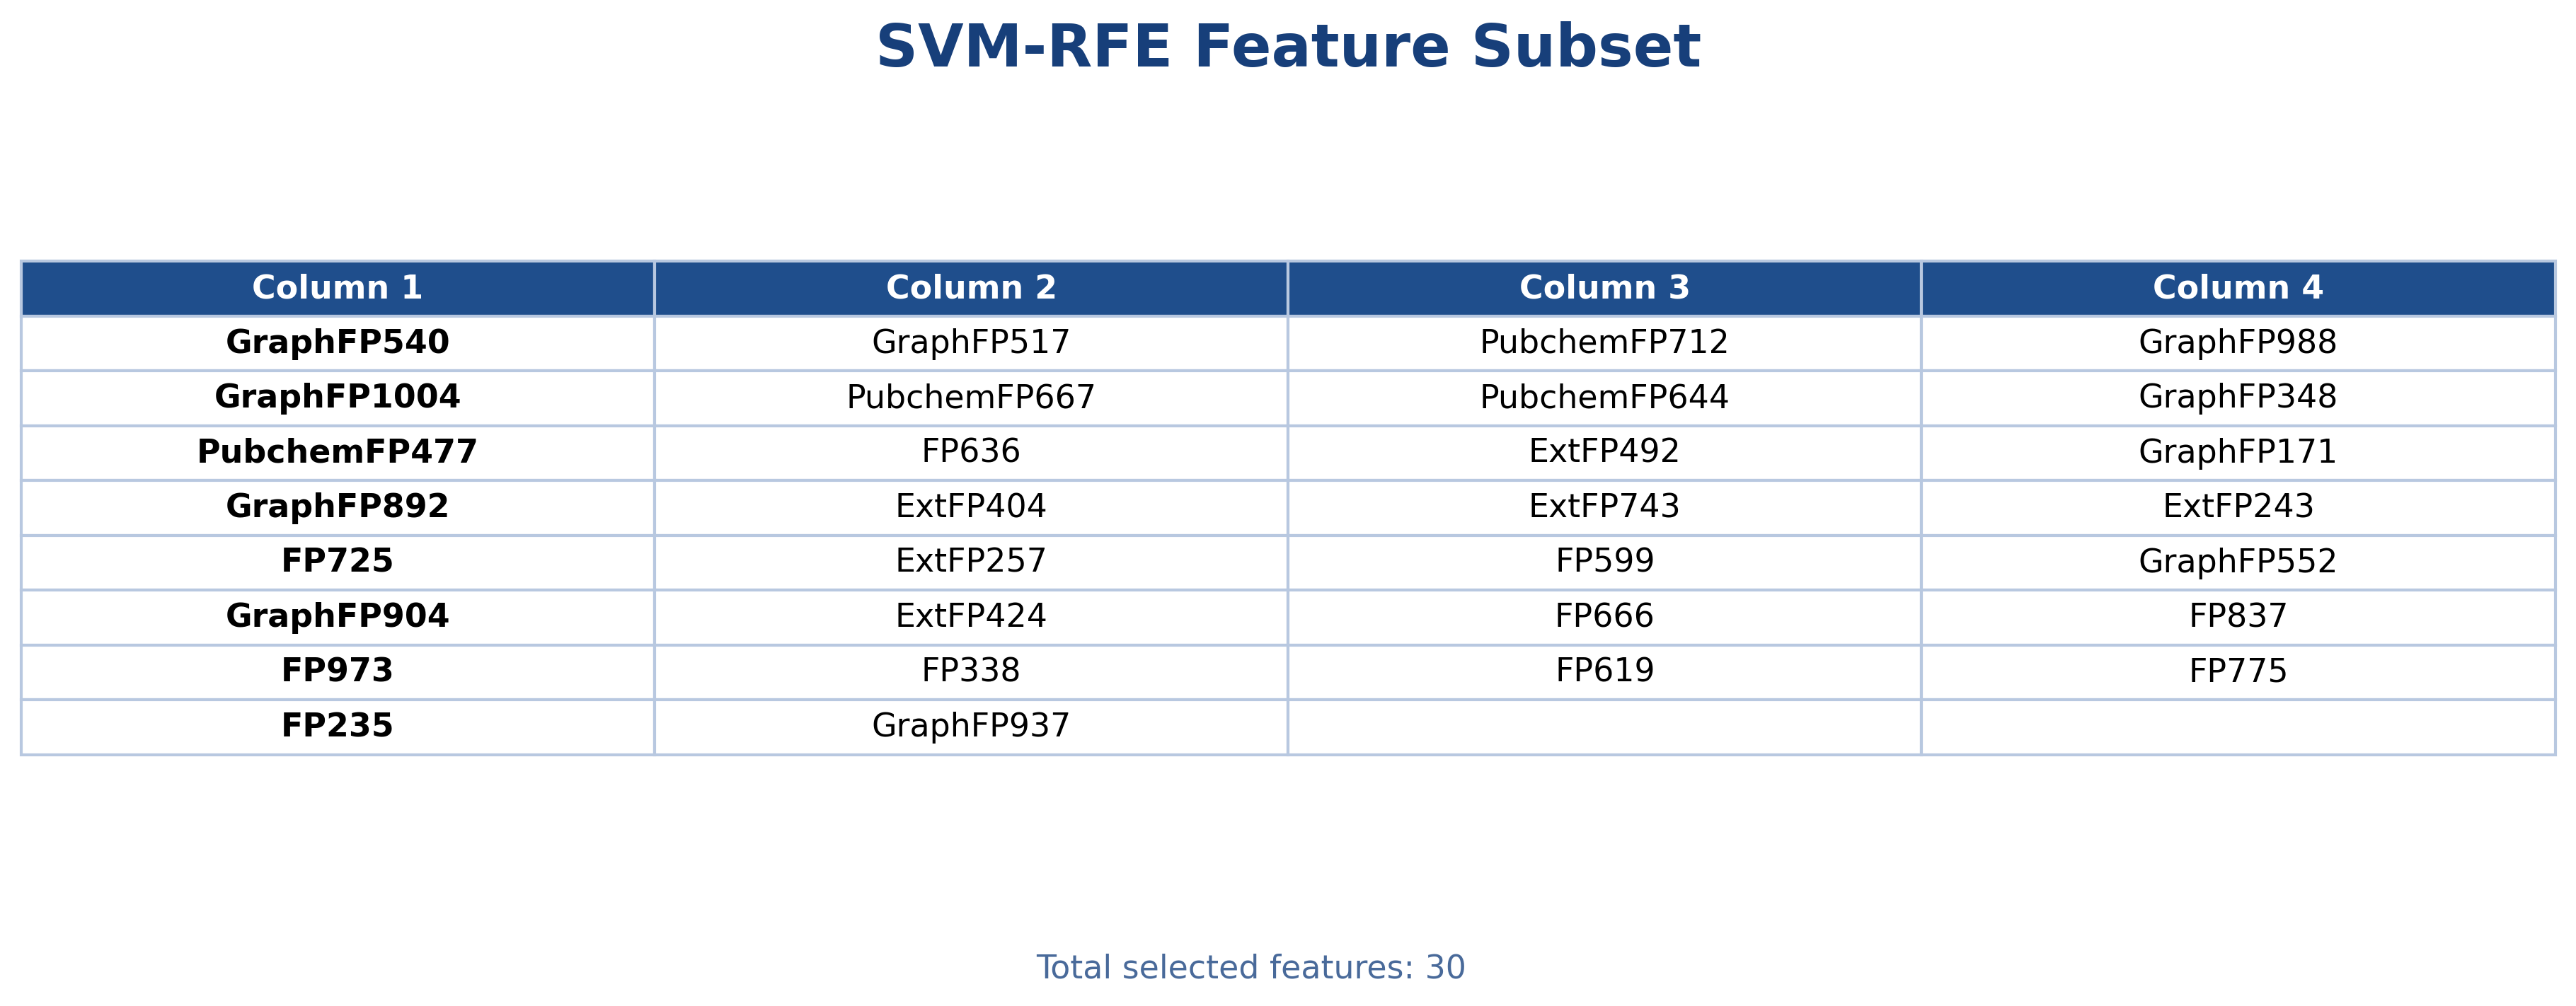

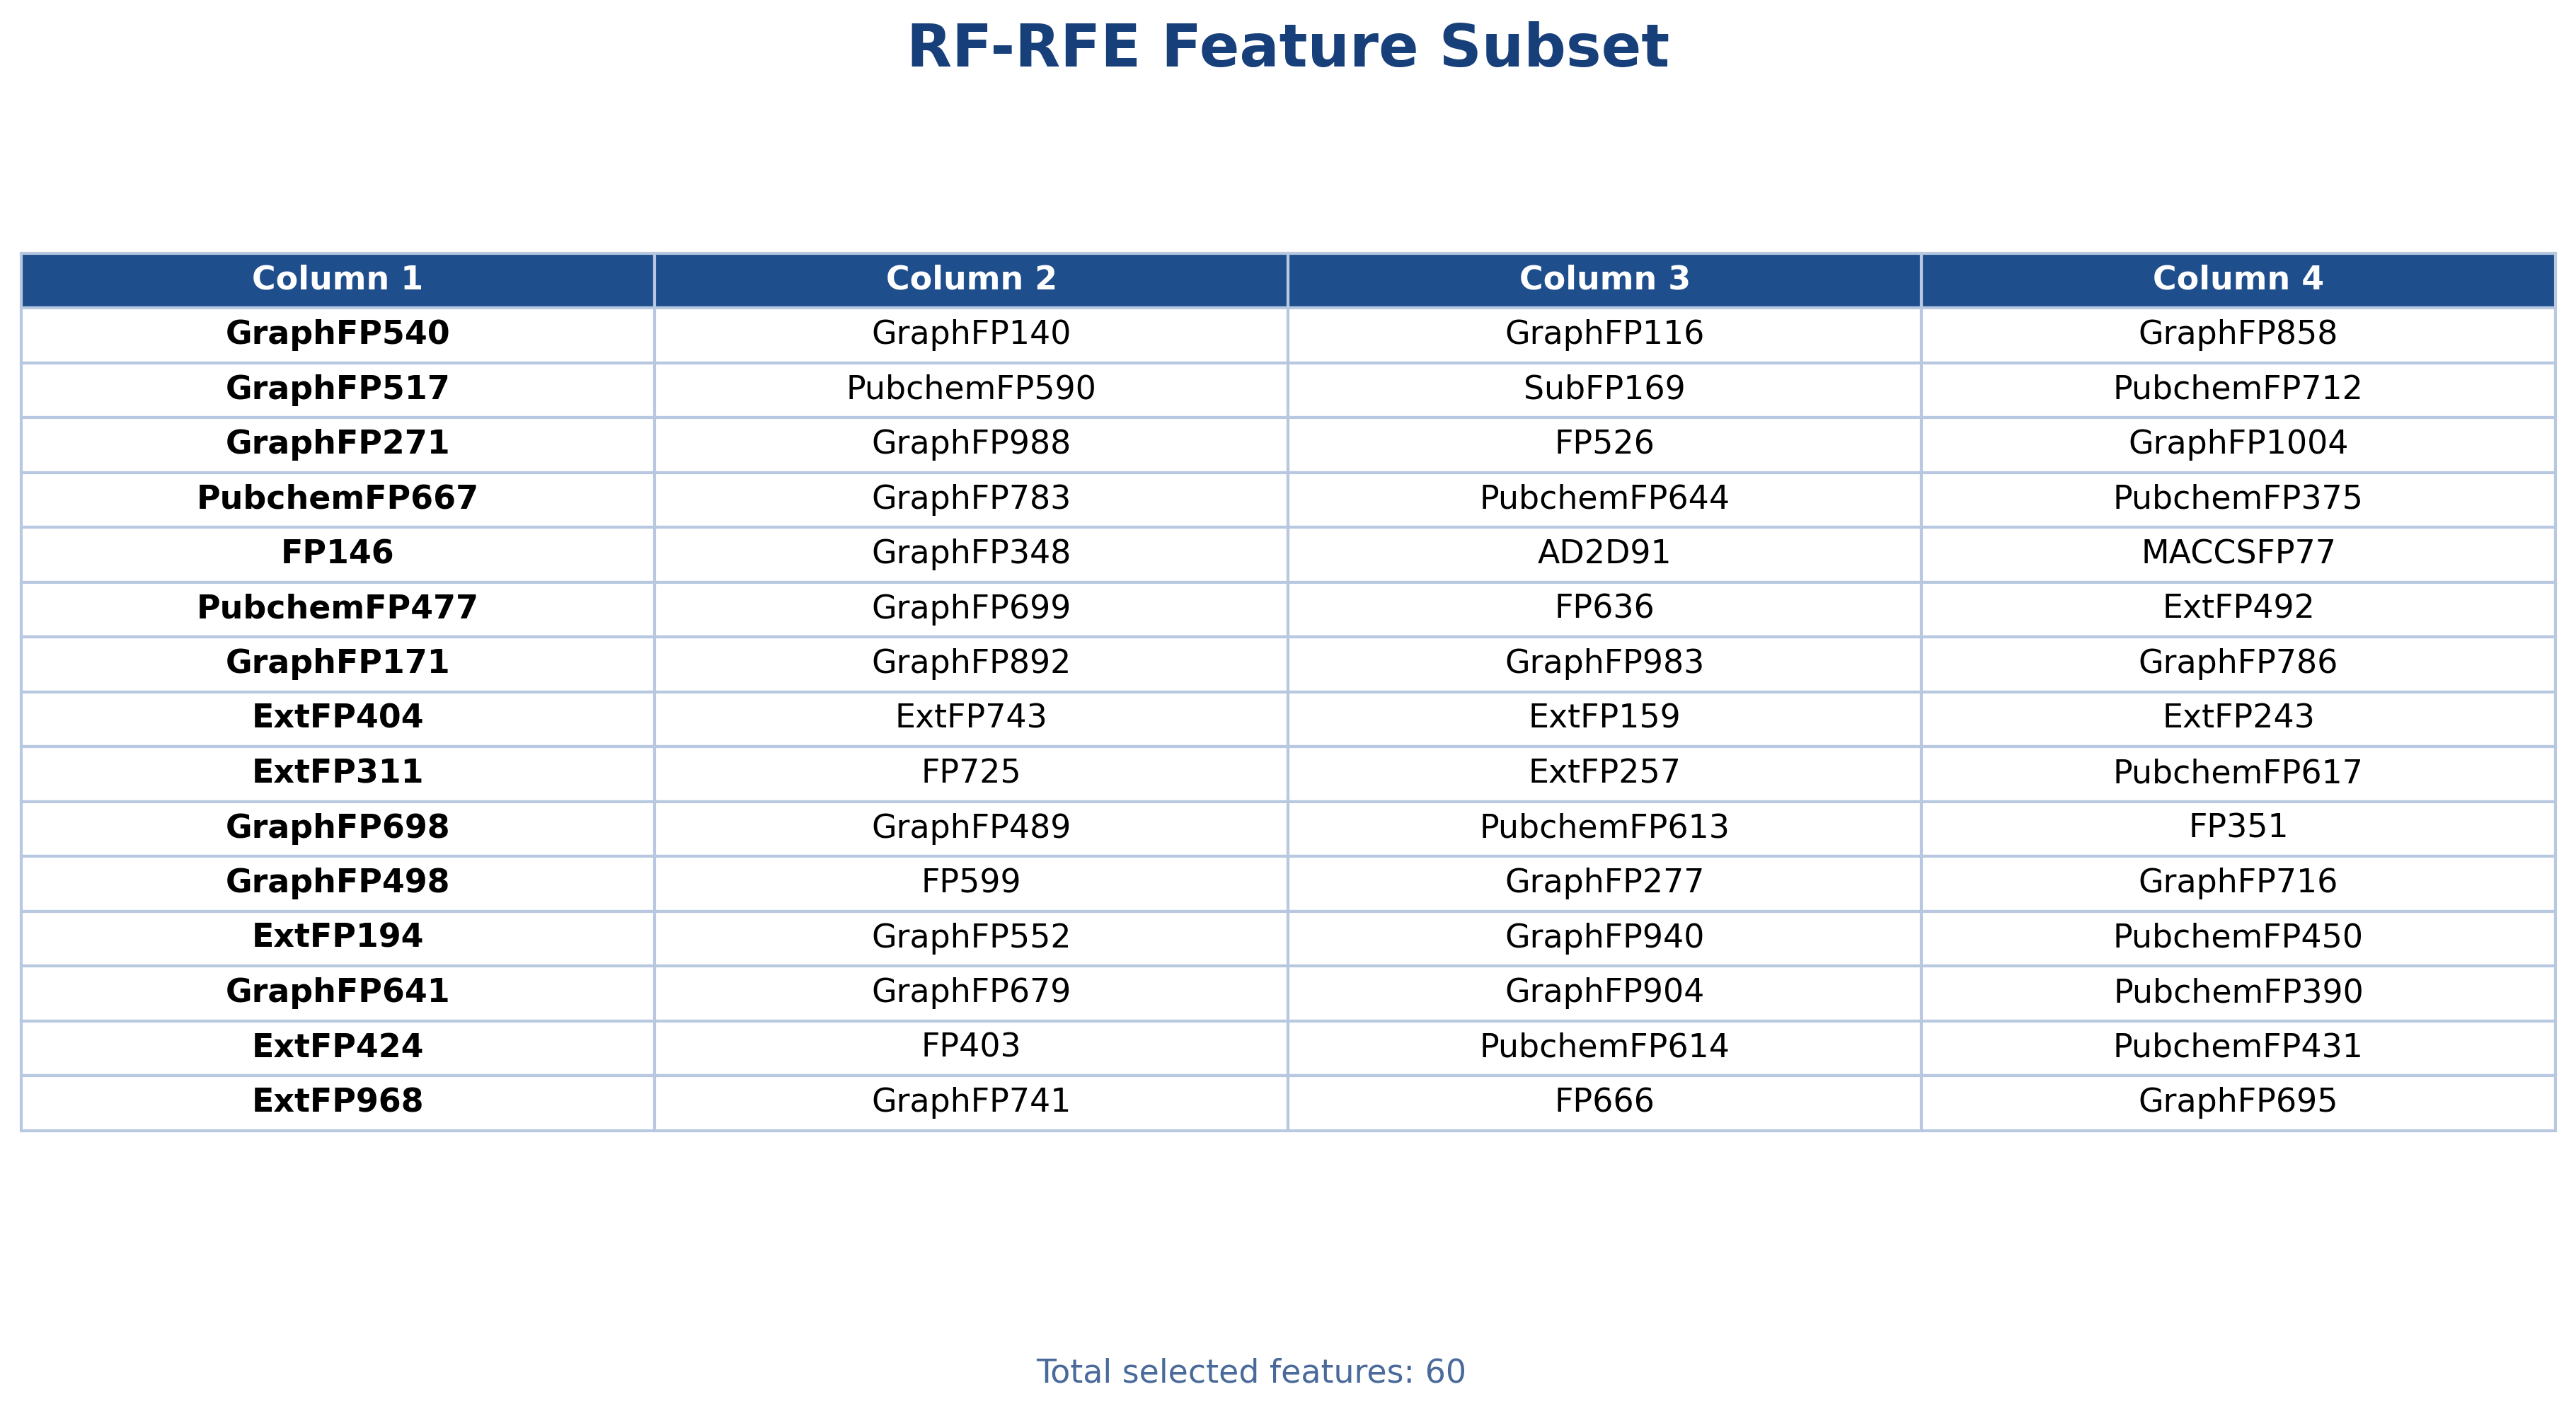

,Column 1,Column 2,Column 3,Column 4
0,GraphFP540,GraphFP140,GraphFP116,GraphFP858
1,GraphFP517,PubchemFP590,SubFP169,PubchemFP712
2,GraphFP271,GraphFP988,FP526,GraphFP1004
3,PubchemFP667,GraphFP783,PubchemFP644,PubchemFP375
4,FP146,GraphFP348,AD2D91,MACCSFP77
5,PubchemFP477,GraphFP699,FP636,ExtFP492
6,GraphFP171,GraphFP892,GraphFP983,GraphFP786
7,ExtFP404,ExtFP743,ExtFP159,ExtFP243
8,ExtFP311,FP725,ExtFP257,PubchemFP617
9,GraphFP698,GraphFP489,PubchemFP613,FP351


In [27]:
# ============================================================
# SVM-RFE and RF-RFE feature subset tables
# ============================================================

best_svm_rfe_model_name = svm_curve_best["Algorithm"]
best_rf_rfe_model_name = rf_curve_best["Algorithm"]

svm_rfe_best_features = svm_rfe_features_by_model[best_svm_rfe_model_name]
rf_rfe_best_features = rf_rfe_features_by_model[best_rf_rfe_model_name]

pd.DataFrame({"feature": svm_rfe_best_features}).to_csv(VALIDATION_TABLE_DIR / "svm_rfe_best_feature_subset.csv", index=False)
pd.DataFrame({"feature": rf_rfe_best_features}).to_csv(VALIDATION_TABLE_DIR / "rf_rfe_best_feature_subset.csv", index=False)

save_feature_subset_table(
    svm_rfe_best_features,
    "SVM-RFE Feature Subset",
    VALIDATION_FIGURE_DIR / "07_svm_rfe_feature_subset.png",
)
save_feature_subset_table(
    rf_rfe_best_features,
    "RF-RFE Feature Subset",
    VALIDATION_FIGURE_DIR / "08_rf_rfe_feature_subset.png",
)

###9.7 Heatmap of selected features and RF-RFE feature importance

This section adds the requested Heatmap of Selected Features and RF-RFE importance visualization. The heatmap checks whether the top selected features are redundant or provide complementary information.

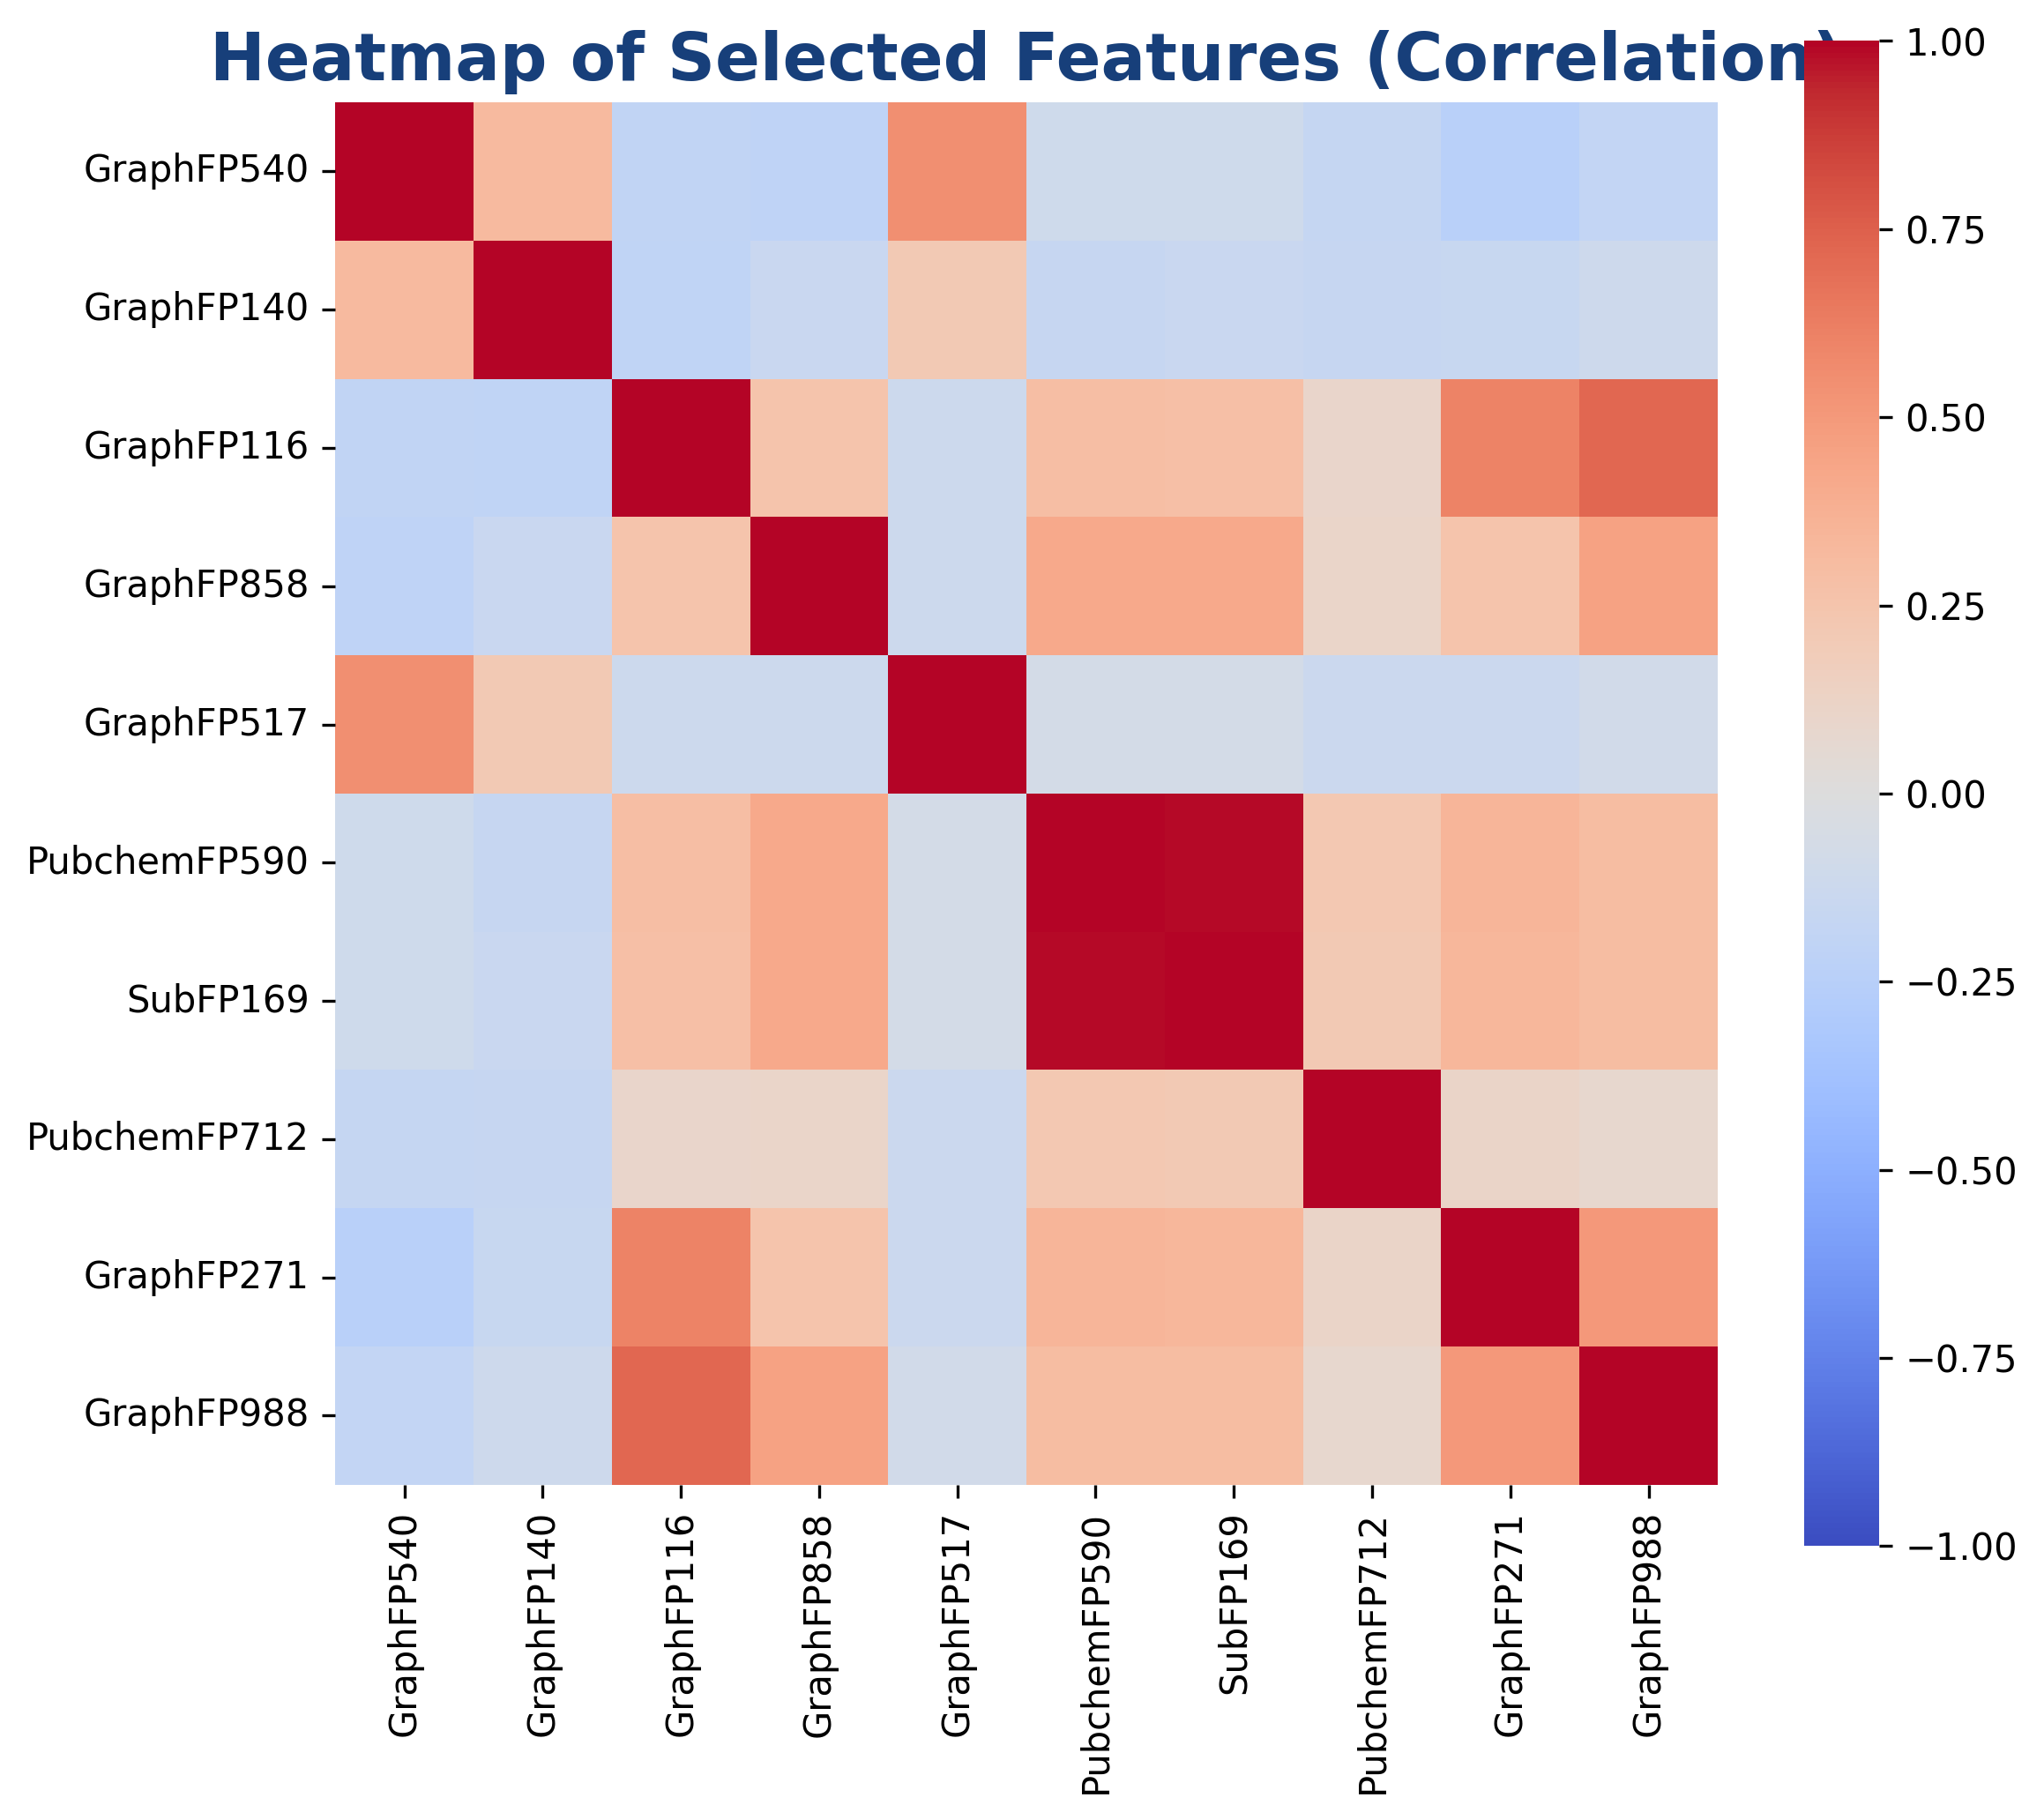

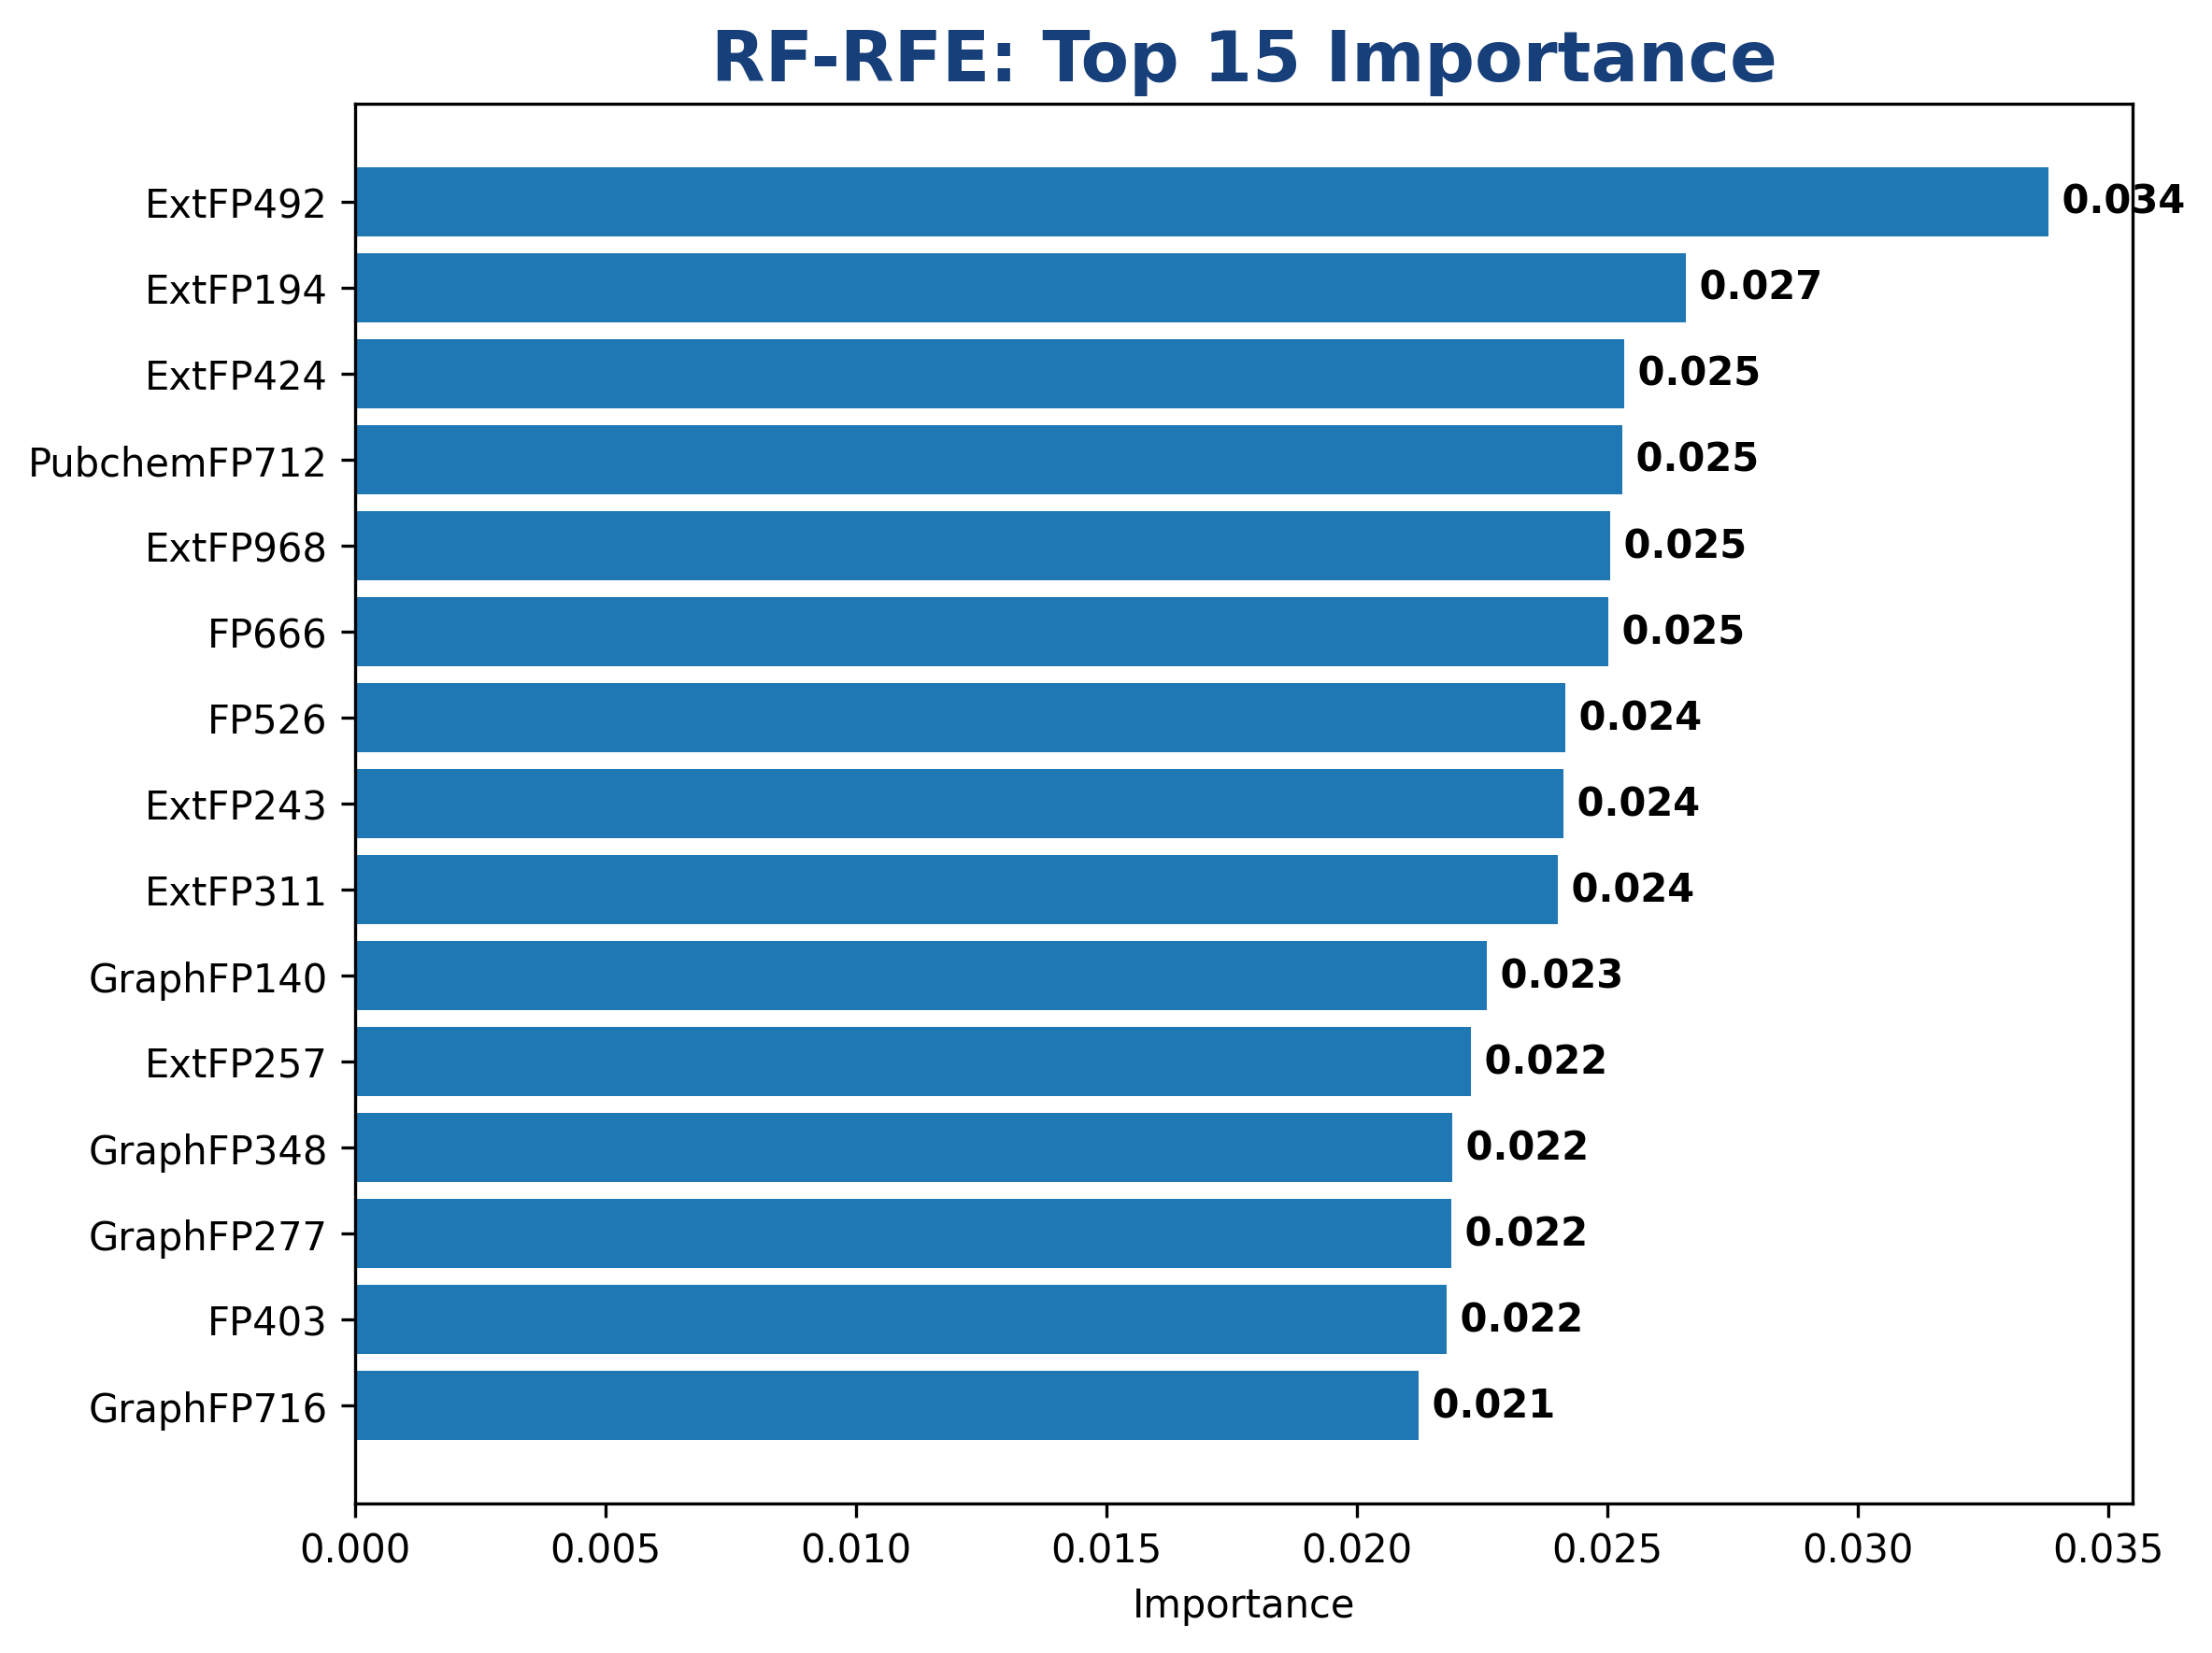

In [28]:
# ============================================================
# Heatmap of Selected Features and RF-RFE importance
# ============================================================

# Use top RF-RFE features for heatmap and importance panel.
heatmap_features = rf_rfe_best_features[:10]
heatmap_data = X_model_full[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
if SEABORN_AVAILABLE:
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        cbar=True,
        ax=ax,
    )
else:
    im = ax.imshow(heatmap_data, cmap="coolwarm", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(len(heatmap_features)), heatmap_features, rotation=45, ha="right")
    ax.set_yticks(range(len(heatmap_features)), heatmap_features)
ax.set_title("Heatmap of Selected Features (Correlation)", fontsize=18, fontweight="bold", color="#173f7a")
fig.tight_layout()
fig.savefig(VALIDATION_FIGURE_DIR / "03_selected_features_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# RF-RFE importance based on final RF model if available; otherwise use permutation importance for the best RF-RFE model.
if "RF" in rf_rfe_models:
    importance_model = rf_rfe_models["RF"]
    importance_features = rf_rfe_features_by_model["RF"]
else:
    importance_model = rf_rfe_models[best_rf_rfe_model_name]
    importance_features = rf_rfe_features_by_model[best_rf_rfe_model_name]

if hasattr(importance_model, "feature_importances_"):
    importances = importance_model.feature_importances_
else:
    perm = permutation_importance(
        importance_model,
        X_test[importance_features],
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importances = perm.importances_mean

importance_df = pd.DataFrame({
    "Feature": importance_features,
    "Importance": importances,
}).sort_values("Importance", ascending=False)
importance_df.to_csv(VALIDATION_TABLE_DIR / "rf_rfe_feature_importance.csv", index=False)

plot_imp = importance_df.head(15).sort_values("Importance")
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.barh(plot_imp["Feature"], plot_imp["Importance"])
for i, v in enumerate(plot_imp["Importance"]):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_title("RF-RFE: Top 15 Importance", fontsize=18, fontweight="bold", color="#173f7a")
fig.tight_layout()
fig.savefig(VALIDATION_FIGURE_DIR / "panel_02_rf_rfe_importance.png", bbox_inches="tight")
plt.show()

###9.8 Optimized modeling with Optuna or RandomizedSearchCV fallback

Optuna is used when installed. If Optuna is unavailable, the notebook automatically falls back to RandomizedSearchCV. This makes the hyperparameter choices objective instead of manually fixed.

,model,cv_roc_auc,params
0,SVM,0.816675,"{""model__C"": 4.5705630998014515, ""model__gamma..."
1,RandomForest,0.802633,"{""max_depth"": 11, ""max_features"": null, ""min_s..."


,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,RandomForest,0.755319,0.772727,0.723404,0.747253,0.815754
1,SVM,0.765957,0.903226,0.595745,0.717949,0.799457


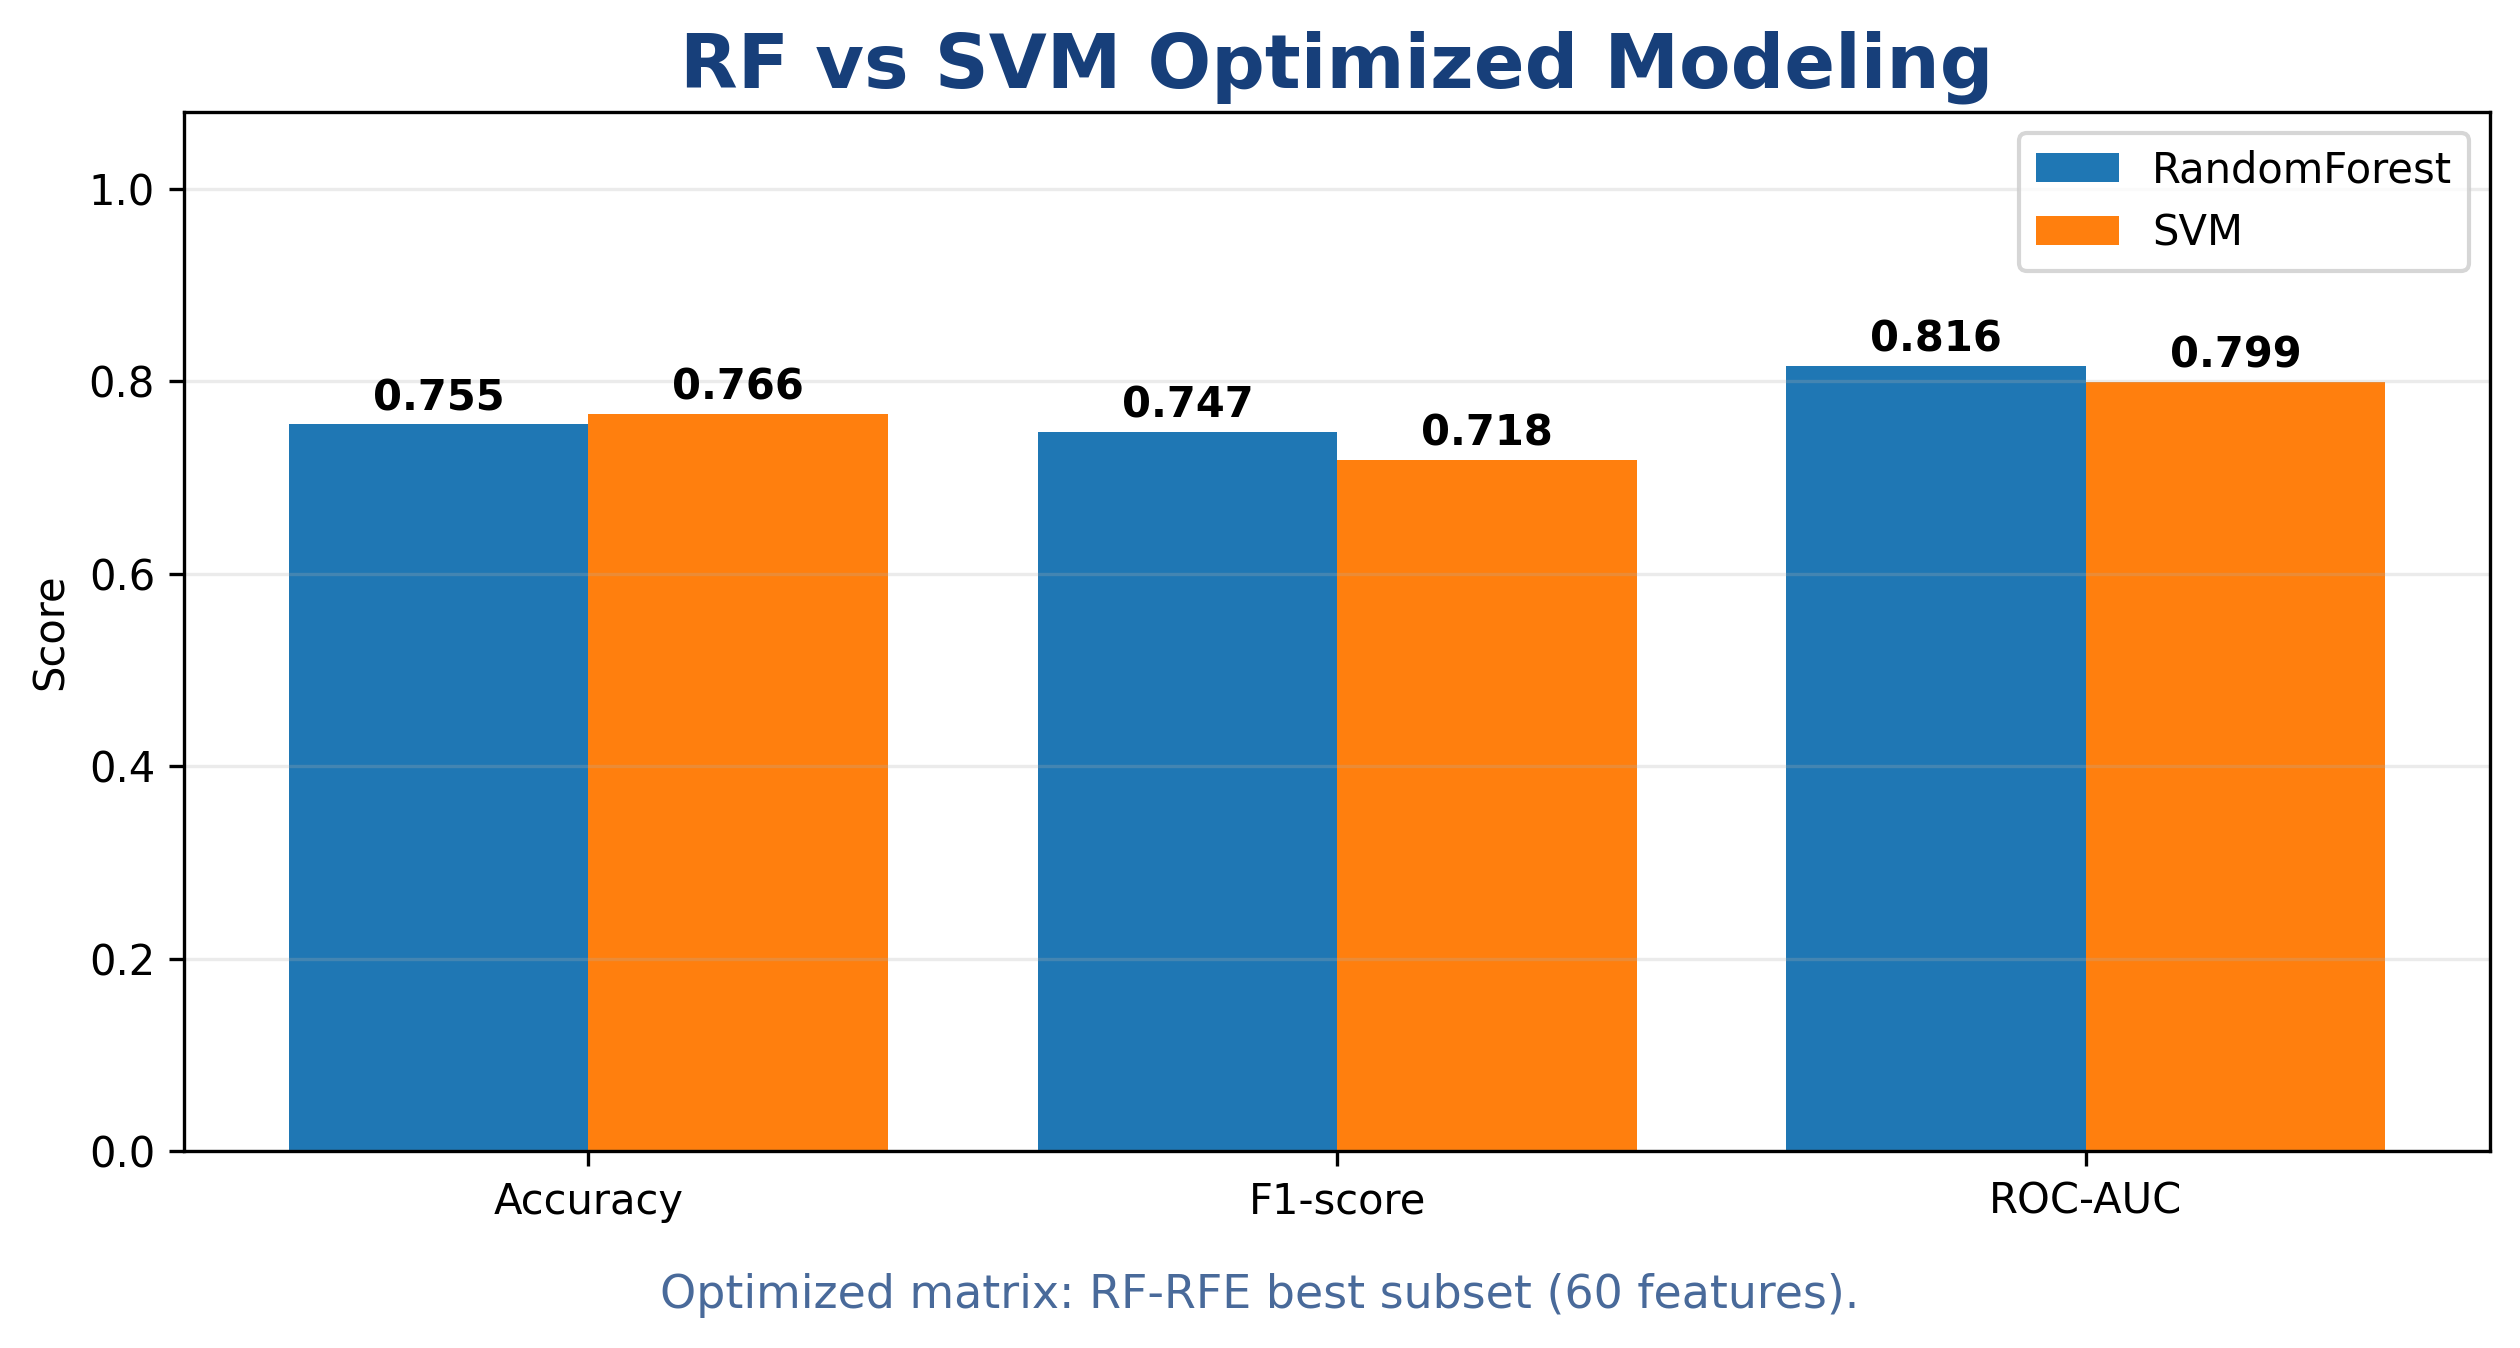

PosixPath('/content/outputs/feature_selection/q1_validation_extension/figures/06_rf_vs_svm_optimized_modeling.png')

In [29]:
# ============================================================
# Optuna / RandomizedSearchCV optimization
# ============================================================

optimized_features = rf_rfe_best_features
X_train_opt = X_train[optimized_features]
X_test_opt = X_test[optimized_features]
X_external_opt = X_external[optimized_features]

INNER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def optimize_svm(Xtr, ytr, n_trials=30):
    if OPTUNA_AVAILABLE:
        def objective(trial):
            C = trial.suggest_float("C", 1e-3, 100, log=True)
            gamma = trial.suggest_float("gamma", 1e-4, 10, log=True)
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVC(C=C, gamma=gamma, kernel="rbf", probability=True, random_state=RANDOM_STATE)),
            ])
            return cross_val_score(model, Xtr, ytr, cv=INNER_CV, scoring="roc_auc", n_jobs=-1).mean()
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        params = study.best_params
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(C=params["C"], gamma=params["gamma"], kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        ])
        model.fit(Xtr, ytr)
        return model, study.best_value, params

    search = RandomizedSearchCV(
        Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]),
        param_distributions={"model__C": loguniform(1e-3, 100), "model__gamma": loguniform(1e-4, 10)},
        n_iter=n_trials,
        scoring="roc_auc",
        cv=INNER_CV,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    search.fit(Xtr, ytr)
    return search.best_estimator_, search.best_score_, search.best_params_


def optimize_rf(Xtr, ytr, n_trials=30):
    if OPTUNA_AVAILABLE:
        def objective(trial):
            model = RandomForestClassifier(
                n_estimators=trial.suggest_int("n_estimators", 200, 800),
                max_depth=trial.suggest_int("max_depth", 3, 30),
                min_samples_split=trial.suggest_int("min_samples_split", 2, 12),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
                max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            return cross_val_score(model, Xtr, ytr, cv=INNER_CV, scoring="roc_auc", n_jobs=-1).mean()
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        params = study.best_params
        model = RandomForestClassifier(**params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
        model.fit(Xtr, ytr)
        return model, study.best_value, params

    search = RandomizedSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions={
            "n_estimators": randint(200, 800),
            "max_depth": randint(3, 30),
            "min_samples_split": randint(2, 12),
            "min_samples_leaf": randint(1, 8),
            "max_features": ["sqrt", "log2", None],
        },
        n_iter=n_trials,
        scoring="roc_auc",
        cv=INNER_CV,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    search.fit(Xtr, ytr)
    return search.best_estimator_, search.best_score_, search.best_params_

svm_optimized, svm_optimized_cv, svm_optimized_params = optimize_svm(X_train_opt, y_train, n_trials=30)
rf_optimized, rf_optimized_cv, rf_optimized_params = optimize_rf(X_train_opt, y_train, n_trials=30)

optimized_models = {
    "RandomForest": rf_optimized,
    "SVM": svm_optimized,
}

optimized_test_results = evaluate_models(optimized_models, X_test_opt, y_test)
optimized_train_results = evaluate_models(optimized_models, X_train_opt, y_train)
optimized_external_results = evaluate_models(optimized_models, X_external_opt, y_external)

optimized_test_results.to_csv(VALIDATION_TABLE_DIR / "optimized_test_results.csv", index=False)
optimized_train_results.to_csv(VALIDATION_TABLE_DIR / "optimized_train_results.csv", index=False)
optimized_external_results.to_csv(VALIDATION_TABLE_DIR / "optimized_external_results.csv", index=False)

optimization_params = pd.DataFrame([
    {"model": "SVM", "cv_roc_auc": svm_optimized_cv, "params": json.dumps(svm_optimized_params)},
    {"model": "RandomForest", "cv_roc_auc": rf_optimized_cv, "params": json.dumps(rf_optimized_params)},
])
optimization_params.to_csv(VALIDATION_TABLE_DIR / "optuna_or_randomizedsearch_best_params.csv", index=False)

display(optimization_params)
display(optimized_test_results)

save_metric_barplot(
    optimized_test_results,
    "RF vs SVM Optimized Modeling",
    VALIDATION_FIGURE_DIR / "06_rf_vs_svm_optimized_modeling.png",
    metrics=("Accuracy", "F1-score", "ROC-AUC"),
    footer=f"Optimized matrix: RF-RFE best subset ({len(optimized_features)} features).",
)

###9.9 Requested RF / SVM / RFE summary, confusion matrix, ROC curve, and probability scatter

This section selects the best final model based on holdout ROC-AUC and produces the requested summary, confusion matrix, ROC curve, and probability-vs-label visualization.

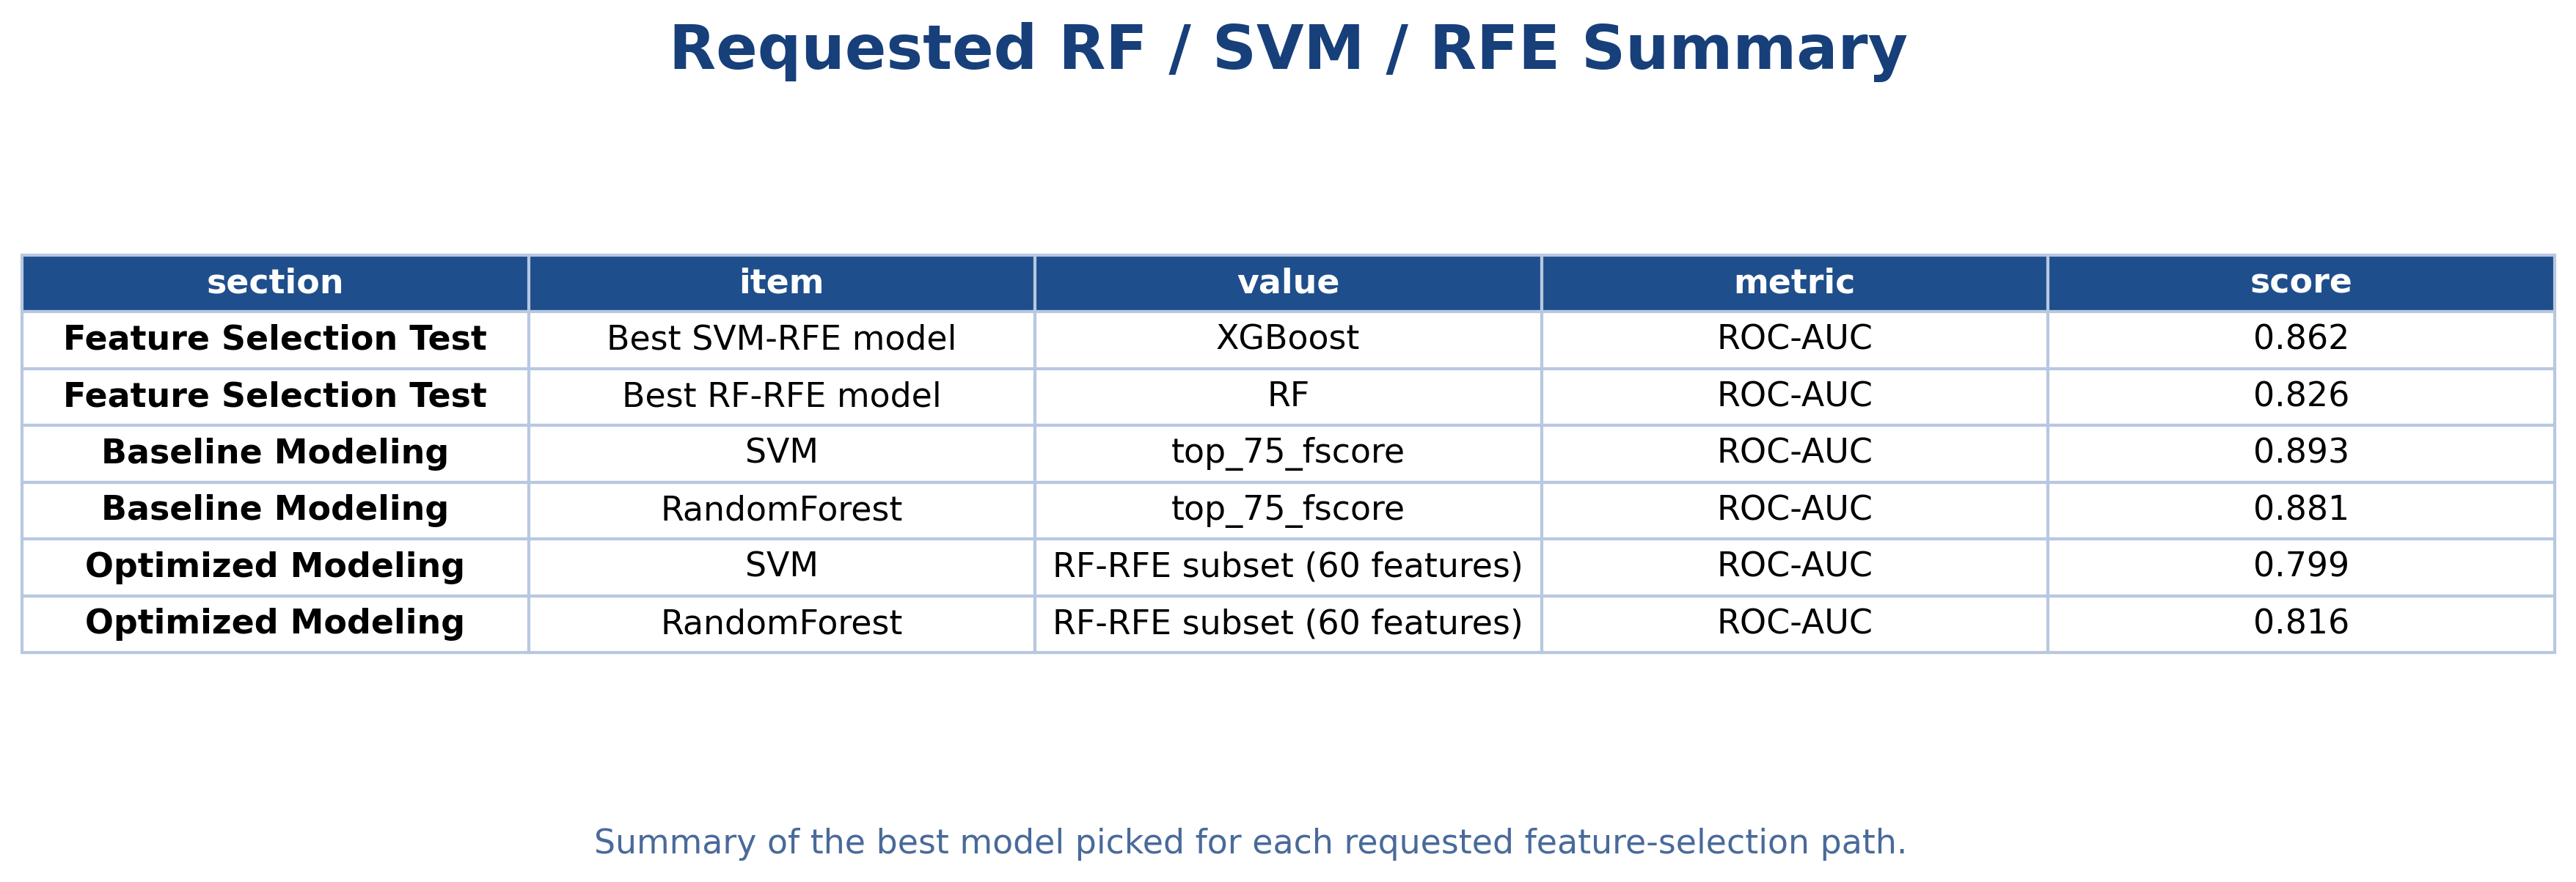

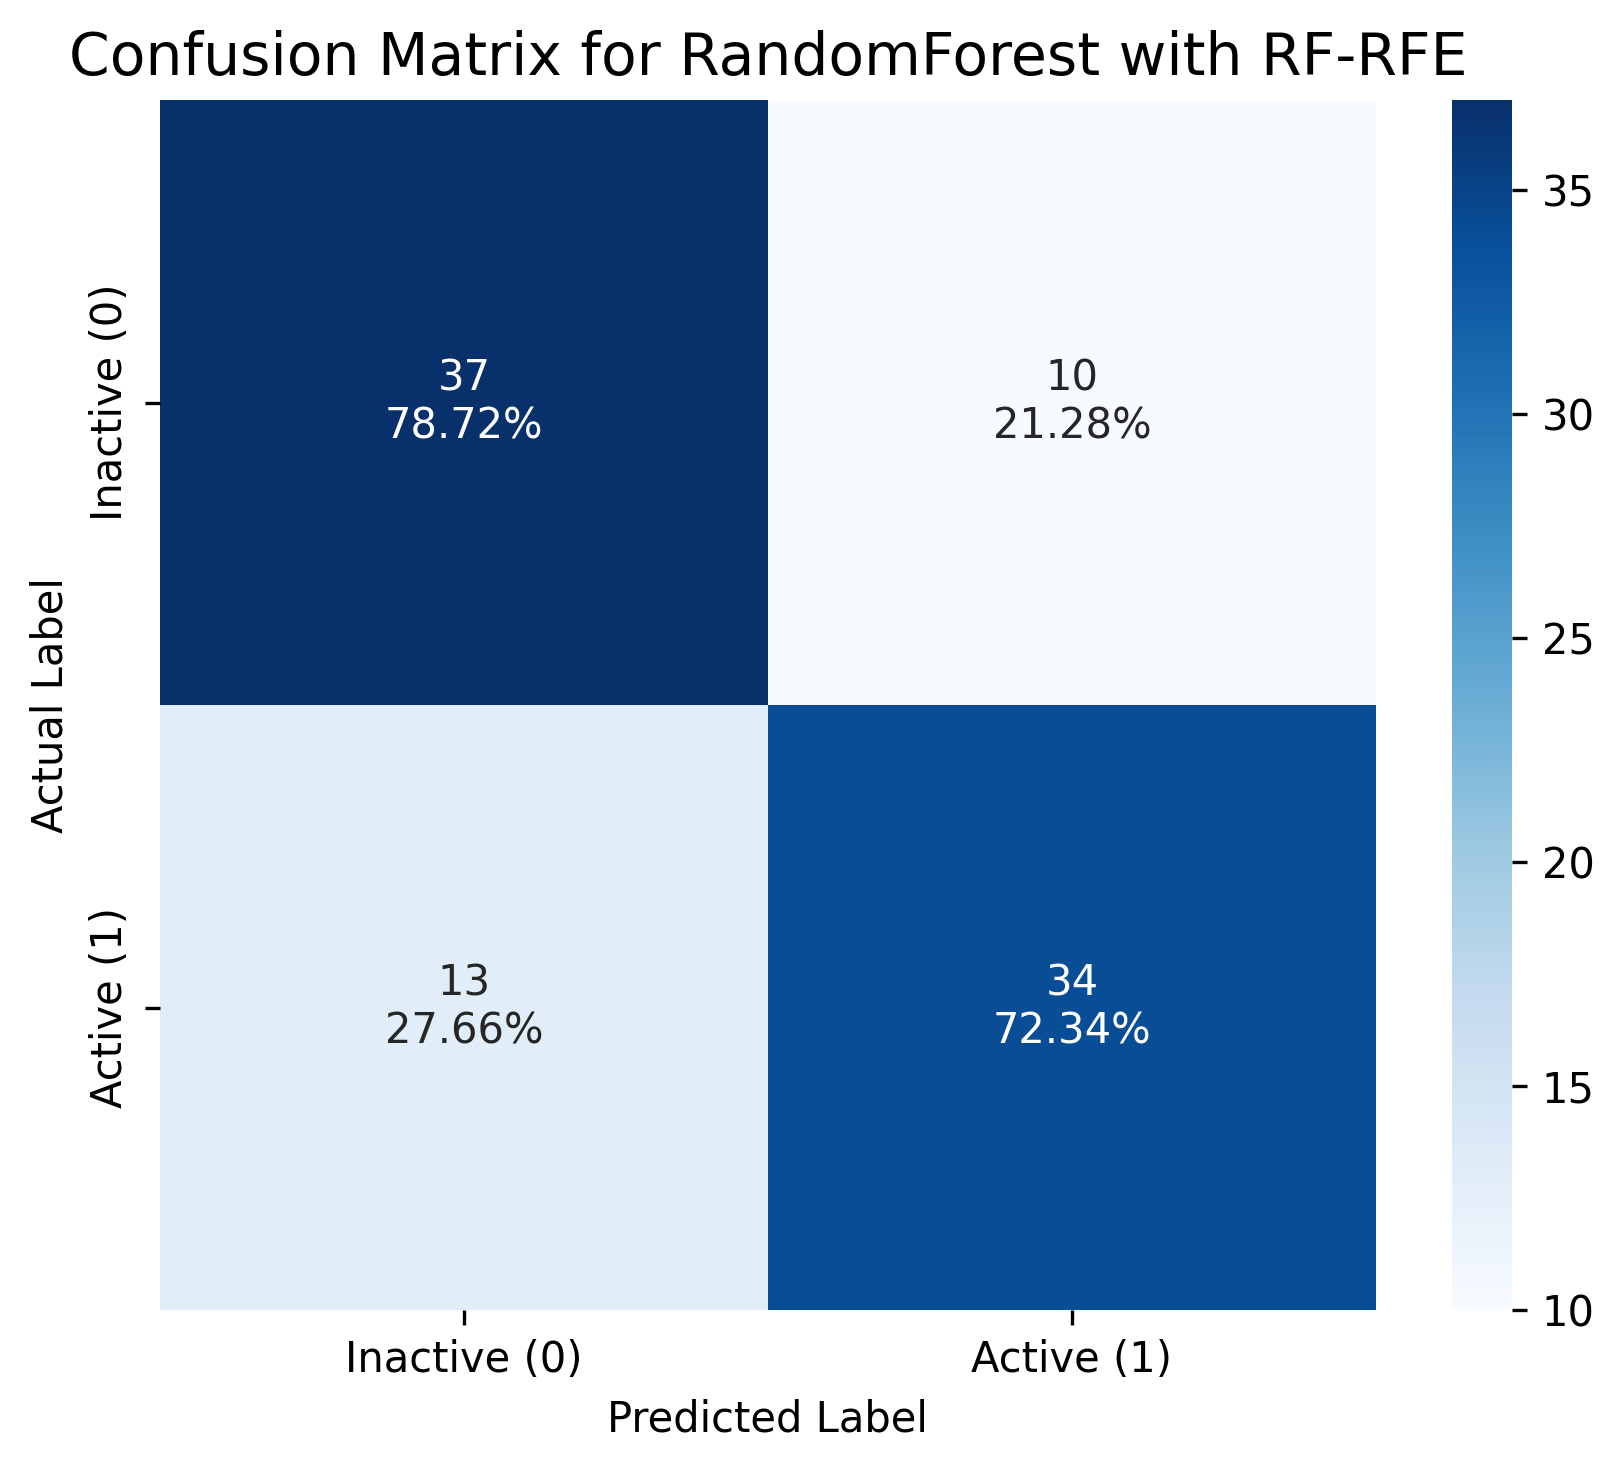

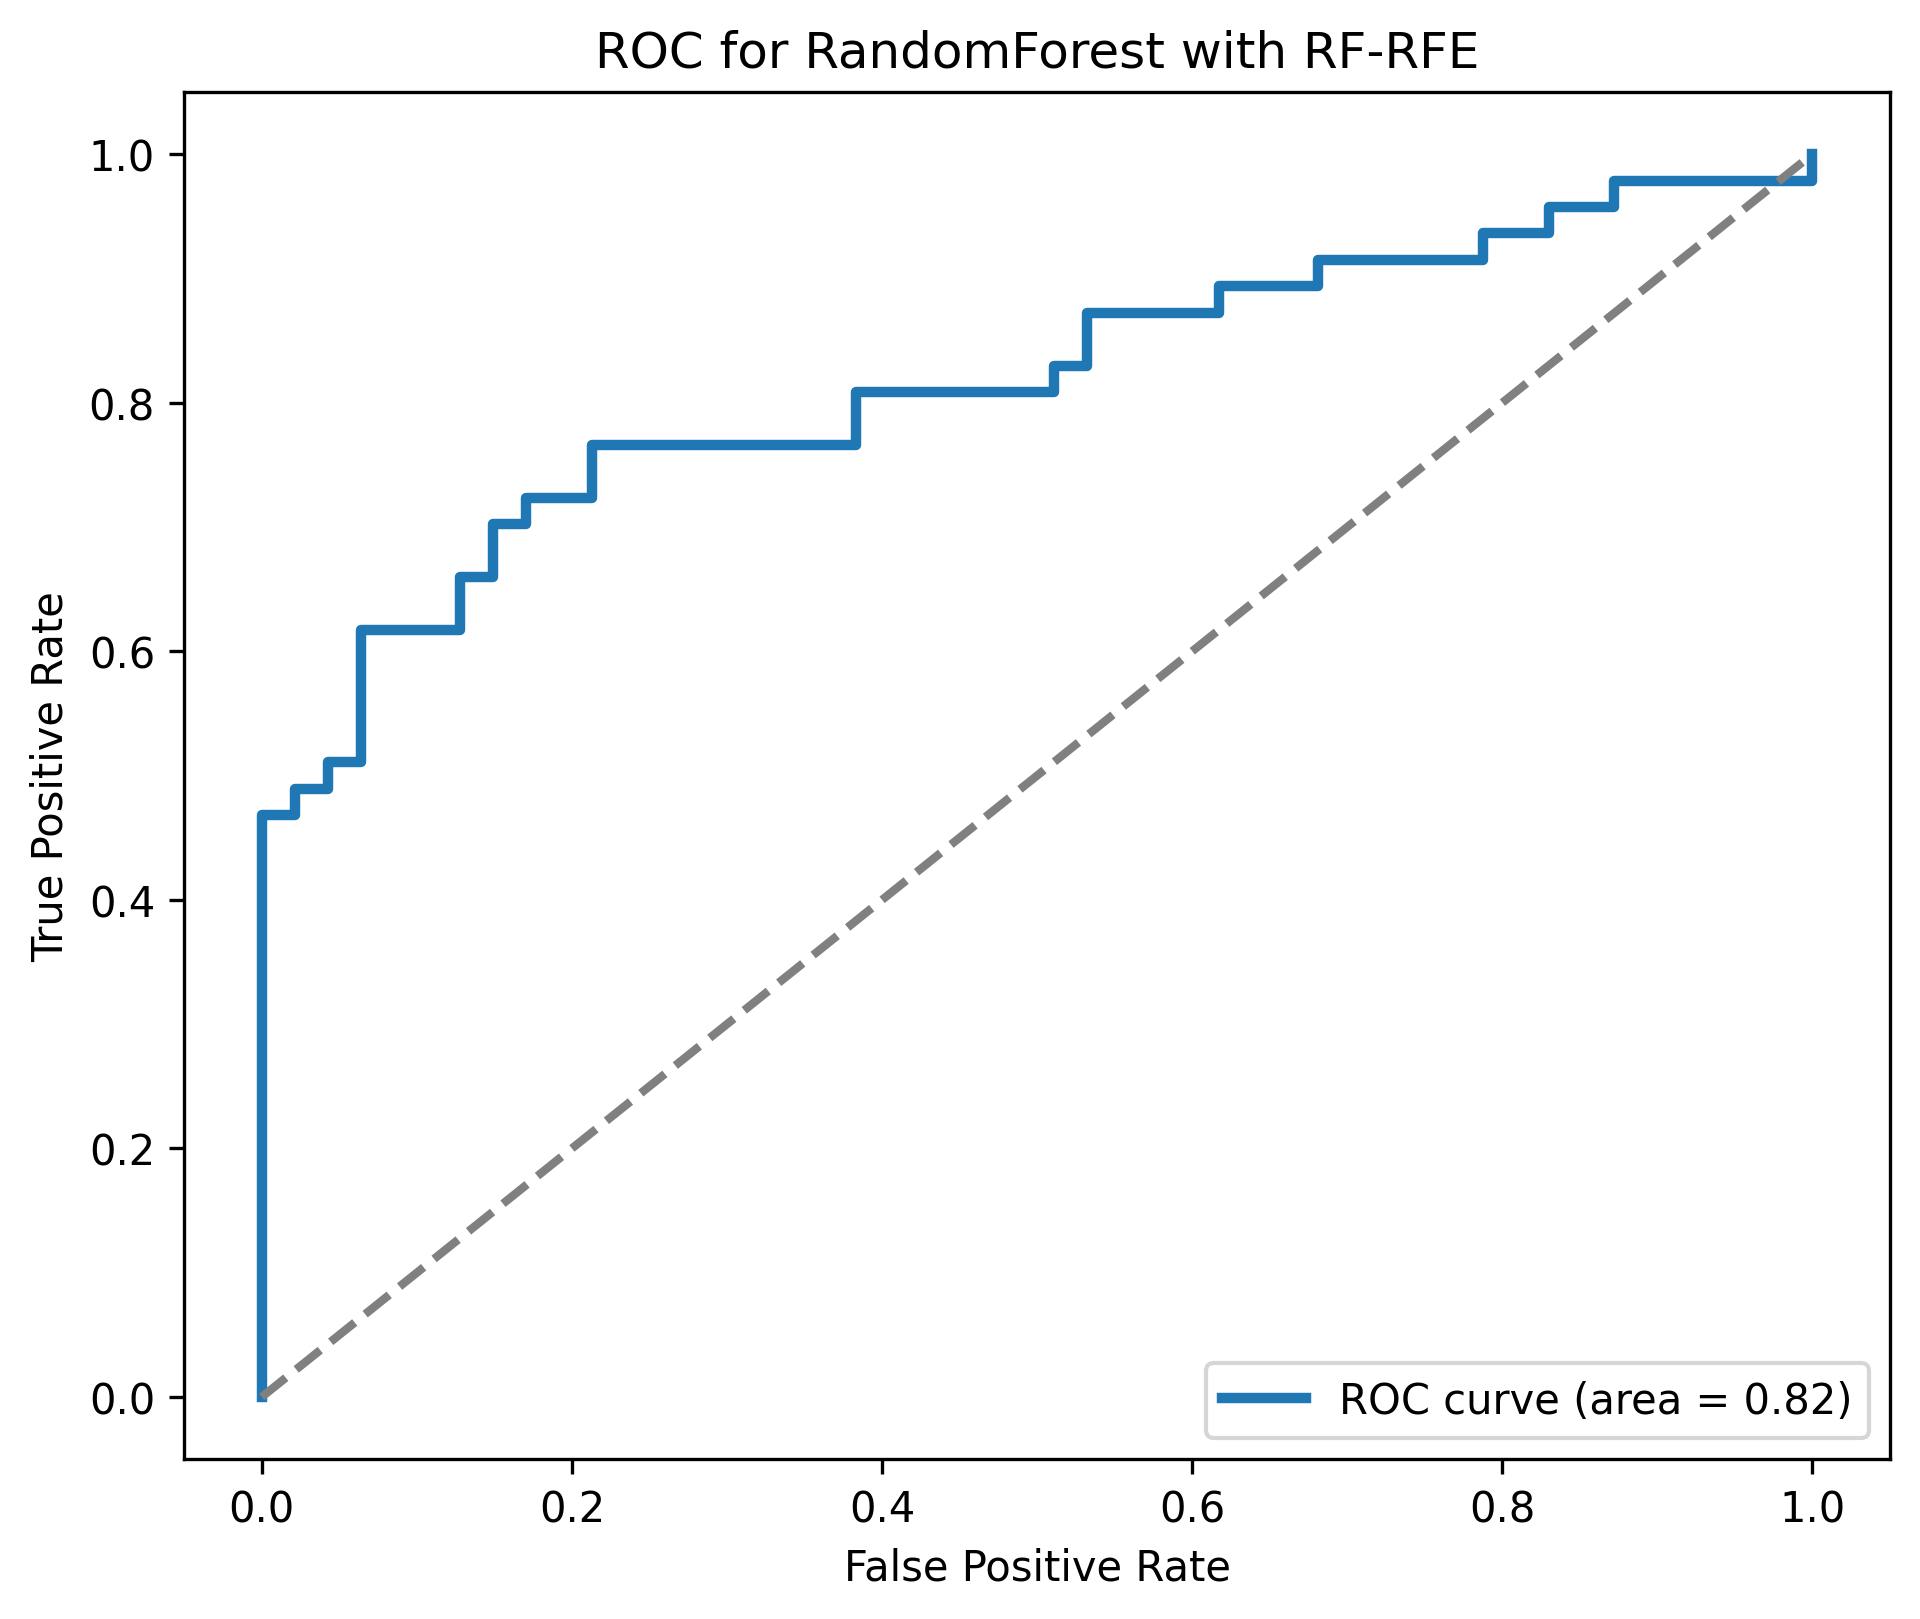

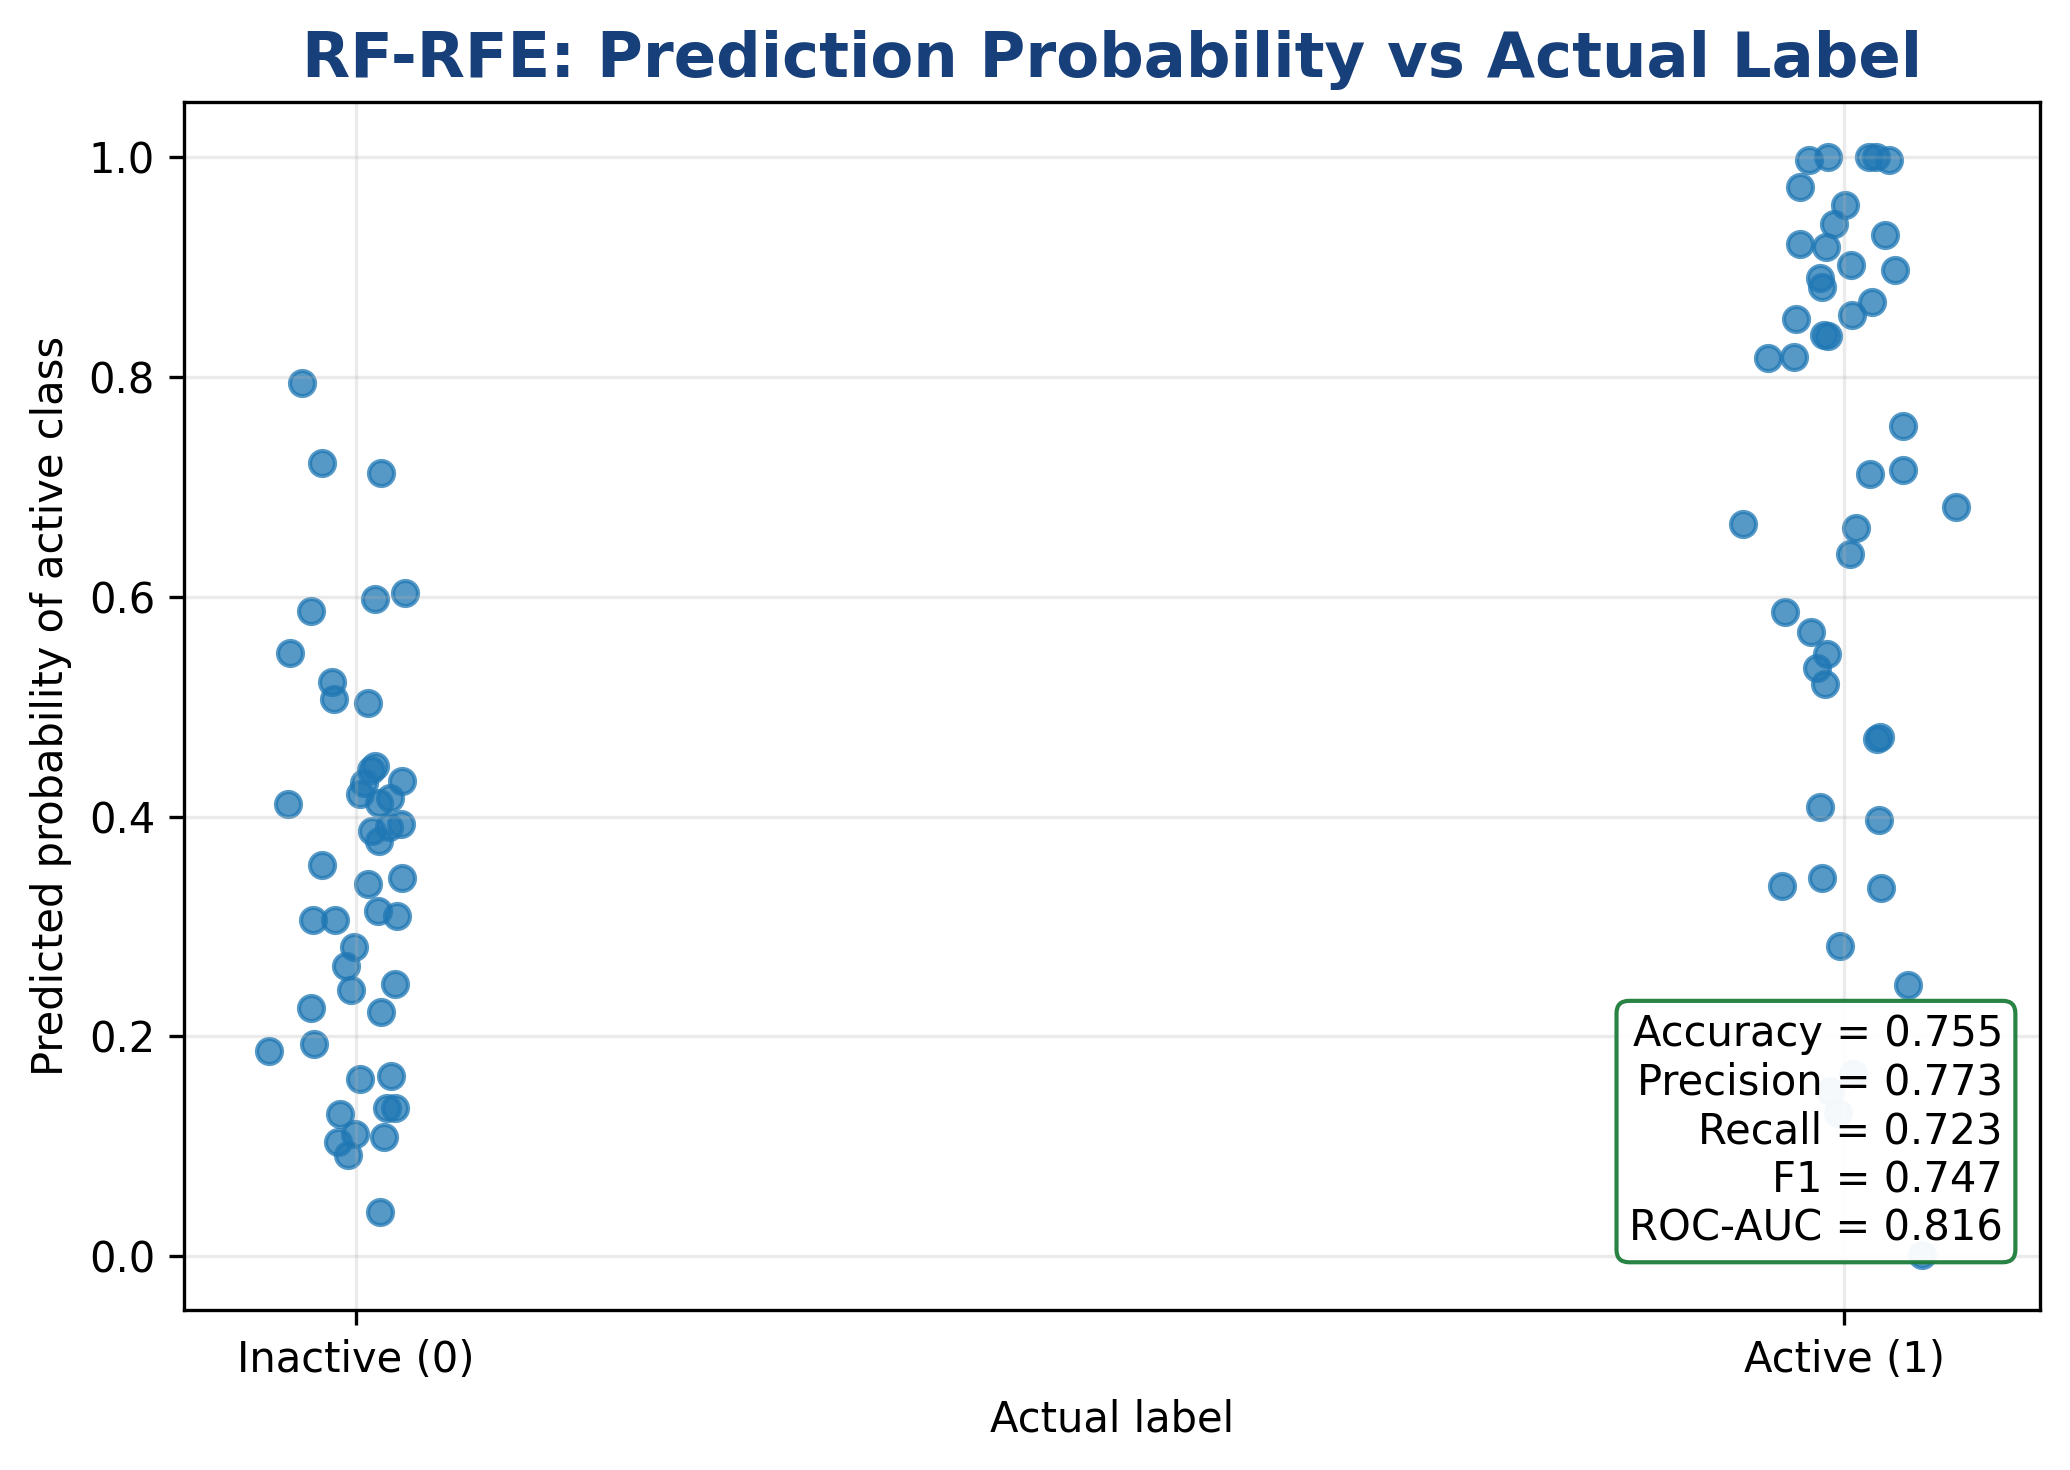

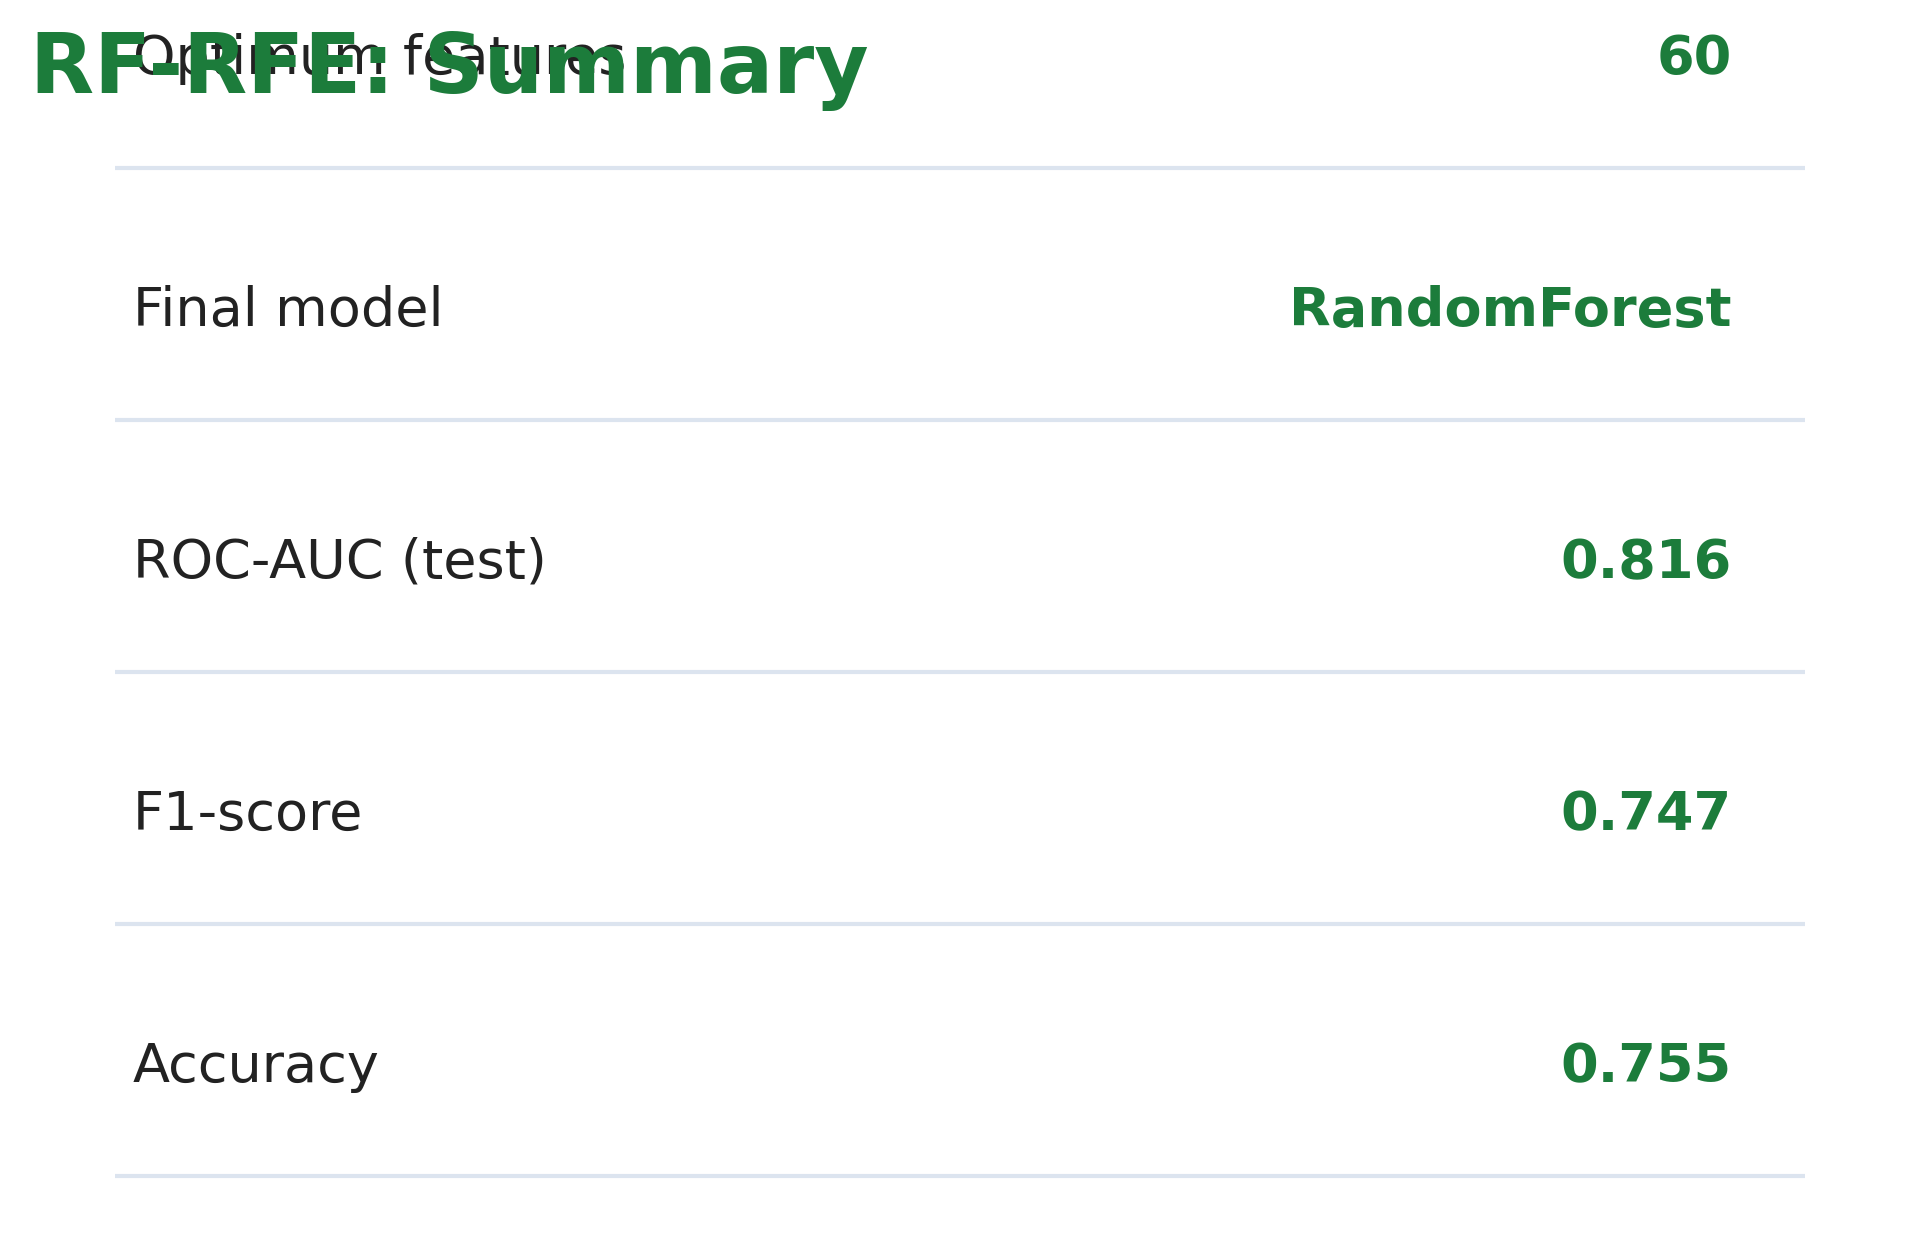

In [30]:
# ============================================================
# Requested summary + final model diagnostic plots
# ============================================================

# Choose final model by optimized test ROC-AUC.
best_optimized_row = optimized_test_results.sort_values(["ROC-AUC", "F1-score"], ascending=False).iloc[0]
final_model_name = best_optimized_row["Algorithm"]
final_model = optimized_models[final_model_name]
final_features = optimized_features

requested_summary = pd.DataFrame([
    {
        "section": "Feature Selection Test",
        "item": "Best SVM-RFE model",
        "value": best_svm_rfe_row["Algorithm"],
        "metric": "ROC-AUC",
        "score": best_svm_rfe_row["ROC-AUC"],
    },
    {
        "section": "Feature Selection Test",
        "item": "Best RF-RFE model",
        "value": best_rf_rfe_row["Algorithm"],
        "metric": "ROC-AUC",
        "score": best_rf_rfe_row["ROC-AUC"],
    },
    {
        "section": "Baseline Modeling",
        "item": "SVM",
        "value": f"top_{baseline_k}_fscore",
        "metric": "ROC-AUC",
        "score": baseline_feature_optimization_results.loc[(baseline_feature_optimization_results["Algorithm"] == "SVM") & (baseline_feature_optimization_results["n_features"] == baseline_k), "ROC-AUC"].iloc[0],
    },
    {
        "section": "Baseline Modeling",
        "item": "RandomForest",
        "value": f"top_{baseline_k}_fscore",
        "metric": "ROC-AUC",
        "score": baseline_feature_optimization_results.loc[(baseline_feature_optimization_results["Algorithm"] == "RandomForest") & (baseline_feature_optimization_results["n_features"] == baseline_k), "ROC-AUC"].iloc[0],
    },
    {
        "section": "Optimized Modeling",
        "item": "SVM",
        "value": f"RF-RFE subset ({len(final_features)} features)",
        "metric": "ROC-AUC",
        "score": optimized_test_results.loc[optimized_test_results["Algorithm"] == "SVM", "ROC-AUC"].iloc[0],
    },
    {
        "section": "Optimized Modeling",
        "item": "RandomForest",
        "value": f"RF-RFE subset ({len(final_features)} features)",
        "metric": "ROC-AUC",
        "score": optimized_test_results.loc[optimized_test_results["Algorithm"] == "RandomForest", "ROC-AUC"].iloc[0],
    },
])
requested_summary.to_csv(VALIDATION_TABLE_DIR / "11_requested_rf_svm_rfe_summary.csv", index=False)

save_table_figure(
    requested_summary,
    "Requested RF / SVM / RFE Summary",
    VALIDATION_FIGURE_DIR / "11_rf_svm_rfe_summary_table.png",
    footer="Summary of the best model picked for each requested feature-selection path.",
    figsize=(13.5, 3.9),
)

cm_final = save_confusion_matrix_with_percent(
    final_model,
    X_test[final_features],
    y_test,
    f"Confusion Matrix for {final_model_name} with RF-RFE",
    VALIDATION_FIGURE_DIR / "09_best_rfe_confusion_matrix.png",
)
auc_final = save_roc_curve(
    final_model,
    X_test[final_features],
    y_test,
    f"ROC for {final_model_name} with RF-RFE",
    VALIDATION_FIGURE_DIR / "10_best_rfe_roc_curve.png",
)
final_probability_metrics = save_probability_scatter(
    final_model,
    X_test[final_features],
    y_test,
    "RF-RFE: Prediction Probability vs Actual Label",
    VALIDATION_FIGURE_DIR / "panel_03_rf_rfe_probability_scatter.png",
)

# Compact final summary panel.
final_summary_panel = pd.DataFrame({
    "Metric": ["Optimum features", "Final model", "ROC-AUC (test)", "F1-score", "Accuracy"],
    "Value": [len(final_features), final_model_name, best_optimized_row["ROC-AUC"], best_optimized_row["F1-score"], best_optimized_row["Accuracy"]],
})
final_summary_panel.to_csv(VALIDATION_TABLE_DIR / "panel_04_rf_rfe_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=300)
ax.axis("off")
ax.set_title("RF-RFE: Summary", fontsize=20, fontweight="bold", color="#1c7c3b", loc="left")
for i, row in final_summary_panel.iterrows():
    y_pos = 0.78 - i * 0.16
    ax.text(0.05, y_pos, str(row["Metric"]), fontsize=13, color="#222222")
    val = row["Value"]
    if isinstance(val, float):
        val = f"{val:.3f}"
    ax.text(0.92, y_pos, str(val), fontsize=13, fontweight="bold", color="#1c7c3b", ha="right")
    ax.hlines(y_pos - 0.06, 0.04, 0.96, color="#dce4ef", linewidth=1)
fig.savefig(VALIDATION_FIGURE_DIR / "panel_04_rf_rfe_summary.png", bbox_inches="tight")
plt.show()

###9.10 Nested cross-validation

Nested CV estimates model generalization while accounting for hyperparameter selection inside the resampling loop. This is more rigorous than reporting a single holdout score only.

,model,mean,std,min,max
0,RandomForest,0.827609,0.037022,0.782187,0.866871
1,SVM,0.666589,0.156874,0.500000,0.840502


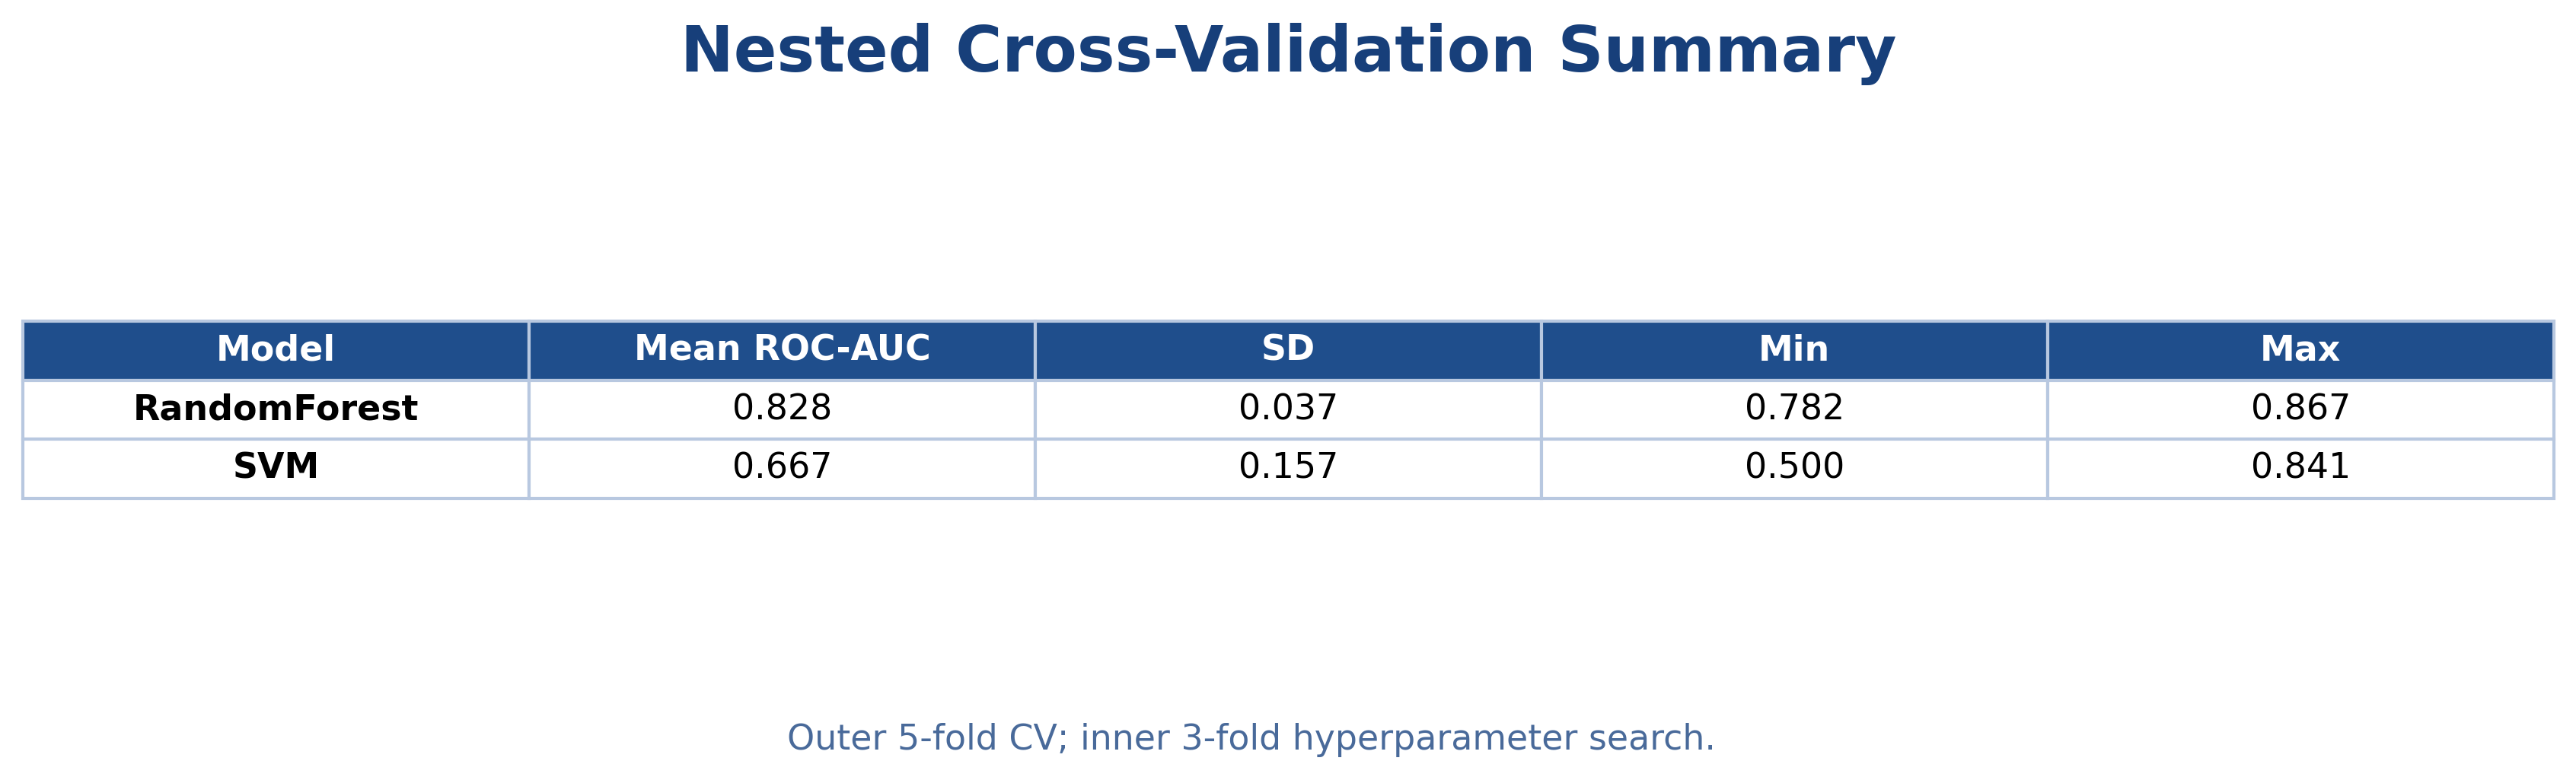

PosixPath('/content/outputs/feature_selection/q1_validation_extension/figures/12_nested_cv_summary.png')

In [31]:
# ============================================================
# Nested CV
# ============================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_records = []

svm_param_dist = {
    "model__C": loguniform(1e-3, 100),
    "model__gamma": loguniform(1e-4, 10),
}
rf_param_dist = {
    "n_estimators": randint(200, 700),
    "max_depth": randint(3, 25),
    "min_samples_leaf": randint(1, 8),
    "min_samples_split": randint(2, 12),
    "max_features": ["sqrt", "log2", None],
}

for model_name, base_estimator, params in [
    ("SVM", Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]), svm_param_dist),
    ("RandomForest", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1), rf_param_dist),
]:
    outer_scores = []
    for fold_idx, (train_idx, valid_idx) in enumerate(outer_cv.split(X_model_full[final_features], y_model_full), start=1):
        Xtr, Xva = X_model_full[final_features].iloc[train_idx], X_model_full[final_features].iloc[valid_idx]
        ytr, yva = y_model_full.iloc[train_idx], y_model_full.iloc[valid_idx]
        search = RandomizedSearchCV(
            base_estimator,
            params,
            n_iter=20,
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1,
            random_state=RANDOM_STATE + fold_idx,
        )
        search.fit(Xtr, ytr)
        score = roc_auc_score(yva, predict_score(search.best_estimator_, Xva))
        outer_scores.append(score)
        nested_records.append({"model": model_name, "fold": fold_idx, "roc_auc": score})

nested_cv_df = pd.DataFrame(nested_records)
nested_summary = nested_cv_df.groupby("model")["roc_auc"].agg(["mean", "std", "min", "max"]).reset_index()
nested_cv_df.to_csv(VALIDATION_TABLE_DIR / "nested_cv_fold_results.csv", index=False)
nested_summary.to_csv(VALIDATION_TABLE_DIR / "nested_cv_summary.csv", index=False)
display(nested_summary)

save_table_figure(
    nested_summary.rename(columns={"model": "Model", "mean": "Mean ROC-AUC", "std": "SD", "min": "Min", "max": "Max"}),
    "Nested Cross-Validation Summary",
    VALIDATION_FIGURE_DIR / "12_nested_cv_summary.png",
    footer="Outer 5-fold CV; inner 3-fold hyperparameter search.",
)

###9.11 Y-randomization test

Y-randomization tests whether the model performance could arise from chance correlations. The true-label model should outperform models trained on randomly permuted labels.

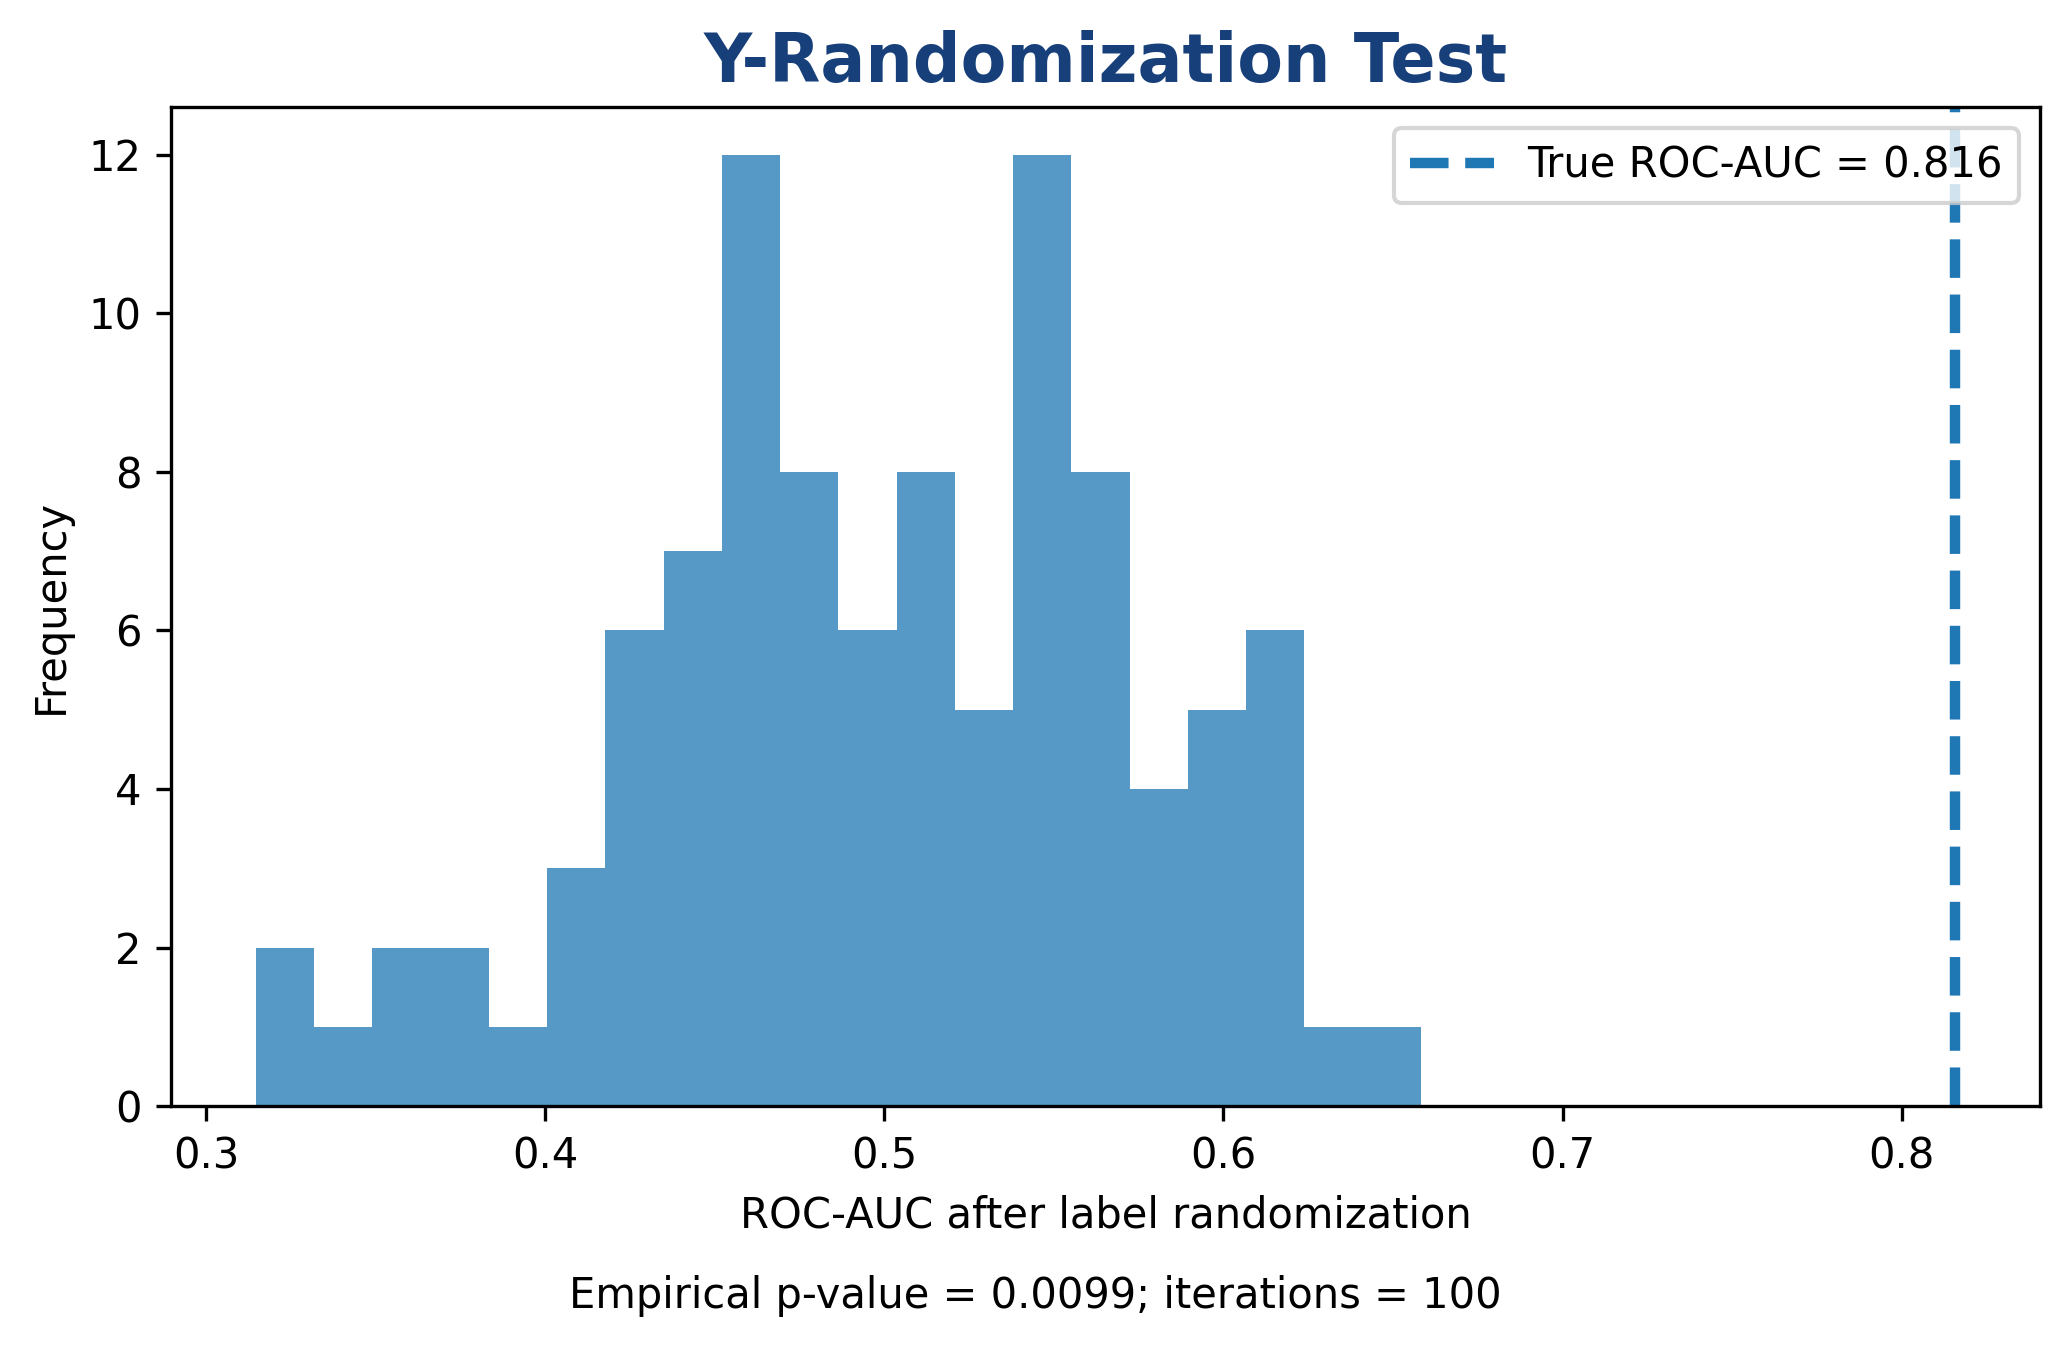

True ROC-AUC: 0.816
Randomized mean ROC-AUC: 0.502 ± 0.072
Empirical p-value: 0.0099


In [32]:
# ============================================================
# Y-randomization test
# ============================================================

N_Y_RANDOM = 100
rng = np.random.default_rng(RANDOM_STATE)
true_auc = roc_auc_score(y_test, predict_score(final_model, X_test[final_features]))
random_aucs = []

for i in range(N_Y_RANDOM):
    y_perm = pd.Series(rng.permutation(y_train.values), index=y_train.index)
    perm_model = clone(final_model)
    perm_model.fit(X_train[final_features], y_perm)
    random_aucs.append(roc_auc_score(y_test, predict_score(perm_model, X_test[final_features])))

y_random_df = pd.DataFrame({"iteration": range(1, N_Y_RANDOM + 1), "randomized_roc_auc": random_aucs})
y_random_df.to_csv(VALIDATION_TABLE_DIR / "y_randomization_results.csv", index=False)

p_empirical = (np.sum(np.array(random_aucs) >= true_auc) + 1) / (N_Y_RANDOM + 1)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
ax.hist(random_aucs, bins=20, alpha=0.75)
ax.axvline(true_auc, linewidth=2.5, linestyle="--", label=f"True ROC-AUC = {true_auc:.3f}")
ax.set_xlabel("ROC-AUC after label randomization")
ax.set_ylabel("Frequency")
ax.set_title("Y-Randomization Test", fontsize=16, fontweight="bold", color="#173f7a")
ax.legend()
fig.text(0.5, 0.02, f"Empirical p-value = {p_empirical:.4f}; iterations = {N_Y_RANDOM}", ha="center", fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(VALIDATION_FIGURE_DIR / "13_y_randomization_test.png", bbox_inches="tight")
plt.show()

print(f"True ROC-AUC: {true_auc:.3f}")
print(f"Randomized mean ROC-AUC: {np.mean(random_aucs):.3f} ± {np.std(random_aucs):.3f}")
print(f"Empirical p-value: {p_empirical:.4f}")

###9.12 Applicability domain using leverage approach

The leverage-based applicability domain identifies compounds that may lie outside the chemical space represented by the training set. This is reported using the warning leverage threshold h* = 3(p + 1) / n, where p is the number of descriptors and n is the number of training compounds.

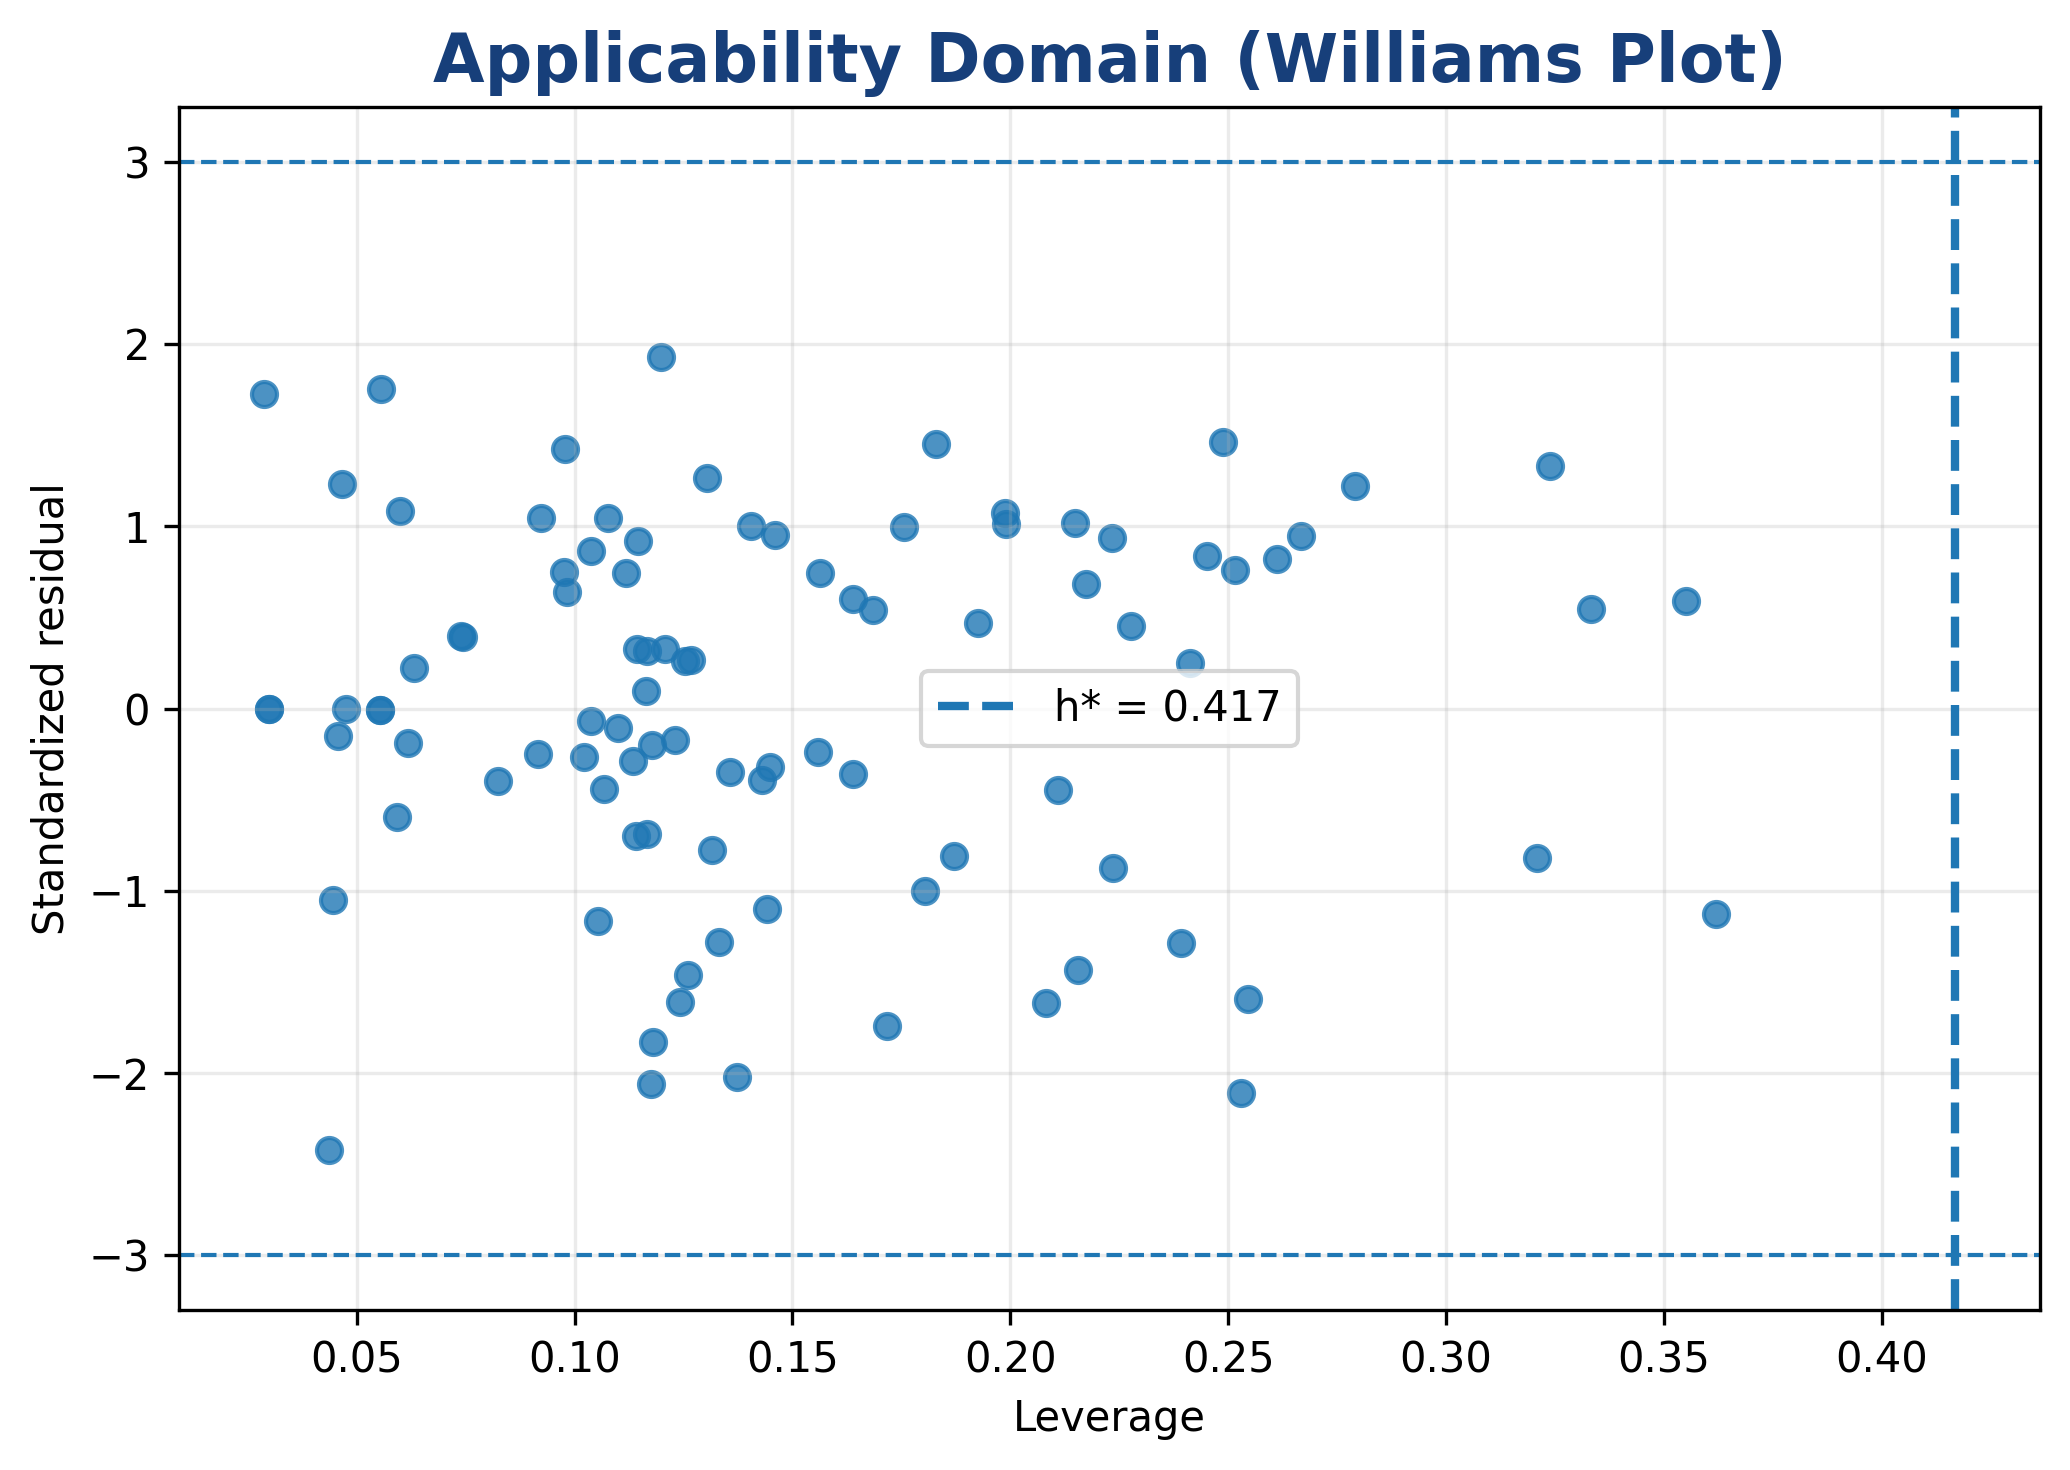

Warning leverage h*: 0.4168564920273349
Compounds inside domain: 94 / 94


In [34]:
# ============================================================
# Applicability Domain: leverage approach
# ============================================================

# To keep the leverage matrix numerically stable, use the final selected features.
Xtr_ad = X_train[final_features].copy().astype(float)
Xte_ad = X_test[final_features].copy().astype(float)

# Standardize before leverage calculation.
scaler_ad = StandardScaler()
Xtr_scaled = scaler_ad.fit_transform(Xtr_ad)
Xte_scaled = scaler_ad.transform(Xte_ad)

# Add intercept column.
Xtr_design = np.column_stack([np.ones(Xtr_scaled.shape[0]), Xtr_scaled])
Xte_design = np.column_stack([np.ones(Xte_scaled.shape[0]), Xte_scaled])

# Pseudo-inverse improves stability for correlated fingerprint bits.
H_inv = np.linalg.pinv(Xtr_design.T @ Xtr_design)
train_leverage = np.sum((Xtr_design @ H_inv) * Xtr_design, axis=1)
test_leverage = np.sum((Xte_design @ H_inv) * Xte_design, axis=1)

p = Xtr_ad.shape[1]
n = Xtr_ad.shape[0]
h_star = 3 * (p + 1) / n

# Classification residual as predicted probability minus actual label.
test_prob = predict_score(final_model, X_test[final_features])
test_residual = test_prob - y_test.values
std_resid = test_residual / (np.std(test_residual) + 1e-12)

ad_df = pd.DataFrame({
    "sample_index": X_test.index,
    "actual_label": y_test.values,
    "predicted_probability": test_prob,
    "standardized_residual": std_resid,
    "leverage": test_leverage,
    "inside_domain": test_leverage <= h_star,
})
ad_df.to_csv(VALIDATION_TABLE_DIR / "applicability_domain_leverage.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
ax.scatter(ad_df["leverage"], ad_df["standardized_residual"], alpha=0.8)
ax.axvline(h_star, linestyle="--", linewidth=2, label=f"h* = {h_star:.3f}")
ax.axhline(3, linestyle="--", linewidth=1)
ax.axhline(-3, linestyle="--", linewidth=1)
ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized residual")
ax.set_title("Applicability Domain (Williams Plot)", fontsize=16, fontweight="bold", color="#173f7a")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(VALIDATION_FIGURE_DIR / "14_applicability_domain_williams_plot.png", bbox_inches="tight")
plt.show()

print("Warning leverage h*:", h_star)
print("Compounds inside domain:", int(ad_df["inside_domain"].sum()), "/", len(ad_df))

###9.13 External validation and bootstrap confidence intervals

The external-like validation split is used as an additional validation layer. Bootstrap confidence intervals are computed for ROC-AUC, accuracy, and F1-score to quantify uncertainty.

,Algorithm,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,RandomForest,0.789474,0.8,0.765957,0.782609,0.87367


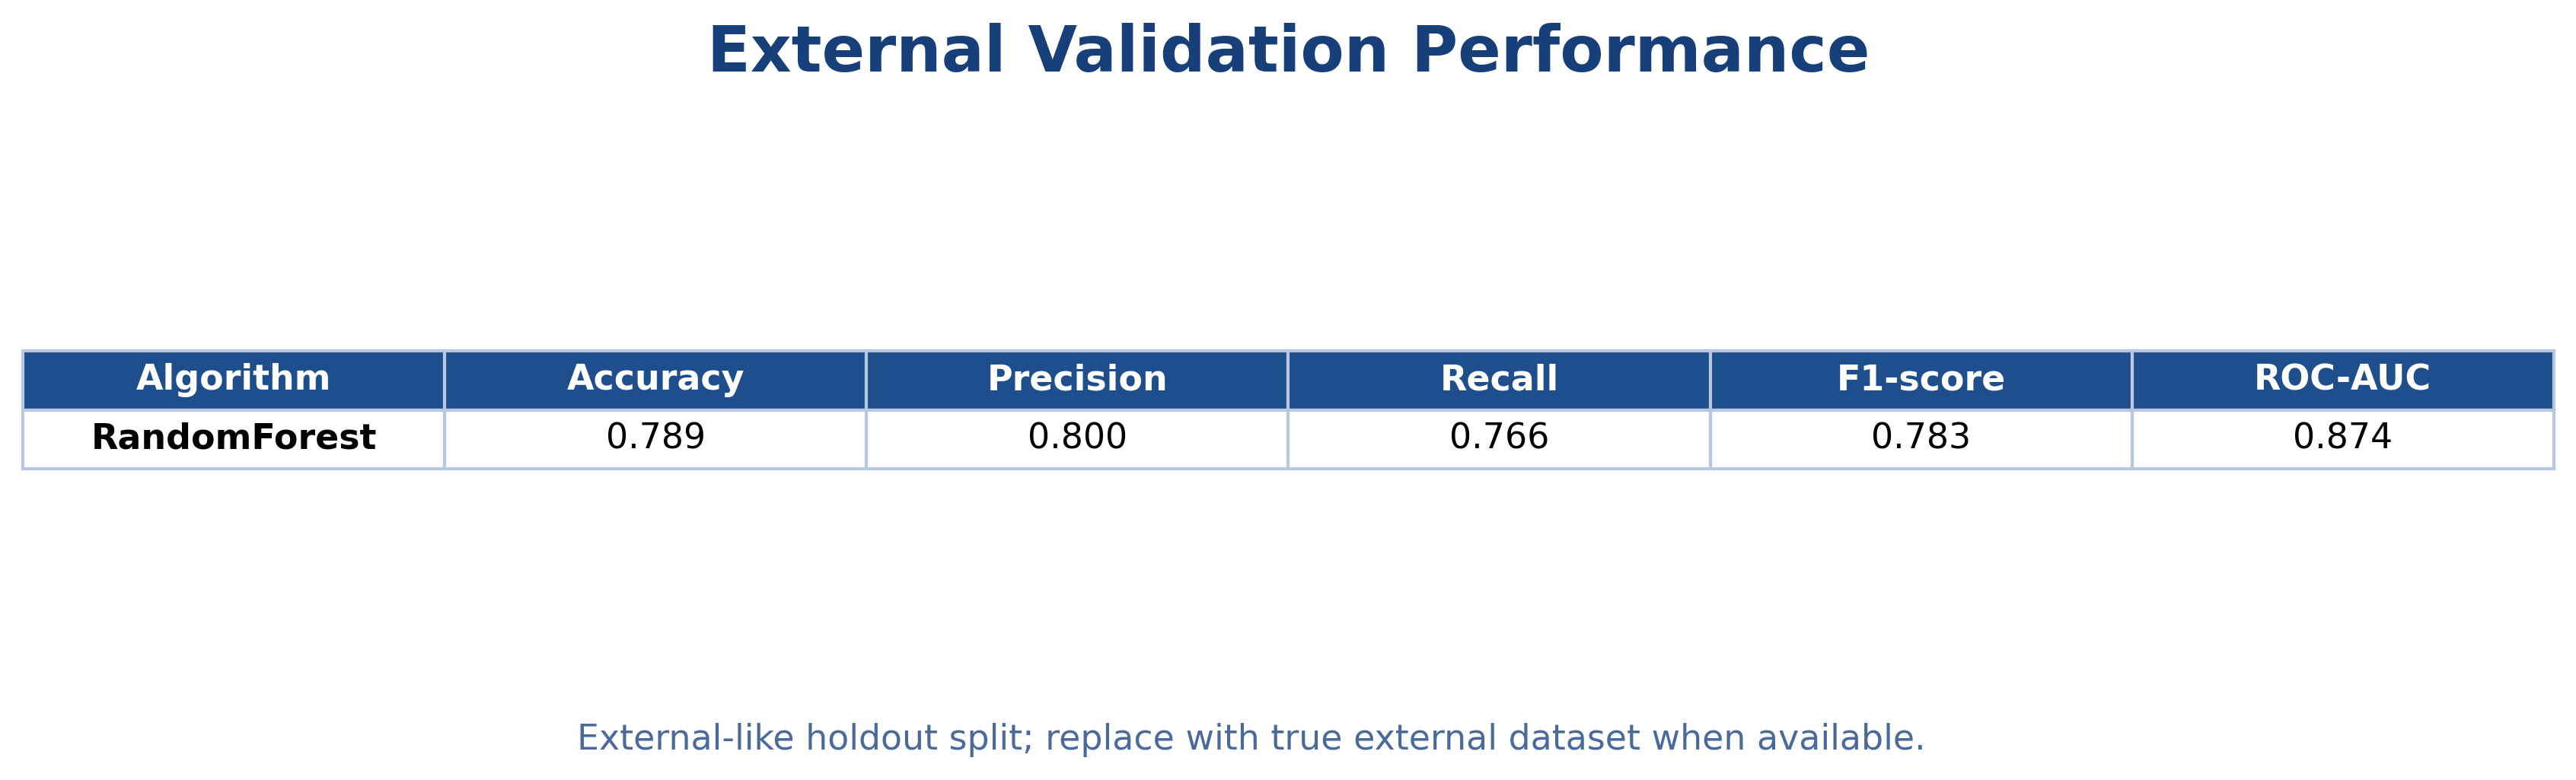

,Metric,CI_2.5%,Median,CI_97.5%
0,Accuracy,0.670213,0.755319,0.840426
1,F1-score,0.632751,0.746061,0.838095
2,ROC-AUC,0.711488,0.815898,0.898113


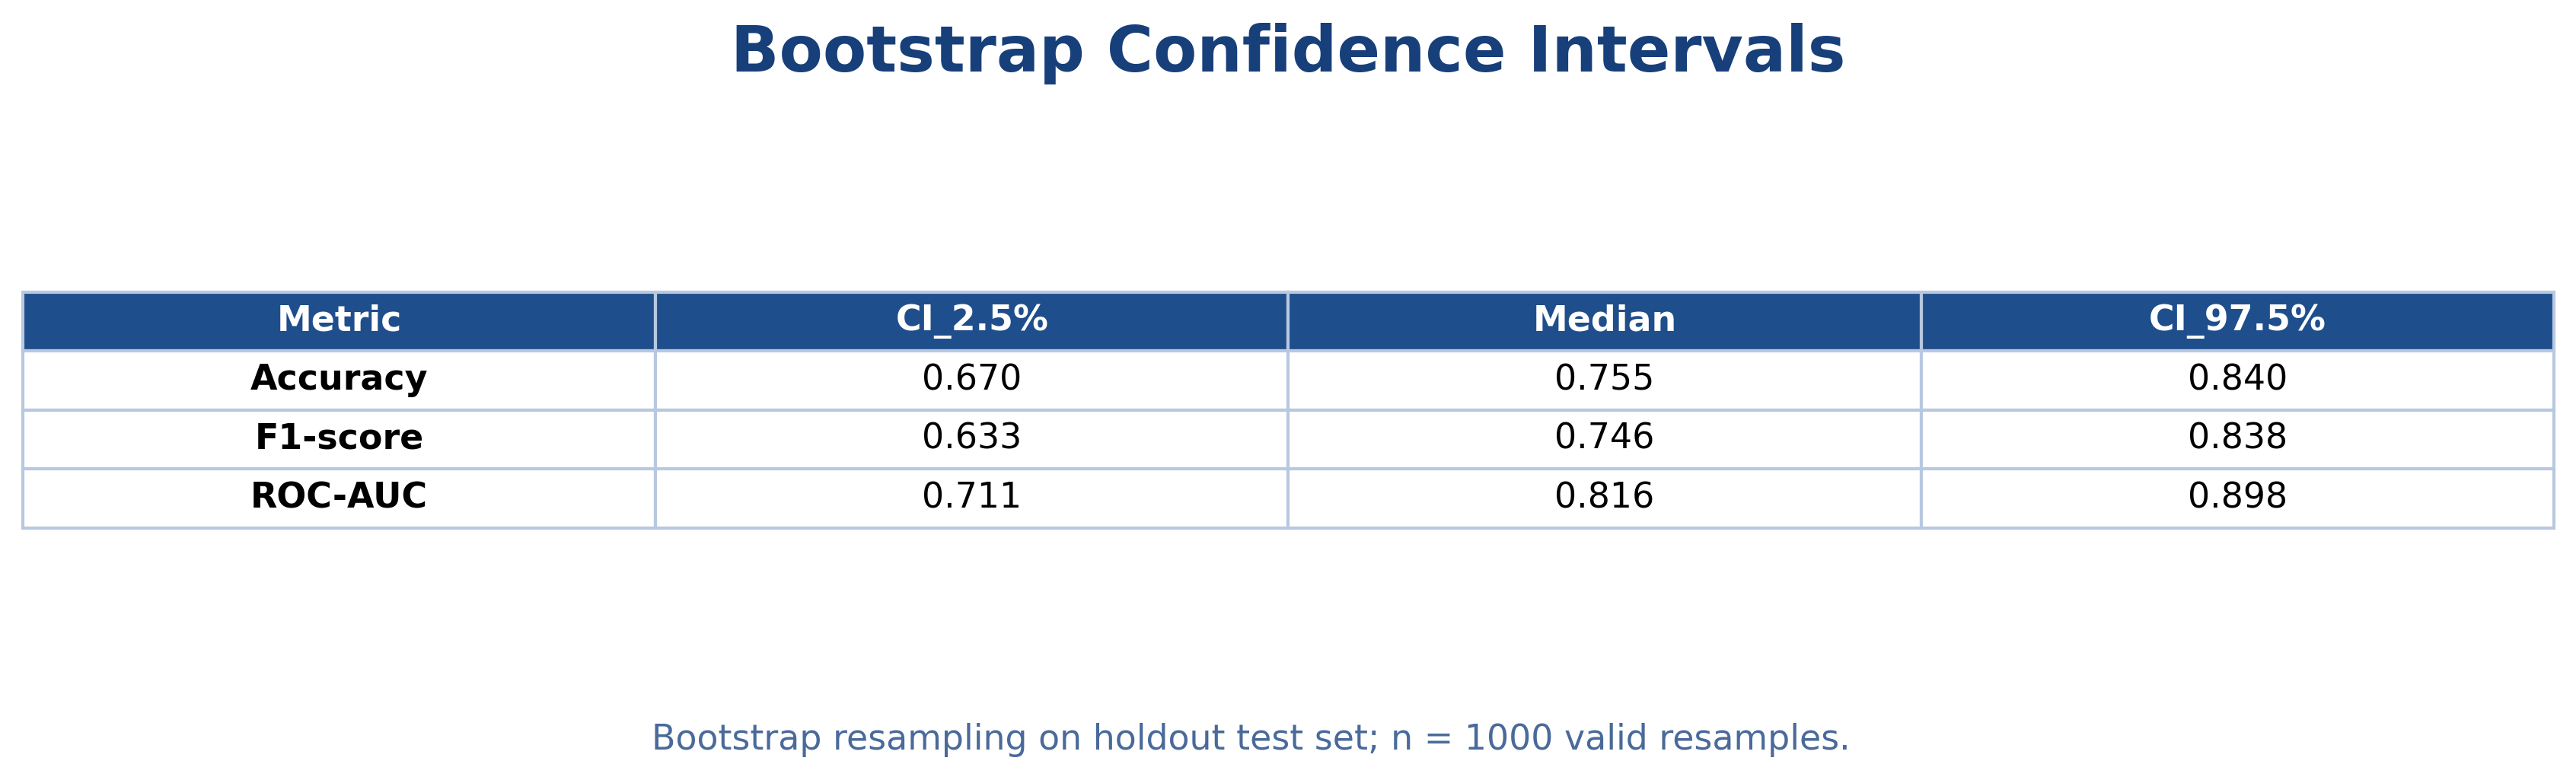

PosixPath('/content/outputs/feature_selection/q1_validation_extension/figures/16_bootstrap_confidence_intervals.png')

In [36]:
# ============================================================
# External validation + Bootstrap CI
# ============================================================

external_metrics = pd.DataFrame([metric_row(final_model_name, final_model, X_external[final_features], y_external)])
external_metrics.to_csv(VALIDATION_TABLE_DIR / "external_validation_results.csv", index=False)
display(external_metrics)

save_table_figure(
    external_metrics,
    "External Validation Performance",
    VALIDATION_FIGURE_DIR / "15_external_validation_results.png",
    footer="External-like holdout split; replace with true external dataset when available.",
)

# Bootstrap CI on test set.
N_BOOTSTRAP = 1000
rng = np.random.default_rng(RANDOM_STATE)
y_true_arr = y_test.values
X_boot = X_test[final_features].reset_index(drop=True)
y_boot = pd.Series(y_true_arr)

boot_records = []
for b in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(y_boot), size=len(y_boot))
    if len(np.unique(y_boot.iloc[idx])) < 2:
        continue
    y_b = y_boot.iloc[idx]
    X_b = X_boot.iloc[idx]
    y_pred_b = final_model.predict(X_b)
    y_score_b = predict_score(final_model, X_b)
    boot_records.append({
        "Accuracy": accuracy_score(y_b, y_pred_b),
        "F1-score": f1_score(y_b, y_pred_b, zero_division=0),
        "ROC-AUC": roc_auc_score(y_b, y_score_b),
    })

bootstrap_df = pd.DataFrame(boot_records)
bootstrap_ci = bootstrap_df.quantile([0.025, 0.5, 0.975]).T.reset_index()
bootstrap_ci.columns = ["Metric", "CI_2.5%", "Median", "CI_97.5%"]
bootstrap_df.to_csv(VALIDATION_TABLE_DIR / "bootstrap_metric_distribution.csv", index=False)
bootstrap_ci.to_csv(VALIDATION_TABLE_DIR / "bootstrap_confidence_intervals.csv", index=False)

display(bootstrap_ci)

save_table_figure(
    bootstrap_ci,
    "Bootstrap Confidence Intervals",
    VALIDATION_FIGURE_DIR / "16_bootstrap_confidence_intervals.png",
    footer=f"Bootstrap resampling on holdout test set; n = {len(bootstrap_df)} valid resamples.",
)

In [37]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from xgboost import XGBClassifier


# SCRIPT_DIR = Path(__file__).resolve().parent
# In a Colab environment, __file__ is not defined. Use Path.cwd() instead.
SCRIPT_DIR = Path.cwd()

INPUT_FILE = SCRIPT_DIR / "outputs" / "feature_selection" / "03_recA_low_variance_filtered.csv"
OUTPUT_DIR = SCRIPT_DIR / "outputs" / "rfe_benchmark"

META_COLUMNS = ["Name", "canonical_smiles", "bioactivity_class", "class"]

TEST_SIZE = 0.2
RANDOM_STATE = 42
N_FEATURES_TO_SELECT = 100
RFE_STEP = 0.2


def load_dataset() -> tuple[pd.DataFrame, pd.Series]:
    if not INPUT_FILE.exists():
        raise FileNotFoundError(
            f"\nInput file not found:\n{INPUT_FILE}\n\n"
            "Please run 03_Feature_selection_low_variance_Fscore.py first."
        )

    df = pd.read_csv(INPUT_FILE)

    missing = [col for col in META_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"Missing metadata columns: {missing}")

    x = (
        df.drop(columns=META_COLUMNS)
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    y = df["class"].astype(int)

    return x, y


def get_selector(method_name: str) -> RFE:
    if method_name == "SVM-RFE":
        estimator = LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            dual="auto",
            max_iter=5000,
        )

    elif method_name == "RF-RFE":
        estimator = RandomForestClassifier(
            n_estimators=150,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )

    elif method_name == "XGBoost-RFE":
        estimator = XGBClassifier(
            n_estimators=150,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.9,
            min_child_weight=3,
            reg_lambda=2,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )

    else:
        raise ValueError(f"Unknown selector method: {method_name}")

    return RFE(
        estimator=estimator,
        n_features_to_select=N_FEATURES_TO_SELECT,
        step=RFE_STEP,
    )


def get_models() -> dict[str, object]:
    return {
        "SVM": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=2,
                        gamma="scale",
                        probability=True,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "RF": RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=4,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.7,
            colsample_bytree=1.0,
            min_child_weight=3,
            reg_lambda=2,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    }


def predict_scores(model, x: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]

    if hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(x), dtype=float)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    raise ValueError("Model does not support probability or decision scoring.")


def metric_row(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def plot_confusion_matrix(
    cm: np.ndarray,
    title: str,
    output_file: Path,
) -> None:
    fig, ax = plt.subplots(figsize=(6.8, 5.5))

    image = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(image, ax=ax)

    row_sums = cm.sum(axis=1, keepdims=True)

    percentages = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n{percentages[i, j] * 100:.2f}%",
                ha="center",
                va="center",
                fontsize=11,
            )

    ax.set(
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=["Inactive", "Active"],
        yticklabels=["Inactive", "Active"],
        ylabel="Actual Label",
        xlabel="Predicted Label",
        title=title,
    )

    plt.tight_layout()
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_roc(
    y_true: pd.Series,
    y_score: np.ndarray,
    title: str,
    output_file: Path,
) -> None:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    fig, ax = plt.subplots(figsize=(6.8, 5.5))

    ax.plot(fpr, tpr, lw=2, label=f"ROC curve, AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], lw=2, linestyle="--")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")

    plt.tight_layout()
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.close(fig)


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    x, y = load_dataset()

    if x.shape[1] < N_FEATURES_TO_SELECT:
        raise ValueError(
            f"Number of available features ({x.shape[1]}) is smaller than "
            f"N_FEATURES_TO_SELECT ({N_FEATURES_TO_SELECT})."
        )

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    train_rows: list[dict] = []
    test_rows: list[dict] = []
    selected_feature_map: dict[str, list[str]] = {}
    best_result: dict | None = None

    for method_name in ["SVM-RFE", "RF-RFE", "XGBoost-RFE"]:
        print(f"\nRunning {method_name}...")

        selector = get_selector(method_name)
        selector.fit(x_train, y_train)

        selected_columns = x_train.columns[selector.support_].tolist()
        selected_feature_map[method_name] = selected_columns

        x_train_sel = x_train[selected_columns].copy()
        x_test_sel = x_test[selected_columns].copy()

        for model_name, model in get_models().items():
            print(f"  Training {model_name}...")

            model.fit(x_train_sel, y_train)

            y_train_pred = model.predict(x_train_sel)
            y_train_score = predict_scores(model, x_train_sel)

            train_metrics = metric_row(
                y_train,
                y_train_pred,
                y_train_score,
            )

            train_rows.append(
                {
                    "feature_selection_method": method_name,
                    "model_algorithm": model_name,
                    **train_metrics,
                }
            )

            y_test_pred = model.predict(x_test_sel)
            y_test_score = predict_scores(model, x_test_sel)

            test_metrics = metric_row(
                y_test,
                y_test_pred,
                y_test_score,
            )

            result_row = {
                "feature_selection_method": method_name,
                "model_algorithm": model_name,
                **test_metrics,
            }

            test_rows.append(result_row)

            if best_result is None or result_row["roc_auc"] > best_result["roc_auc"]:
                best_result = {
                    **result_row,
                    "selected_columns": selected_columns,
                    "y_test_pred": y_test_pred,
                    "y_test_score": y_test_score,
                }

    train_df = pd.DataFrame(train_rows)
    test_df = pd.DataFrame(test_rows)

    train_df.to_csv(
        OUTPUT_DIR / "03a_rfe_train_metrics.csv",
        index=False,
    )

    test_df.to_csv(
        OUTPUT_DIR / "03a_rfe_test_metrics.csv",
        index=False,
    )

    with open(
        OUTPUT_DIR / "03a_selected_features_by_method.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(selected_feature_map, file, indent=2)

    if best_result is not None:
        cm = confusion_matrix(
            y_test,
            best_result["y_test_pred"],
        )

        title_prefix = (
            f"{best_result['model_algorithm']} "
            f"with {best_result['feature_selection_method']}"
        )

        plot_confusion_matrix(
            cm,
            f"Confusion Matrix: {title_prefix}",
            OUTPUT_DIR / "03a_best_rfe_confusion_matrix.png",
        )

        plot_roc(
            y_test,
            best_result["y_test_score"],
            f"ROC Curve: {title_prefix}",
            OUTPUT_DIR / "03a_best_rfe_roc_curve.png",
        )

        best_summary = {
            key: value
            for key, value in best_result.items()
            if key not in {
                "selected_columns",
                "y_test_pred",
                "y_test_score",
            }
        }

        pd.DataFrame([best_summary]).to_csv(
            OUTPUT_DIR / "03a_best_rfe_result.csv",
            index=False,
        )

    print("\nTrain metrics:")
    print(train_df.to_string(index=False))

    print("\nTest metrics:")
    print(test_df.to_string(index=False))

    print(f"\nOutputs saved to:\n{OUTPUT_DIR}")

In [38]:
# Notebook runner for Stage 03a: RFE benchmark
# This may take time depending on number of descriptors and hardware.
main()


Running SVM-RFE...
  Training SVM...
  Training RF...
  Training XGBoost...

Running RF-RFE...
  Training SVM...
  Training RF...
  Training XGBoost...

Running XGBoost-RFE...
  Training SVM...
  Training RF...
  Training XGBoost...

Train metrics:
feature_selection_method model_algorithm  accuracy  precision   recall  f1_score      mcc  roc_auc
                 SVM-RFE             SVM  0.996016   0.996016 0.996016  0.996016 0.992032 0.999937
                 SVM-RFE              RF  0.984064   0.987952 0.980080  0.984000 0.968158 0.994730
                 SVM-RFE         XGBoost  0.998008   1.000000 0.996016  0.998004 0.996024 0.999968
                  RF-RFE             SVM  0.976096   0.979920 0.972112  0.976000 0.952221 0.997333
                  RF-RFE              RF  0.948207   0.966805 0.928287  0.947154 0.897127 0.988699
                  RF-RFE         XGBoost  0.994024   0.992063 0.996016  0.994036 0.988056 0.998984
             XGBoost-RFE             SVM  0.986056   0.98

###9.14 Final note

The extended workflow now contains the requested sections and additional validation controls. For manuscript writing, the recommended result narrative is:

1. Low-variance filtering and F-score ranking reduced the descriptor space before model-dependent selection.

2. SVM-RFE and RF-RFE were compared across multiple feature-subset sizes rather than relying on a single arbitrary feature count.

3. RF and SVM were evaluated as baseline and optimized models.

4. Nested CV, external validation, y-randomization, applicability-domain analysis, and bootstrap confidence intervals were added to reduce overfitting/data-leakage concerns and strengthen model reliability.

5. The final selected model should be reported with both holdout metrics and robustness metrics rather than training performance only.